# Histórico de suertes: EDA y preprocesamiento

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/01_eda_suertes.ipynb)

Este notebook cubre el inventario, la calidad de datos, el EDA y la selección de predictores sobre `HISTORICO_SUERTES.xlsx`: el histórico de cortes del Ingenio Providencia y dos indicadores de cada lote (suerte):

- **TCH:** toneladas de caña por hectárea (productividad).
- **%Sac.Caña:** porcentaje de sacarosa (calidad).

Cada fila es **un lote de caña (suerte) cosechado en un mes concreto (periodo)**. El flujo es inventario y calidad de datos, EDA y selección de predictores (pasos 1–14). Los modelos de regresión (pasos 15–23: hold-out, lineal, validación cruzada y Random Forest) están en `02_modelos_regresion.ipynb`, que parte de `datos/suertes_limpio.parquet`, el archivo que este notebook guarda al final.

En Colab hay que subir `HISTORICO_SUERTES.xlsx` al directorio de trabajo (el Excel no está en el repositorio).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline


In [2]:
# Lectura del histórico de suertes
df_suertes = pd.read_excel("HISTORICO_SUERTES.xlsx", sheet_name="Hoja1")
print("HISTORICO_SUERTES:", df_suertes.shape)


HISTORICO_SUERTES: (21027, 85)


## 1. Inventario

Primera mirada a la estructura: dimensiones, columnas, tipos y cruce con el diccionario `BD_cana.pdf`. En este paso no se descarta ninguna variable.


In [3]:
# Inventario: estructura del histórico de suertes
print("Dimensiones:", df_suertes.shape)
print("Filas:", df_suertes.shape[0], "| Columnas:", df_suertes.shape[1])
print("Memoria (MB):", round(df_suertes.memory_usage(deep=True).sum() / 1e6, 2))

print("\nResumen de tipos:")
print(df_suertes.dtypes.astype(str).value_counts().to_string())

print("\nColumnas y tipo:")
inventario = pd.DataFrame({
    "columna": df_suertes.columns,
    "dtype": df_suertes.dtypes.astype(str).values,
    "n_nulos": df_suertes.isna().sum().values,
    "n_no_nulos": df_suertes.notna().sum().values,
    "n_unicos": [df_suertes[c].nunique(dropna=True) for c in df_suertes.columns],
})
display(inventario)

display(df_suertes.head(3))

# Columnas que sí nombra BD_cana.pdf (el documento se corta en TAH / TAHM)
cols_pdf = [
    "Período", "Hacienda", "Nombre", "Zona", "Tenencia", "Suerte", "Suelo",
    "Area Neta", "Dist Km", "Variedad", "Cod.Estado #", "Cod.Estado",
    "F.Siembra", "Ult.Riego", "Edad Ult Cos", "F.Ult.Corte", "Destino 1=Semilla",
    "Cod. T.Cultivo", "Cultivo", "Fec.Madur.", "Producto", "Dosis Madurante",
    "Semanas mad.", "TonUltCorte", "TCH", "TCHM", "Ton.Azucar", "Rdto", "TAH", "TAHM",
]

cols_en_datos = set(df_suertes.columns)
cols_en_pdf = set(cols_pdf)

print("Documentadas en BD_cana.pdf y presentes en el Excel:", len(cols_en_pdf & cols_en_datos))
print("Nombradas en el PDF pero ausentes en el Excel:", sorted(cols_en_pdf - cols_en_datos))
print(f"\nColumnas en el Excel no cubiertas por el PDF ({len(cols_en_datos - cols_en_pdf)}):")
print(sorted(cols_en_datos - cols_en_pdf))


Dimensiones: (21027, 85)
Filas: 21027 | Columnas: 85
Memoria (MB): 29.88

Resumen de tipos:
float64           62
object            14
int64              5
datetime64[ns]     4

Columnas y tipo:


,columna,dtype,n_nulos,n_no_nulos,n_unicos
0,Período,int64,0,21027,91
1,Hacienda,int64,0,21027,926
2,Nombre,object,0,21027,914
3,Zona,object,0,21027,7
4,Tenencia,float64,1,21026,7
5,Suerte,object,0,21027,1220
6,Suelo,object,3758,17269,102
7,Area Neta,float64,0,21027,2397
8,Dist Km,float64,5,21022,339
9,Variedad,object,0,21027,58


,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,Cod.Estado #,Cod.Estado,F.Siembra,D.S.,Ult.Riego,Edad Ult Cos,F.Ult.Corte,Destino 1=Semilla,Cod. T.Cultivo,Cultivo,Fec.Madur.,Producto,Dosis Madurante,Semanas mad.,TonUltCorte,TCH,TCHM,Ton.Azucar,Rdto,TAH,TAHM,Sac.Caña Precosecha,Edad.Precosecha,%Sac.Caña,%Sac.Muestreadora,%ATR,KATRHM,%Fibra Caña,%AR Jugo,%ME Min,%ME Veg,%ME Tot,Brix,Pureza,Vejez,Tipo Quema,T.Corte,Cerca de,Cosechó,Num.Riegos,M3 Riego,DDUlt.Riego,Lluvias (2 Meses Ant.),Lluvias Ciclo,Lluvias 0 -3,Lluvias tres a seis,Lluvias seis a nueve,Luvias 9 -FC,%Infest.Diatrea,Fosfato Jugo,Fert.Nitrogen.,Urea 46%,MEZ,Boro Granul.,MicroZinc,NITO_XTEND,Sul.Amonio,NITRAX-S,Vinaza,Codigo Estacion,Temp. Media 0-3,Temp. Media Ciclo,Temp Max Ciclo,Temp Min Ciclo,Humedad Rel Media 0-3,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,5,Corte 5,2010-08-20,NaN,NaT,12.81,2017-01-02,0,1.0,Normal,2016-11-04,BONUS 250 EC REGULADOR FISIOLÓGICO,1.0,8.428571,727.19,121.198333,9.461228,86.050,11.8332,14.341666,1.119567,16.8172,NaN,13.7582,13.508,15.1653,1434.823641,16.910,0.84,0.355,10.198,10.553,15.7464,87.2241,2.735,VERDE,MECANIZADO,El Cerrito,AI08,NaN,0.0,0,258.0,1038.0,0.0,454.0,102.0,482.0,NaN,178.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,5,Corte 5,2011-01-27,NaN,NaT,11.14,2017-01-02,0,1.0,Normal,NaT,NaN,0.0,NaN,136.00,93.793103,8.419488,14.728,10.8294,10.157241,0.911781,NaN,NaN,12.8430,12.551,14.0410,1182.180399,16.936,0.55,2.298,7.273,9.571,15.2240,84.3602,73.823,Q.ACCIDENTAL,MANUAL,Candelaria,AI08,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,382.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,4,Corte 4,2011-10-25,1.65,2016-09-17,12.32,2017-01-02,0,1.0,Normal,2016-11-04,BONUS 250 EC REGULADOR FISIOLÓGICO,1.1,8.428571,1436.62,174.347087,14.151549,145.268,10.1117,17.629611,1.430974,14.7749,12.02,11.9364,11.940,13.1236,1857.192723,15.512,0.61,3.000,9.323,12.323,14.1130,84.4527,2.108,VERDE,MECANIZADO,Palmira,AI08,5.0,48513.6,107,246.0,1002.0,106.0,326.0,113.0,457.0,NaN,226.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Documentadas en BD_cana.pdf y presentes en el Excel: 30
Nombradas en el PDF pero ausentes en el Excel: []

Columnas en el Excel no cubiertas por el PDF (55):
['%AR Jugo', '%ATR', '%Fibra Caña', '%Infest.Diatrea', '%ME Min', '%ME Tot', '%ME Veg', '%Sac.Caña', '%Sac.Muestreadora', 'Boro Granul.', 'Brix', 'Cerca de', 'Codigo Estacion', 'Cosechó', 'D.S.', 'DDUlt.Riego', 'Edad.Precosecha', 'Evaporacion 0-3', 'Evaporacion Ciclo', 'Fert.Nitrogen.', 'Fosfato Jugo', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'KATRHM', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias Ciclo', 'Lluvias seis a nueve', 'Lluvias tres a seis', 'Luvias 9 -FC', 'M3 Riego', 'MEZ', 'MicroZinc', 'NITO_XTEND', 'NITRAX-S', 'Num.Riegos', 'Oscilacion Temp Ciclo', 'Oscilacion Temp Med 0-3', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Pureza', 'Radiacion Solar Ciclo', 'Radicion Solar 0-3', 'Sac.Caña Precosecha', 'Sul.Amonio', 'Sum Oscilacion Temp Ciclo', 'T.Corte', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Temp. Media 0-

**Qué muestra este inventario**

- El archivo tiene **21.027 filas y 85 columnas**. Cada fila parece un corte de una suerte (lote) en un periodo; eso se confirma en el siguiente paso con la llave `Hacienda + Suerte + Período`.
- Los tipos están mezclados de forma coherente con un histórico agrícola: mayoría **numérica** (`float64` / `int64`), varias **categóricas** (`str`) y **4 fechas** (`F.Siembra`, `Ult.Riego`, `F.Ult.Corte`, `Fec.Madur.`).
- Los dos indicadores a modelar son **`TCH`** (productividad) y **`%Sac.Caña`** (calidad). `TCH` está en `BD_cana.pdf`; **`%Sac.Caña` no**, porque el documento se corta en `TAH` / `TAHM`. El Excel trae más variables de calidad, clima, riego y fertilización de las que el PDF describe.
- Hay **~55 columnas sin ficha en el PDF** (lluvias, laboratorio, insumos, estación meteorológica). No se descartan por ausencia de diccionario: primero se inspeccionan en los datos.
- Nombres con detalle de captura: espacio al final en `Humedad Rel Media 0-3 `, y un posible typo en `Luvias 9 -FC` / `Radicion Solar 0-3`. Conviene no renombrar todavía, para no romper el cruce con el diccionario.

**Qué no se decide aquí.** No se elimina ninguna columna. El siguiente paso es revisar tipos, nulos de los dos targets y si `(Hacienda, Suerte, Período)` identifica bien cada registro.


## 2. Tipos, targets y llave

Se confirma si cada fila es un lote cosechado en un mes, cómo están guardados los identificadores y si `TCH` y `%Sac.Caña` están completos. Todavía no se descartan predictores.


In [4]:
# Suerte es identificador de lote (002A, 007); se fuerza a texto para no perder ceros a la izquierda
df_suertes["Suerte"] = df_suertes["Suerte"].astype("string")

llave = ["Hacienda", "Suerte", "Período"]
n_filas = len(df_suertes)
n_llave = df_suertes.duplicated(llave).sum()
n_lotes = df_suertes[["Hacienda", "Suerte"]].drop_duplicates().shape[0]
cortes_por_lote = df_suertes.groupby(["Hacienda", "Suerte"]).size()

print("Tipo de Suerte:", df_suertes["Suerte"].dtype)
print("Ejemplos:", df_suertes["Suerte"].head(8).tolist())
print("Valores de Suerte que empiezan en 0:", int(df_suertes["Suerte"].str.match(r"^0").sum()))

print("\nLlave Hacienda + Suerte + Período")
print("Filas:", n_filas)
print("Duplicados de la llave:", n_llave)
print("Combinaciones distintas:", df_suertes[llave].drop_duplicates().shape[0])
print("Lotes distintos (Hacienda + Suerte):", n_lotes)
print(cortes_por_lote.describe().to_string())
print("Lotes con un solo corte:", int((cortes_por_lote == 1).sum()))
print("Lotes con más de un corte:", int((cortes_por_lote > 1).sum()))

print("\nPeríodo (parece AAAAMM)")
print("Mínimo:", df_suertes["Período"].min(), "| Máximo:", df_suertes["Período"].max())
print("Meses distintos:", df_suertes["Período"].nunique())

print("\nTargets")
for col in ["TCH", "%Sac.Caña"]:
    n_na = int(df_suertes[col].isna().sum())
    pct = 100 * n_na / n_filas
    print(f"{col}: dtype={df_suertes[col].dtype} | nulos={n_na} ({pct:.2f}%)")

display(df_suertes[["TCH", "%Sac.Caña"]].describe().T)

Tipo de Suerte: string
Ejemplos: ['002A', '039B', '007', '013A', '025A', '003A', '002A', '003B']
Valores de Suerte que empiezan en 0: 17689

Llave Hacienda + Suerte + Período
Filas: 21027
Duplicados de la llave: 0
Combinaciones distintas: 21027
Lotes distintos (Hacienda + Suerte): 5799
count    5799.000000
mean        3.625970
std         2.400045
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max         9.000000
Lotes con un solo corte: 1806
Lotes con más de un corte: 3993

Período (parece AAAAMM)
Mínimo: 201701 | Máximo: 202407
Meses distintos: 91

Targets
TCH: dtype=float64 | nulos=0 (0.00%)
%Sac.Caña: dtype=float64 | nulos=449 (2.14%)


,count,mean,std,min,25%,50%,75%,max
TCH,21027.0,129.608509,32.846029,1.573653,108.691426,129.47960,150.407607,401.045947
%Sac.Caña,20578.0,12.320202,1.145738,7.086000,11.619000,12.37065,13.087500,18.400000


In [5]:
# ¿El faltante se concentra en algún período?
display(df_suertes.groupby(df_suertes["%Sac.Caña"].isna())["Período"].describe())

# ¿Se concentra en lotes destinados a semilla?
display(pd.crosstab(df_suertes["%Sac.Caña"].isna(), df_suertes["Destino 1=Semilla"], normalize="index"))

# ¿Se concentra en alguna zona? (usar una copia temporal en mayúsculas, sin tocar df_suertes todavía —
# la recodificación oficial de Zona ocurre más adelante en el paso 5)
zona_temp = df_suertes["Zona"].str.upper()
display(pd.crosstab(df_suertes["%Sac.Caña"].isna(), zona_temp, normalize="index"))

# ¿El patrón por zona es independiente del destino, o solo refleja dónde se siembra más semilla?
# (controlar por destino: mirar el faltante SOLO dentro de los lotes de molino)
solo_molino = df_suertes[df_suertes["Destino 1=Semilla"] == 0]
zona_molino_temp = solo_molino["Zona"].str.upper()
display(pd.crosstab(zona_molino_temp, solo_molino["%Sac.Caña"].isna(), normalize="index"))


,count,mean,std,min,25%,50%,75%,max
%Sac.Caña,,,,,,,,
False,20578.0,202037.465594,216.087850,201701.0,201812.0,202010.0,202209.0,202406.0
True,449.0,202142.512249,217.364963,201701.0,202001.0,202202.0,202307.0,202407.0


Destino 1=Semilla,0,1
%Sac.Caña,,
False,0.999951,0.000049
True,0.347439,0.652561


Zona,IC07,IP01,IP02,IP03,IP05,IP06
%Sac.Caña,,,,,,
False,0.000049,0.107591,0.076003,0.249004,0.373992,0.193362
True,0.000000,0.207127,0.069042,0.133630,0.291759,0.298441


%Sac.Caña,False,True
Zona,,
IC07,1.000000,0.000000
IP01,0.987071,0.012929
IP02,0.992386,0.007614
IP03,0.991486,0.008514
IP05,0.992263,0.007737
IP06,0.997243,0.002757


**Por qué falta `%Sac.Caña` en 449 filas (2.14%)**

El hueco **no es aleatorio en el tiempo**. Con dato (`False` en la tabla), n = 20.578 y la mediana de `Período` es **202010.0** (octubre 2020). Sin dato (`True`), n = 449 y la mediana es **202202.0** (febrero 2022): unos **16 meses** más tarde. El máximo del faltante es 202407.0; el de las filas con sacarosa, 202406.0.

La causa principal es el **destino semilla**. Entre las filas sin `%Sac.Caña`, `Destino 1=Semilla = 1` es **0.652561 (65.3%)** y el molino **0.347439 (34.7%)**. Entre las que sí tienen sacarosa, el destino semilla es **0.000049**. Los lotes de semilla no se muelen: no pasan por el laboratorio que mide sacarosa. Eso explica la mayoría del faltante.

El diccionario (`BD_cana.pdf`) solo confirma el valor **1** de `Destino 1=Semilla`: el propio nombre de la columna lo indica (`1=Semilla`). Del resto dice “semilla u otro uso”, sin nombrar qué es ese otro uso. Que **0 = molino** (el corte va a fábrica a producir azúcar) es una inferencia de negocio, no un dato del diccionario: en este contexto un corte de caña tiene dos rutas, ir a molienda o servir de material de siembra para otro lote. El crosstab de esta celda respalda esa lectura: en el grupo `Destino = 0`, `%Sac.Caña` está medida en **99.9951 %** de los casos (0.999951), coherente con que sí pasa por molienda y laboratorio; si 0 no fuera “va al molino”, no habría esa correspondencia casi perfecta. A partir de aquí el notebook usa `.map({0: "molino", 1: "semilla"})` en el univariado y los boxplots bajo esta misma inferencia; se documenta en esta celda para no repetirla sin evidencia cada vez que aparece.

El patrón aparente por zona (sin dato: IP01 **0.207** e IP06 **0.298**, frente a **0.108** y **0.193** con dato) es **en su mayor parte siembra de semilla**, no un fallo independiente de captura. Controlando solo molino, el faltante por zona queda bajo: IP02 **0.0076**, IP03 **0.0085**, IP05 **0.0077**, IP06 **0.0028**. **IP01** queda un poco más alto (**0.0129**, ~1.3%). Puede ser un rezago residual de laboratorio; la proporción es chica y no alcanza para afirmarlo con certeza.

**Por eso no se imputa el target.** En semilla el dato no está “perdido”: la medición **nunca se generó**, porque el lote no se procesó como azúcar. Inventar `%Sac.Caña` ahí mezclaría un proceso (semillero) con otro (molino). El modelo de sacarosa usa las 20.578 filas con medición; el de TCH, las 21.027 filas sin nulos (el paso 9 excluye del modelo de TCH los 355 lotes con TCH < 60 de destino molino).


**Qué muestra este paso**

- `(Hacienda, Suerte, Período)` no se repite: **21.027 filas = 21.027 cosechas**. La unidad de análisis queda fijada: un lote (`Suerte` dentro de una `Hacienda`) cortado en un mes (`Período`, formato AAAAMM, de 201701 a 202407).
- El mismo lote sí vuelve a aparecer en otros meses: hay **5.799 lotes** y, en promedio, **3.6 cortes** por lote (hasta 9). Son cosechas distintas, no filas duplicadas.
- `Suerte` ya venía como texto (`002A`, `007`). Se deja explícitamente como `string` porque 17.689 códigos empiezan por 0: tratarlos como número convertiría `007` en `7`.
- **`TCH` está completo** (0 nulos). Media ≈ 130 t/ha; el máximo 401 se revisa después en el univariado, no se borra aquí.
- **`%Sac.Caña` tiene 449 nulos (2.14%)**. No se imputa: la mayoría son lotes de semilla que no pasan por el laboratorio (celda anterior). El modelo de sacarosa usa las 20.578 filas con dato; el de TCH, las 21.027 filas sin nulos (el paso 9 excluye del modelo de TCH los 355 lotes con TCH < 60 de destino molino).

**Qué no se decide aquí.** No se elimina ningún predictor. El siguiente paso es la completitud del resto de columnas: qué tan vacías están y cuáles se pueden descartar solo por falta de dato.


## 3. Completitud

Primera tijera **solo por nulos**: qué tan vacía está cada columna y cuáles fallan juntas. Imputar una columna con ≥70 % de huecos introduce más ruido que señal; esas casi vacías salen. El resto sigue, sin imputar todavía.


Antes de aplicar el umbral de nulos se buscan **faltantes disfrazados** en columnas de texto: `isna()` no ve un string vacío, un espacio ni etiquetas tipo `NA`, `N/A`, `None`, `null`, `?`, `-`, `S/D` o `SIN DATO`. Si aparecen, se pasan a `NaN` de verdad para que el % de nulos y el corte del 70% cuenten el hueco real, no una celda “llena” de texto vacío.


In [6]:
# Placeholders que isna() no ve (tras strip, para no fallar por espacios).
placeholders = ["", " ", "NA", "N/A", "None", "none", "null", "NULL", "?", "-", "S/D", "SIN DATO"]
placeholders_norm = {p.strip().upper() for p in placeholders}

cols_texto = [
    c for c in df_suertes.columns
    if pd.api.types.is_object_dtype(df_suertes[c]) or pd.api.types.is_string_dtype(df_suertes[c])
]

resumen_ph = []
for col in cols_texto:
    s = df_suertes[col]
    as_str = s.astype("string").str.strip()
    mask = as_str.str.upper().isin(placeholders_norm)
    mask = mask.fillna(False)
    n = int(mask.sum())
    if n == 0:
        continue
    crudos = s.loc[mask].unique().tolist()
    df_suertes[col] = df_suertes[col].replace(crudos, np.nan)
    resumen_ph.append({"columna": col, "n_filas": n, "valores": crudos})

if resumen_ph:
    display(pd.DataFrame(resumen_ph).sort_values("n_filas", ascending=False))
    print(f"Placeholders convertidos a NaN en {len(resumen_ph)} columna(s).")
else:
    print("no se encontraron nulos disfrazados")


no se encontraron nulos disfrazados

Columnas con algún nulo: 58 de 85
Columnas completas: 27


,pct_nulos,n_nulos
Fert.Nitrogen.,100.000000,21027
Sum Oscilacion Temp Ciclo,100.000000,21027
Urea 46%,96.561564,20304
NITRAX-S,96.442669,20279
MEZ,95.382128,20056
MicroZinc,94.535597,19878
Boro Granul.,93.888810,19742
Sul.Amonio,93.546393,19670
NITO_XTEND,82.503448,17348
Vinaza,80.510772,16929



Columnas que fallan juntas (mismo % de nulos):
  0.01% (2): ['Cultivo', 'Cod. T.Cultivo']
  1.15% (3): ['TAHM', 'Ton.Azucar', 'TAH']
  1.27% (2): ['Brix', 'Rdto']
  2.48% (2): ['%ATR', 'KATRHM']
  8.18% (2): ['%ME Veg', '%ME Tot']
  8.84% (3): ['%Sac.Muestreadora', '%Fibra Caña', 'Fosfato Jugo']
  46.49% (2): ['Semanas mad.', 'Fec.Madur.']
  78.46% (14): ['Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Evaporacion Ciclo', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Humedad Rel Media 0-3 ']
  100.00% (2): ['Fert.Nitrogen.', 'Sum Oscilacion Temp Ciclo']


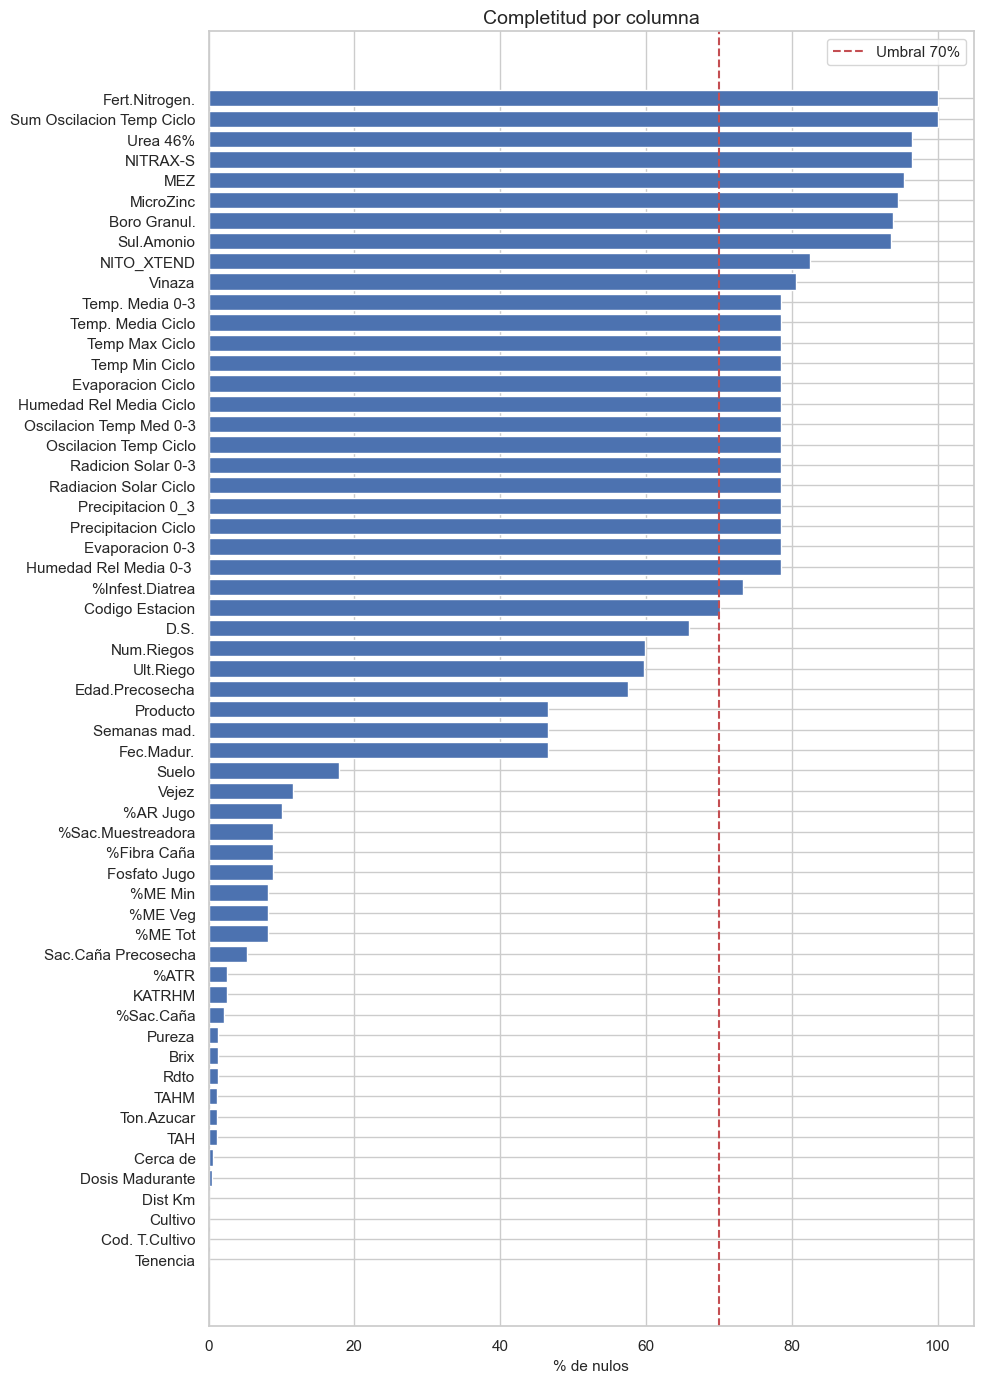


--- Trazabilidad | 3. Completitud ---
Motivo:            nulos ≥ 70%
Columnas antes:    85
Columnas borradas: 26
Columnas quedan:   59
Borradas: ['Fert.Nitrogen.', 'Sum Oscilacion Temp Ciclo', 'Urea 46%', 'NITRAX-S', 'MEZ', 'MicroZinc', 'Boro Granul.', 'Sul.Amonio', 'NITO_XTEND', 'Vinaza', 'Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Evaporacion Ciclo', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Humedad Rel Media 0-3 ', '%Infest.Diatrea', 'Codigo Estacion']
Quedan: ['Período', 'Hacienda', 'Nombre', 'Zona', 'Tenencia', 'Suerte', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'Cod.Estado', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cod. T.Cultivo', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM', 'Ton.

In [7]:
UMBRAL_NULOS = 0.70  # columnas con ≥70 % nulos salen (fertilizantes, estación)

trazabilidad = []


def registrar_recorte(paso, motivo, n_antes, cols_fuera, n_despues):
    """Lleva la cuenta antes / borradas / quedan cada vez que sale un predictor. No modifica el Excel."""
    n_b = len(cols_fuera)
    print(f"\n--- Trazabilidad | {paso} ---")
    print(f"Motivo:            {motivo}")
    print(f"Columnas antes:    {n_antes}")
    print(f"Columnas borradas: {n_b}")
    print(f"Columnas quedan:   {n_despues}")
    trazabilidad.append({
        "paso": paso,
        "motivo": motivo,
        "antes": n_antes,
        "borradas": n_b,
        "quedan": n_despues,
    })

completitud = (
    df_suertes.isna()
    .mean()
    .rename("pct_nulos")
    .to_frame()
    .assign(n_nulos=df_suertes.isna().sum())
    .sort_values("pct_nulos", ascending=False)
)
completitud["pct_nulos"] = completitud["pct_nulos"] * 100

print(f"Columnas con algún nulo: {(completitud['n_nulos'] > 0).sum()} de {len(completitud)}")
print(f"Columnas completas: {(completitud['n_nulos'] == 0).sum()}")
display(completitud[completitud["n_nulos"] > 0])

# Bloques que fallan con el mismo porcentaje (mismo hueco)
con_nulos = completitud[completitud["n_nulos"] > 0]
print("\nColumnas que fallan juntas (mismo % de nulos):")
for pct, g in con_nulos.groupby(con_nulos["pct_nulos"].round(2)):
    if len(g) > 1:
        print(f"  {pct:.2f}% ({len(g)}): {list(g.index)}")

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(con_nulos.index[::-1], con_nulos["pct_nulos"].iloc[::-1], color="#4C72B0")
ax.axvline(UMBRAL_NULOS * 100, color="#C44E52", linestyle="--", label=f"Umbral {UMBRAL_NULOS:.0%}")
ax.set_xlabel("% de nulos")
ax.set_title("Completitud por columna")
ax.legend()
plt.tight_layout()
plt.show()

cols_fuera_nulos = completitud.index[completitud["pct_nulos"] >= UMBRAL_NULOS * 100].tolist()
cols_sin_vacios = [c for c in df_suertes.columns if c not in cols_fuera_nulos]

registrar_recorte(
    "3. Completitud",
    "nulos ≥ 70%",
    len(df_suertes.columns),
    cols_fuera_nulos,
    len(cols_sin_vacios),
)
print("Borradas:", cols_fuera_nulos)
print("Quedan:", cols_sin_vacios)


**Qué muestra este paso**

Hay **58 columnas con nulos** y **27 completas**. Los faltantes no están repartidos al azar: se ven bloques con el mismo porcentaje, o sea el mismo hueco.

| Bloque | % nulos | Qué es |
|---|---|---|
| Fertilizantes (`Urea 46%`, `MEZ`, boro, zinc, vinaza, …) y `Fert.Nitrogen.` | 80–100% | Insumos casi sin registrar |
| Temperatura, humedad, radiación, evaporación, `Precipitacion Ciclo` | **78.46%** (14 columnas iguales) | Estación meteorológica vacía en ~4 de cada 5 filas |
| `%Infest.Diatrea`, `Codigo Estacion` | 73% y 70% | Plaga y código de la estación que no está |
| `D.S.`, riego (`Num.Riegos`, `Ult.Riego`), `Edad.Precosecha` | 58–66% | Intermedio: se quedan |
| Maduración (`Producto`, `Semanas mad.`, `Fec.Madur.`) | ~46% | Intermedio: se quedan |
| `Suelo` y laboratorio | 2–18% | Poco faltante: se quedan |
| Lluvias del lote (ciclo y ventanas) | **0%** | Clima que sí está medido |

**Decisión.** Umbral **≥ 70% nulos → fuera**. **Antes 85 → se borran 26 → quedan 59** (`cols_sin_vacios`, con los dos targets). Imputar fertilizantes o el clima de estación sería inventar la mayor parte de la serie. Las **lluvias del lote** siguen.

**Qué sigue.** Distinguir identificadores (`Nombre`, `Suerte`, `Hacienda`) de medidas del cultivo, usando cardinalidad y el diccionario.


## 4. Identificadores vs medidas

Sobre `cols_sin_vacios`, se separan columnas que **nombran el lote o la finca** de las que describen el cultivo. Un identificador (p. ej. `Nombre`, `Hacienda`) no aporta mecanismo agronómico. La evidencia aquí es cardinalidad + diccionario, no correlación con el target.


In [8]:
n_filas = len(df_suertes)

cardinalidad = pd.DataFrame({
    "columna": cols_sin_vacios,
    "dtype": [str(df_suertes[c].dtype) for c in cols_sin_vacios],
    "n_unicos": [df_suertes[c].nunique(dropna=True) for c in cols_sin_vacios],
    "n_nulos": [int(df_suertes[c].isna().sum()) for c in cols_sin_vacios],
})
cardinalidad["pct_unicos"] = 100 * cardinalidad["n_unicos"] / n_filas
cardinalidad = cardinalidad.sort_values("n_unicos", ascending=False)
display(cardinalidad)

print("Cod.Estado # vs Cod.Estado (¿es el mismo dato en dos formatos?)")
pares_estado = df_suertes[["Cod.Estado #", "Cod.Estado"]].drop_duplicates().sort_values("Cod.Estado #")
display(pares_estado.head(12))
print("Pares distintos:", len(pares_estado))
print(
    "Máximo textos por código:",
    df_suertes.groupby("Cod.Estado #")["Cod.Estado"].nunique().max(),
    "| Máximo códigos por texto:",
    df_suertes.groupby("Cod.Estado")["Cod.Estado #"].nunique().max(),
)

print("\nCod. T.Cultivo vs Cultivo")
display(df_suertes[["Cod. T.Cultivo", "Cultivo"]].drop_duplicates())

print("\nHacienda vs Nombre")
pares_finca = df_suertes[["Hacienda", "Nombre"]].drop_duplicates()
print("Pares distintos:", len(pares_finca),
      "| Haciendas:", df_suertes["Hacienda"].nunique(),
      "| Nombres:", df_suertes["Nombre"].nunique())

print("\nZona (agrupación geográfica, pocos niveles):")
print(df_suertes["Zona"].value_counts(dropna=False).to_string())

cols_fuera_ids = ["Nombre", "Suerte", "Hacienda", "Cod.Estado", "Cod. T.Cultivo"]
cols_sin_ids = [c for c in cols_sin_vacios if c not in cols_fuera_ids]

registrar_recorte(
    "4. Identificadores",
    "IDs y textos duplicados",
    len(cols_sin_vacios),
    cols_fuera_ids,
    len(cols_sin_ids),
)
print("Borradas:", cols_fuera_ids)
print("Quedan:", cols_sin_ids)


,columna,dtype,n_unicos,n_nulos,pct_unicos
26,TCHM,float64,20992,0,99.833547
25,TCH,float64,20931,0,99.543444
36,KATRHM,float64,20505,522,97.517478
24,TonUltCorte,float64,20460,0,97.303467
29,TAH,float64,20444,241,97.227374
30,TAHM,float64,20353,241,96.794597
27,Ton.Azucar,float64,19832,241,94.316831
43,Pureza,float64,16695,269,79.397917
28,Rdto,float64,15448,267,73.467447
41,%ME Tot,float64,15101,1720,71.817187


Cod.Estado # vs Cod.Estado (¿es el mismo dato en dos formatos?)


,Cod.Estado #,Cod.Estado
13,0,Plantilla
8,1,Corte 1
3,2,Corte 2
4,3,Corte 3
2,4,Corte 4
0,5,Corte 5
21,6,Corte 6
23,7,Corte 7
116,8,Corte 8
41,9,Corte 9


Pares distintos: 32
Máximo textos por código: 1 | Máximo códigos por texto: 1

Cod. T.Cultivo vs Cultivo


,Cod. T.Cultivo,Cultivo
0,1.0,Normal
13971,2.0,Organico
18052,NaN,NaN



Hacienda vs Nombre
Pares distintos: 935 | Haciendas: 926 | Nombres: 914

Zona (agrupación geográfica, pocos niveles):
Zona
IP05    7813
IP03    5184
IP06    4113
IP01    2307
IP02    1595
ip05      14
IC07       1

--- Trazabilidad | 4. Identificadores ---
Motivo:            IDs y textos duplicados
Columnas antes:    59
Columnas borradas: 5
Columnas quedan:   54
Borradas: ['Nombre', 'Suerte', 'Hacienda', 'Cod.Estado', 'Cod. T.Cultivo']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num

**Qué muestra este paso**

La cardinalidad parte el set en tres familias:

1. **Identificadores de finca/lote.** `Nombre` (914), `Hacienda` (926) y `Suerte` (1.220) distinguen *quién* es el registro, no cómo se cultivó. El diccionario describe `Nombre` como etiqueta descriptiva. `Hacienda` es el código de esa misma finca (`Nombre` y `Hacienda` van casi 1 a 1). `Suerte` ya es parte de la llave. La ubicación agronómica queda en **`Zona`** (7 niveles: IP01–IP06). `ip05` vs `IP05` es un error de mayúsculas: se unifica en recodificación, no se tira la columna.

2. **El mismo dato dos veces.** `Cod.Estado` y `Cod.Estado #` son 32 pares 1 a 1 (`5` = `Corte 5`). El texto parece un ID; en realidad es la etiqueta del **número de corte**, que sí importa para TCH. Se deja **`Cod.Estado #`** (ordenado: plantilla, corte 1, 2, …) y se saca el texto. Igual con `Cod. T.Cultivo` / `Cultivo` (Normal vs Orgánico): se deja **`Cultivo`**, más legible.

3. **Medidas y categorías de cultivo.** `Zona`, `Tenencia`, `Variedad`, `Suelo`, `T.Corte`, `Tipo Quema`, `Cerca de`, `Período`, etc. tienen pocos niveles o son atributos del ciclo. Siguen, aunque `Cosechó` esté muy concentrado en `AI08`: eso se verá en el univariado.

**Decisión.** Salen del set de predictores: `Nombre`, `Suerte`, `Hacienda`, `Cod.Estado`, `Cod. T.Cultivo`. No se borran del DataFrame (la llave sigue haciendo falta). **Antes 59 → se borran 5 → quedan 54** (`cols_sin_ids`).

**Qué no se decide aquí.** No se tiran `TCHM`, `Rdto` ni laboratorio: todavía no se miró su relación con el target. Siguiente: univariado de `TCH` y `%Sac.Caña`.


## 5. Calidad de categorías

Antes del univariado se unifican etiquetas rotas (mayúsculas, espacios, el mismo producto con y sin tilde). No se descarta ninguna columna: solo se corrige el texto para no partir una categoría en dos.

In [9]:
def mostrar_conteo(col, titulo):
    """Top 12 de frecuencias (con NA) y cuántos niveles tiene una categoría, para ver typos antes de recodificar."""
    print(titulo)
    print(df_suertes[col].value_counts(dropna=False).head(12).to_string())
    print("Niveles:", df_suertes[col].nunique(dropna=True), "\n")

print("Antes de recodificar\n")
mostrar_conteo("Zona", "Zona")
mostrar_conteo("Cosechó", "Cosechó")
print("Suelo: niveles =", df_suertes["Suelo"].nunique(dropna=True),
      "| filas con espacio al final =",
      int(df_suertes["Suelo"].dropna().astype(str).str.endswith(" ").sum()))
print("\nProducto (dos escrituras de BONUS):")
print(
    df_suertes["Producto"]
    .value_counts(dropna=False)
    .loc[lambda s: s.index.astype(str).str.contains("BONUS", case=False, na=False)]
    .to_string()
)

df_suertes["Zona"] = df_suertes["Zona"].str.upper()
df_suertes["Cosechó"] = df_suertes["Cosechó"].str.upper()
df_suertes["Suelo"] = df_suertes["Suelo"].str.strip()
df_suertes["Producto"] = (
    df_suertes["Producto"]
    .str.replace("FISIOLOGICO", "FISIOLÓGICO", regex=False)
)

print("\nDespués de recodificar\n")
mostrar_conteo("Zona", "Zona")
mostrar_conteo("Cosechó", "Cosechó")
print("Suelo: niveles =", df_suertes["Suelo"].nunique(dropna=True))
print("\nProducto BONUS unificado:")
print(
    df_suertes["Producto"]
    .value_counts(dropna=False)
    .loc[lambda s: s.index.astype(str).str.contains("BONUS", case=False, na=False)]
    .to_string()
)

Antes de recodificar

Zona
Zona
IP05    7813
IP03    5184
IP06    4113
IP01    2307
IP02    1595
ip05      14
IC07       1
Niveles: 7 

Cosechó
Cosechó
AI08    19043
2000     1416
ai08      373
AI01       77
0011       42
0010       18
0001       14
0004       11
2200        9
aI08        9
0006        7
0005        4
Niveles: 14 

Suelo: niveles = 102 | filas con espacio al final = 10932

Producto (dos escrituras de BONUS):
Producto
BONUS 250 EC REGULADOR FISIOLÓGICO    7001
BONUS 250 EC REGULADOR FISIOLOGICO    3380

Después de recodificar

Zona
Zona
IP05    7827
IP03    5184
IP06    4113
IP01    2307
IP02    1595
IC07       1
Niveles: 6 

Cosechó
Cosechó
AI08    19425
2000     1416
AI01       79
0011       42
0010       18
0001       14
0004       11
2200        9
0006        7
0005        4
0003        2
Niveles: 11 

Suelo: niveles = 102

Producto BONUS unificado:
Producto
BONUS 250 EC REGULADOR FISIOLÓGICO    10381


In [10]:
# ¿Tenencia, Variedad, Tipo Quema, T.Corte y Cultivo parten niveles por mayúsculas o espacios, como Zona/Cosechó/Suelo?
# Mismo espíritu que los placeholders del paso 3: censo sistemático
cols_categoricas_candidatas = ["Tenencia", "Variedad", "Tipo Quema", "T.Corte", "Cultivo"]

for col in cols_categoricas_candidatas:
    vals = df_suertes[col].dropna().unique()
    vals_series = pd.Series(vals).astype(str)
    # agrupa por versión en mayúsculas + sin espacios sobrantes, para detectar duplicados
    normalizados = vals_series.str.strip().str.upper()
    duplicados = normalizados[normalizados.duplicated(keep=False)]
    if len(duplicados) > 0:
        niveles_afectados = vals_series[normalizados.isin(duplicados)].tolist()
        print(f"{col}: posible duplicado por mayúsculas/espacios -> {niveles_afectados}")
    else:
        print(f"{col}: sin duplicados por mayúsculas/espacios ({len(vals)} niveles)")


Tenencia: sin duplicados por mayúsculas/espacios (7 niveles)
Variedad: sin duplicados por mayúsculas/espacios (58 niveles)
Tipo Quema: sin duplicados por mayúsculas/espacios (5 niveles)
T.Corte: sin duplicados por mayúsculas/espacios (4 niveles)
Cultivo: sin duplicados por mayúsculas/espacios (2 niveles)


**Qué muestra este paso**

- `Zona`: 14 filas `ip05` pasan a `IP05`. Quedan 6 zonas reales de Providencia (IP01–IP06) y **una fila** `IC07` (posible código de otro ingenio o error). No se borra aún; el univariado dirá si conviene sacarla.
- `Cosechó`: `AI08`, `ai08` y `aI08` son el mismo frente de cosecha. Tras unificar, `AI08` concentra casi todo el histórico.
- `Suelo`: miles de celdas traían espacio al final (`CORINTIAS `). El número de niveles no baja (102), pero las etiquetas quedan comparables. Los nulos (~18%) siguen.
- `Producto`: `BONUS 250 EC REGULADOR FISIOLÓGICO` estaba partido por la tilde. Se unifica; los NA de “no maduró” no se tocan.
- `Tenencia`, `Variedad`, `Tipo Quema`, `T.Corte` y `Cultivo`: sin duplicados por mayúsculas/espacios (7, 58, 5, 4 y 2 niveles). Mismo censo que en Zona/Cosechó/Suelo; no hay recodificación.

**Decisión.** Recodificación in-place sobre `df_suertes`. `cols_sin_ids` no cambia. Siguiente: marcar, con la evidencia agronómica de la revisión de literatura, cuáles de esas columnas **deberían** ser predictores, antes de mirar correlaciones.


## 6. Candidatos según el contexto de negocio

Los predictores no se eligen solo por estar en el Excel: se cruzan los factores agronómicos de TCH y sacarosa (edad, variedad, suelo, clima, maduración, riego, distancia) con `cols_sin_ids`. Todavía no se descarta laboratorio ni `Rdto`/`TCHM`: eso espera al análisis de relaciones.

**Alcance de `HISTORICO_SUERTES`.** Este dataset no está filtrado a un subconjunto de manejo: `madurada` es 53.5 % sí / 46.5 % no (paso 9); `T.Corte` mezcla mecanizado (81.4 %) y manual (16.0 %); `Variedad` tiene 58 niveles, no un grupo reducido de las principales. Cualquier conclusión de los modelos de este notebook aplica a esa población amplia (maduradas y no maduradas, mecánica y manual, muchas variedades), no a un subconjunto filtrado de antemano.


In [11]:
# Factores agronómicos de TCH / sacarosa (edad, variedad, suelo, clima, maduración, riego, distancia)
cols_candidatos = [
    "Edad Ult Cos",
    "F.Siembra",
    "F.Ult.Corte",
    "Cod.Estado #",
    "Variedad",
    "Suelo",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "Producto",
    "Lluvias Ciclo",
    "Lluvias 0 -3",
    "Lluvias tres a seis",
    "Lluvias seis a nueve",
    "Luvias 9 -FC",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos",
    "M3 Riego",
    "Zona",
    "Tenencia",
    "T.Corte",
    "Tipo Quema",
    "Cultivo",
    "Destino 1=Semilla",
    "Período",
]

faltan = [c for c in cols_candidatos if c not in cols_sin_ids]
cols_candidatos = [c for c in cols_candidatos if c in cols_sin_ids]
cols_pendientes = [c for c in cols_sin_ids if c not in cols_candidatos and c not in ["TCH", "%Sac.Caña"]]

print("Candidatos presentes en el set de trabajo 2:", len(cols_candidatos))
print(cols_candidatos)
if faltan:
    print("\nCandidatos que ya no están (nulos u IDs):", faltan)

print(f"\nOtras columnas aún en juego (laboratorio, toneladas, fechas extra): {len(cols_pendientes)}")
print(cols_pendientes)

mapa_tarea1 = pd.DataFrame({
    "factor_negocio": [
        "Edad del cultivo",
        "Edad (derivar / validar)",
        "Número de corte (soca)",
        "Variedad",
        "Suelo",
        "Distancia al ingenio",
        "Maduración (dosis)",
        "Maduración (semanas)",
        "Clima / lluvias del lote",
        "Riego",
        "Zona / tenencia / manejo",
    ],
    "columnas": [
        "Edad Ult Cos",
        "F.Siembra, F.Ult.Corte",
        "Cod.Estado #",
        "Variedad",
        "Suelo",
        "Dist Km",
        "Dosis Madurante, Producto",
        "Semanas mad.",
        "Lluvias Ciclo y ventanas; Lluvias (2 Meses Ant.) para sacarosa",
        "Num.Riegos, M3 Riego",
        "Zona, Tenencia, T.Corte, Tipo Quema, Cultivo, Destino 1=Semilla, Período",
    ],
})
display(mapa_tarea1)


Candidatos presentes en el set de trabajo 2: 25
['Edad Ult Cos', 'F.Siembra', 'F.Ult.Corte', 'Cod.Estado #', 'Variedad', 'Suelo', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'Producto', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', 'Lluvias (2 Meses Ant.)', 'Num.Riegos', 'M3 Riego', 'Zona', 'Tenencia', 'T.Corte', 'Tipo Quema', 'Cultivo', 'Destino 1=Semilla', 'Período']

Otras columnas aún en juego (laboratorio, toneladas, fechas extra): 27
['Area Neta', 'D.S.', 'Ult.Riego', 'Fec.Madur.', 'TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'Cerca de', 'Cosechó', 'DDUlt.Riego', 'Fosfato Jugo']


,factor_negocio,columnas
0,Edad del cultivo,Edad Ult Cos
1,Edad (derivar / validar),"F.Siembra, F.Ult.Corte"
2,Número de corte (soca),Cod.Estado #
3,Variedad,Variedad
4,Suelo,Suelo
5,Distancia al ingenio,Dist Km
6,Maduración (dosis),"Dosis Madurante, Producto"
7,Maduración (semanas),Semanas mad.
8,Clima / lluvias del lote,Lluvias Ciclo y ventanas; Lluvias (2 Meses Ant...
9,Riego,"Num.Riegos, M3 Riego"


**Qué muestra este paso**

Los factores agronómicos (clima, suelo, variedad, edad, riego, maduración) **sí tienen columnas** en este Excel, salvo fertilización: esa salió en el paso 3 por 80–100% nulos. Limitación del dato, no del planteamiento.

En `cols_candidatos` quedan `Edad Ult Cos`, `Variedad`, `Suelo`, `Dist Km`, `Dosis Madurante`, `Semanas mad.`, `F.Siembra`. Las lluvias del lote sustituyen a la estación vacía. `F.Siembra` y `F.Ult.Corte` sirven para **validar** la edad, no como 1.400 fechas crudas en el lineal.

Lo demás en `cols_pendientes` (TCHM, TAH, Rdto, Brix, ATR, toneladas, vejez, etc.) no se tira aquí. Puede ser resultado de la misma cosecha: eso se ve en correlaciones y scatters.

**Decisión.** El EDA profundo se concentra en `cols_candidatos` + los dos targets. El resto se revisa en relaciones para justificar descarte. Siguiente: histogramas y boxplots de `TCH` y `%Sac.Caña` (¿normales? ¿outliers de error o de rendimiento extremo?).


## 7. Distribuciones de `TCH` y `%Sac.Caña`

Se inspeccionan forma y colas de los dos targets: si se parecen a una normal, y si los atípicos son errores de registro o cosechas realmente altas/bajas. El TCH extremo se cruza con área y destino (caña vs semilla).


,n,nulos,media,mediana,desv,min,max,asimetría,IQR,límite inf.,límite sup.,n outliers IQR,% outliers,Shapiro W (n=5000),Shapiro p
TCH,21027.0,0,129.608509,129.47960,32.846029,1.573653,401.045947,0.127109,41.716181,46.117155,212.981878,304.0,1.445760,0.996684,4.191009e-09
%Sac.Caña,20578.0,449,12.320202,12.37065,1.145738,7.086000,18.400000,-0.257637,1.468500,9.416250,15.290250,313.0,1.521042,0.994652,1.149441e-12


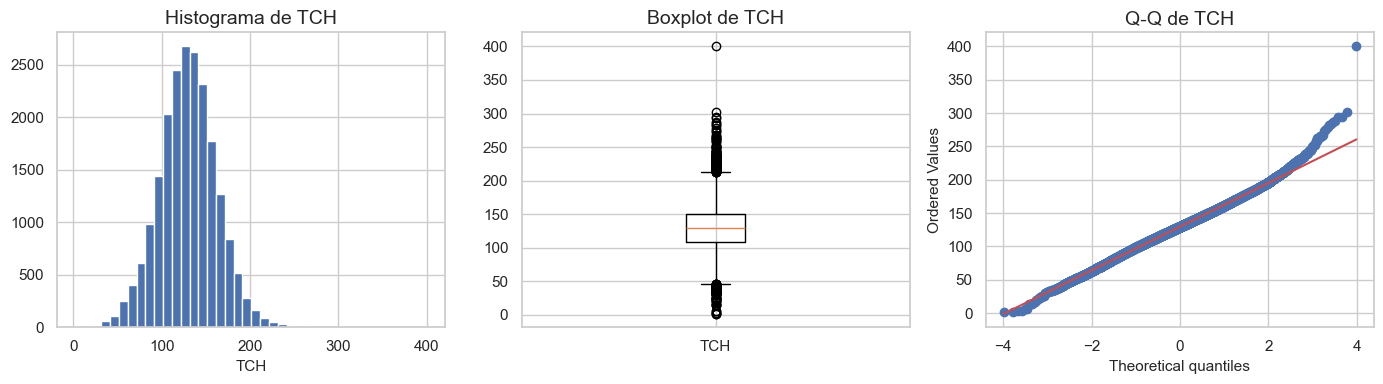

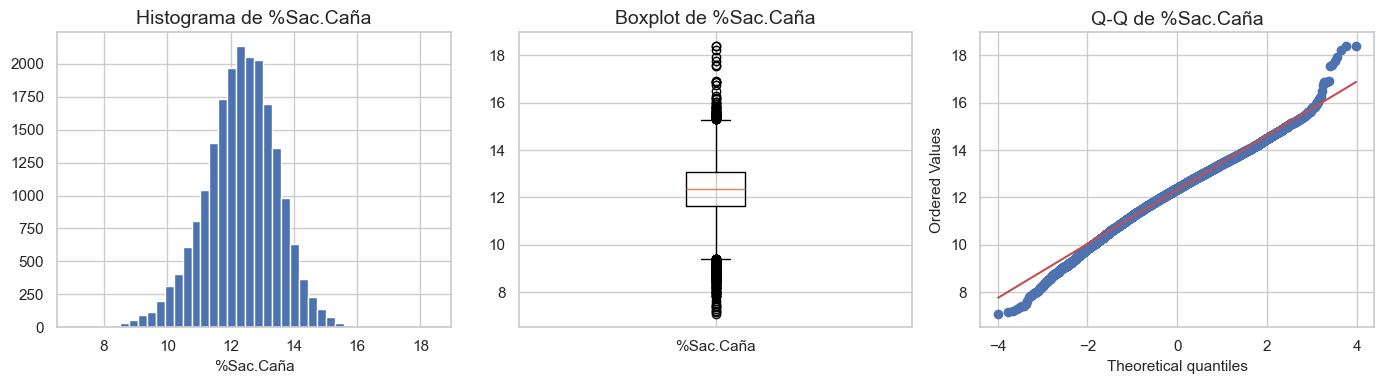

Máxima diferencia |TCH − TonUltCorte/Area Neta|: 9.99637819631971e-07

Outliers IQR de TCH: 304  |  TCH < 50: 172  |  TCH > 250: 28
Más bajos:


,Nombre,Suerte,Período,Area Neta,TonUltCorte,TCH,%Sac.Caña,Destino 1=Semilla,Edad Ult Cos,Variedad
7061,EL JAPON,550,201903,15.41,24.25,1.573653,NaN,1,11.37,RB73-2223
7867,PARANÁ SERVIAGRO,012,201911,2.52,4.62,1.833333,NaN,1,8.25,CC09-235
3208,EL TESORO,002,201803,6.32,19.31,3.055379,11.737,0,5.85,CC85-92
20864,LA PAZ,081H,202406,0.19,0.65,3.421052,NaN,1,9.40,CC09-535
3709,EL TESORITO CAMPOX,130,201805,15.71,94.09,5.989178,11.232,0,15.18,CC01-1940
20681,LA MERCED GARCES,001A,202405,0.38,2.45,6.447368,11.715,0,12.02,CC09-702


Más altos:


,Nombre,Suerte,Período,Area Neta,TonUltCorte,TCH,%Sac.Caña,Destino 1=Semilla,Edad Ult Cos,Variedad
2509,MADROÑAL CASAS INCAUCA,014A,201712,0.10,28.5900,285.900000,12.0390,0,12.91,CC85-92
15645,SAN PABLO AZCARATE,009B,202209,2.00,575.7550,287.877500,10.8830,0,10.45,CC05-430
11535,BETANIA,328,202103,0.88,258.6000,293.863636,9.9326,0,11.56,CC97-7170
8115,FUNDUNGO INVENSA,410,201912,4.99,1471.1500,294.819639,11.7948,0,12.39,PR61-632
5545,LA UNION 1,006B,201901,1.00,301.6080,301.608000,13.6811,0,14.00,CC01-1940
10931,MARSELLA,512B,202012,1.53,613.6003,401.045947,NaN,1,9.89,CC01-1940



TCH medio según destino (0 = molino, 1 = semilla):


,count,mean,50%,min,max
Destino 1=Semilla,,,,,
0,20733.0,130.076288,129.819548,3.055379,301.608000
1,294.0,96.620507,96.734686,1.573653,401.045947



Outliers IQR de %Sac.Caña: 313  |  < 9.42: 244  |  > 15.29: 69
Más bajos:


,Nombre,Suerte,Período,TCH,%Sac.Caña,Dosis Madurante,Tipo Quema,T.Corte,Destino 1=Semilla
18040,ESPERANZA INESA,350B,202306,99.914772,7.0860,0.0,Q.ACCIDENTAL,MECANIZADO,0
2755,EL RANCHO EMPRESA,005A,201801,132.632352,7.1440,0.0,VERDE,MECANIZADO,0
15390,LA PALOMERA OSORIO,001E,202208,107.077777,7.2100,1.2,Q.ACCIDENTAL,MANUAL,0
19949,ZABALETAS EMPRESA,009A,202402,109.557142,7.2700,0.0,NO DEF.,MECANIZADO,0
2513,GALICIA,333,201712,156.200396,7.3761,1.3,VERDE,MECANIZADO,0
1163,LA MARIA MEJIA,001,201707,82.633040,7.4017,0.0,Q.ACCIDENTAL,MECANIZADO,0


Más altos:


,Nombre,Suerte,Período,TCH,%Sac.Caña,Dosis Madurante,Tipo Quema,T.Corte,Destino 1=Semilla
18312,LA LOMA,005,202307,94.450909,17.58,1.2,Q.ACCIDENTAL,MANUAL,0
12903,MALABAR,005A,202110,126.616369,17.77,0.0,VERDE,MECANIZADO,0
12926,MALABAR,001,202110,95.569262,17.92,0.0,VERDE,MECANIZADO,0
12873,AGRICOLA DON MIGUEL,001,202109,119.609911,18.21,0.0,VERDE,MANUAL,0
13040,MALABAR,006A,202110,94.174000,18.39,0.0,VERDE,MECANIZADO,0
12925,MALABAR,002,202110,109.033882,18.40,0.0,VERDE,MECANIZADO,0


In [12]:
def resumen_target(s):
    """Centro, dispersión, outliers IQR (k=1.5) y Shapiro-Wilk sobre una muestra de hasta 5.000 (el test no admite n≈21.000)."""
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    muestra = s.sample(min(5000, len(s)), random_state=0)
    w, p = stats.shapiro(muestra)
    return {
        "n": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "desv": s.std(),
        "min": s.min(),
        "max": s.max(),
        "asimetría": s.skew(),
        "IQR": iqr,
        "límite inf.": lo,
        "límite sup.": hi,
        "n outliers IQR": n_out,
        "% outliers": 100 * n_out / len(s),
        "Shapiro W (n=5000)": w,
        "Shapiro p": p,
    }


resumen_targets = pd.DataFrame({
    "TCH": resumen_target(df_suertes["TCH"]),
    "%Sac.Caña": resumen_target(df_suertes["%Sac.Caña"]),
}).T
resumen_targets.insert(1, "nulos", [df_suertes["TCH"].isna().sum(), df_suertes["%Sac.Caña"].isna().sum()])
display(resumen_targets)

def graficar_target(s, nombre):
    """Histograma, boxplot y Q-Q normal del target (sin nulos). El Q-Q es el supuesto de normalidad a ojo."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(s, bins=40, color="#4C72B0", edgecolor="white")
    axes[0].set_title(f"Histograma de {nombre}")
    axes[0].set_xlabel(nombre)
    axes[1].boxplot(s, vert=True, tick_labels=[nombre])
    axes[1].set_title(f"Boxplot de {nombre}")
    stats.probplot(s, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q de {nombre}")
    plt.tight_layout()
    plt.show()


graficar_target(df_suertes["TCH"].dropna(), "TCH")
graficar_target(df_suertes["%Sac.Caña"].dropna(), "%Sac.Caña")

# El TCH coincide con toneladas / ha; los extremos se miran con área y destino
df_suertes["_tch_calc"] = df_suertes["TonUltCorte"] / df_suertes["Area Neta"]
print(
    "Máxima diferencia |TCH − TonUltCorte/Area Neta|:",
    (df_suertes["TCH"] - df_suertes["_tch_calc"]).abs().max(),
)

q1, q3 = df_suertes["TCH"].quantile(0.25), df_suertes["TCH"].quantile(0.75)
lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
extremos = df_suertes.loc[
    (df_suertes["TCH"] < lo) | (df_suertes["TCH"] > hi),
    ["Nombre", "Suerte", "Período", "Area Neta", "TonUltCorte", "TCH", "%Sac.Caña",
     "Destino 1=Semilla", "Edad Ult Cos", "Variedad"],
].sort_values("TCH")
print(f"\nOutliers IQR de TCH: {len(extremos)}  |  TCH < 50: {(df_suertes['TCH'] < 50).sum()}  |  TCH > 250: {(df_suertes['TCH'] > 250).sum()}")
print("Más bajos:")
display(extremos.head(6))
print("Más altos:")
display(extremos.tail(6))

print("\nTCH medio según destino (0 = molino, 1 = semilla):")
display(df_suertes.groupby("Destino 1=Semilla")["TCH"].describe()[["count", "mean", "50%", "min", "max"]])

q1s, q3s = df_suertes["%Sac.Caña"].quantile(0.25), df_suertes["%Sac.Caña"].quantile(0.75)
lo_s, hi_s = q1s - 1.5 * (q3s - q1s), q3s + 1.5 * (q3s - q1s)
extremos_sac = df_suertes.loc[
    df_suertes["%Sac.Caña"].notna()
    & ((df_suertes["%Sac.Caña"] < lo_s) | (df_suertes["%Sac.Caña"] > hi_s)),
    ["Nombre", "Suerte", "Período", "TCH", "%Sac.Caña", "Dosis Madurante",
     "Tipo Quema", "T.Corte", "Destino 1=Semilla"],
].sort_values("%Sac.Caña")
print(
    f"\nOutliers IQR de %Sac.Caña: {len(extremos_sac)}"
    f"  |  < {lo_s:.2f}: {(df_suertes['%Sac.Caña'] < lo_s).sum()}"
    f"  |  > {hi_s:.2f}: {(df_suertes['%Sac.Caña'] > hi_s).sum()}"
)
print("Más bajos:")
display(extremos_sac.head(6))
print("Más altos:")
display(extremos_sac.tail(6))

df_suertes = df_suertes.drop(columns=["_tch_calc"])


**Qué muestra este paso**

**¿Son normales?** A ojo, ambas son **casi simétricas** (TCH asimetría 0.13; sacarosa −0.26). Media y mediana del TCH coinciden (~130 t/ha). El Q-Q se sale en las colas. Shapiro rechaza con n = 5.000: con tantas filas cualquier desviación mínima da p ≈ 0. No son gaussianas estrictas; para el lineal importan más los **residuos** que el histograma del target.

**Outliers (regla IQR, ~1.5% en cada target).** No se borran por fórmula.

- El TCH **es** `TonUltCorte / Area Neta` (diferencia ~0): no hay error de fórmula.
- TCH muy **bajo** (< 50): 172 filas, 146 de destino molino y 26 de semilla. Los semilleros bajan el TCH medio (~97 vs ~130), por eso `Destino 1=Semilla` está en candidatos; los de molino se juzgan en el paso 9.
- TCH muy **alto** (250–401) suele ser **área chica** (0.1–2 ha). El 401 t/ha es 1.53 ha y destino semilla, sin `%Sac.Caña`. Es influyente; su decisión está en el paso 9. El lineal se puede evaluar con MAE (más robusto que RMSE ante esos puntos).
- `%Sac.Caña` va de 7.1 a 18.4 (media 12.3). Cola baja a menudo con quema accidental y dosis 0; cola alta en verde. Parece calidad real, no un typo.

**Decisión.** Los valores se conservan en el EDA; qué grupos salen del modelo se decide con criterio de negocio en el paso 9 (`excluir_tch`). Siguiente: validar `Edad Ult Cos` contra `F.Siembra` y `F.Ult.Corte`.


--- 1. Correlación entre targets (n = 20578 ) ---
Pearson = -0.168 (r² = 0.028) | Spearman = -0.188

--- 2. Consistencia interna: ¿se sostiene sin semilla y por cultivo? ---
Solo molino (Destino = 0): Pearson = -0.168 | n = 20577
  Normal: Pearson = -0.173 | n = 19888
  Organico: Pearson = -0.039 | n = 687

%Sac.Caña media por decil de TCH:


,TCH_mediana,Sac_media,n
TCH,,,
"(3.0540000000000003, 89.363]",76.36,12.41,2058
"(89.363, 103.873]",97.88,12.58,2058
"(103.873, 113.77]",109.22,12.54,2058
"(113.77, 121.956]",118.09,12.48,2057
"(121.956, 129.77]",125.93,12.43,2058
"(129.77, 137.572]",133.55,12.35,2058
"(137.572, 145.928]",141.63,12.28,2057
"(145.928, 155.94]",150.56,12.22,2058
"(155.94, 170.638]",162.46,12.10,2058


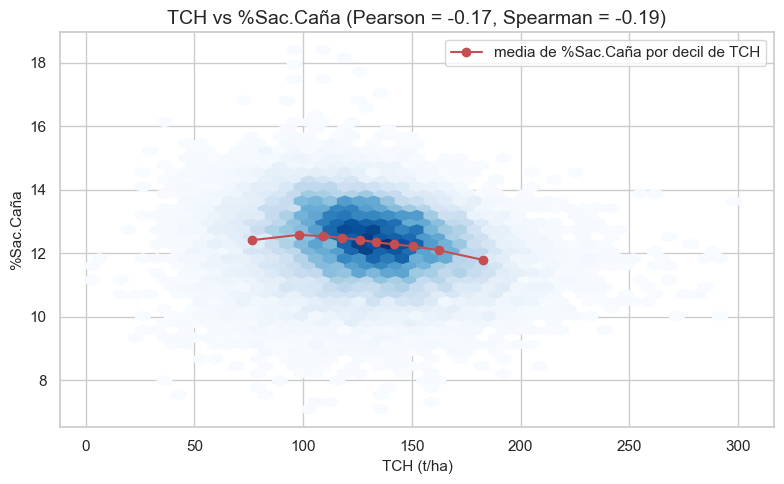

In [13]:
# Relación entre los dos targets: TCH (cantidad) vs %Sac.Caña (calidad).
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes; usa las filas con ambos targets.
ambos_targets = df_suertes[["TCH", "%Sac.Caña", "Destino 1=Semilla", "Cultivo"]].dropna(subset=["TCH", "%Sac.Caña"])
pearson_targets = ambos_targets["TCH"].corr(ambos_targets["%Sac.Caña"], method="pearson")
spearman_targets = ambos_targets["TCH"].corr(ambos_targets["%Sac.Caña"], method="spearman")
print("--- 1. Correlación entre targets (n =", len(ambos_targets), ") ---")
print(f"Pearson = {pearson_targets:.3f} (r² = {pearson_targets**2:.3f}) | Spearman = {spearman_targets:.3f}")

print("\n--- 2. Consistencia interna: ¿se sostiene sin semilla y por cultivo? ---")
solo_molino = ambos_targets[ambos_targets["Destino 1=Semilla"] == 0]
print("Solo molino (Destino = 0): Pearson =", round(solo_molino["TCH"].corr(solo_molino["%Sac.Caña"]), 3), "| n =", len(solo_molino))
for cultivo_actual, grupo_cultivo in solo_molino.groupby("Cultivo"):
    print(f"  {cultivo_actual}: Pearson = {grupo_cultivo['TCH'].corr(grupo_cultivo['%Sac.Caña']):.3f} | n = {len(grupo_cultivo)}")

deciles_tch = pd.qcut(ambos_targets["TCH"], 10, duplicates="drop")
tabla_decil_tch = ambos_targets.groupby(deciles_tch, observed=True).agg(
    TCH_mediana=("TCH", "median"), Sac_media=("%Sac.Caña", "mean"), n=("TCH", "size"))
print("\n%Sac.Caña media por decil de TCH:")
display(tabla_decil_tch.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hexbin(ambos_targets["TCH"], ambos_targets["%Sac.Caña"], gridsize=45, cmap="Blues", mincnt=1)
ax.plot(tabla_decil_tch["TCH_mediana"], tabla_decil_tch["Sac_media"], color="#C44E52", marker="o",
        label="media de %Sac.Caña por decil de TCH")
ax.set_xlabel("TCH (t/ha)")
ax.set_ylabel("%Sac.Caña")
ax.set_title(f"TCH vs %Sac.Caña (Pearson = {pearson_targets:.2f}, Spearman = {spearman_targets:.2f})")
ax.legend()
plt.tight_layout()
plt.show()


**Relación entre `TCH` y `%Sac.Caña`**

Cantidad y calidad son objetivos distintos; antes de modelar se mide cuánto se parecen.

Con n = **20.578** filas que tienen ambos targets, Pearson = **−0.168** (r² = **0.028**) y Spearman = **−0.188**. El TCH explica solo el **2.8 %** de la variación de la sacarosa: la asociación es débil y negativa.

Sin semillero (Destino = 0, n = **20.577**) Pearson sigue en **−0.168**. Por cultivo (mismo subconjunto): `Normal` **−0.173** (n = 19.888) y `Organico` **−0.039** (n = 687). El signo se mantiene; en orgánico la magnitud se acerca a cero.

Por decil de TCH, la `%Sac.Caña` media pasa de **12.41** en el decil bajo (TCH mediana **76.36**) a **11.79** en el alto (mediana **182.80**). Más caña no implica más dulce: en los lotes más productivos la sacarosa media es un poco menor.

Los predictores tampoco coinciden (paso 10, tablas `corr_tch` y `corr_sac`): `Edad Ult Cos` Pearson **0.298** vs TCH y no entra al top 15 vs sacarosa; `Dosis Madurante` Pearson **0.288** vs `%Sac.Caña` y no entra al top 15 vs TCH.

**Decisión.** TCH y `%Sac.Caña` se modelan como dos problemas separados; no se usa un target como predictor del otro; el set candidato de X es común, y cada modelo pesa las X a su manera: los coeficientes de los pasos 18–23 muestran qué predictores importan para cada target. Confianza **Alta** (r² = 2.8 %).


## 8. Edad: `Edad Ult Cos` vs fechas de siembra y corte

Se calcula la edad en meses desde `F.Siembra` hasta `F.Ult.Corte` y se compara con `Edad Ult Cos` (completa, 0 nulos). La pregunta es si son el mismo concepto o dos edades distintas.


,count,mean,std,min,25%,50%,75%,max
Edad Ult Cos,21027.0,13.011110,1.979070,1.310000,11.930000,12.620000,13.860000,78.190000
edad_desde_siembra,21027.0,67.568387,52.054611,5.519507,29.913758,53.880903,86.899384,410.184805
diferencia,21027.0,-54.557277,52.127486,-396.814805,-74.050893,-40.636448,-16.094620,-0.027864


Correlación Edad Ult Cos vs meses desde siembra: -0.018
Correlación meses desde siembra vs n.º de corte: 0.962


,n,Edad Ult Cos (media),meses desde siembra (media),MAE
Cod.Estado #,,,,
0,2677.0,13.686802,14.033902,0.347100
1,2823.0,13.061219,27.075174,14.013955
2,2925.0,12.911874,40.239240,27.327367
3,2820.0,12.931195,52.478471,39.547276
4,2378.0,12.822267,65.101846,52.279579
5,1791.0,12.930469,77.223021,64.292552
6,1337.0,12.823455,90.325289,77.501834
7,1006.0,12.830994,101.884202,89.053208


Plantilla (corte 0): n=2677 | % con |diff| < 0.2 meses: 97.7% | MAE=0.347


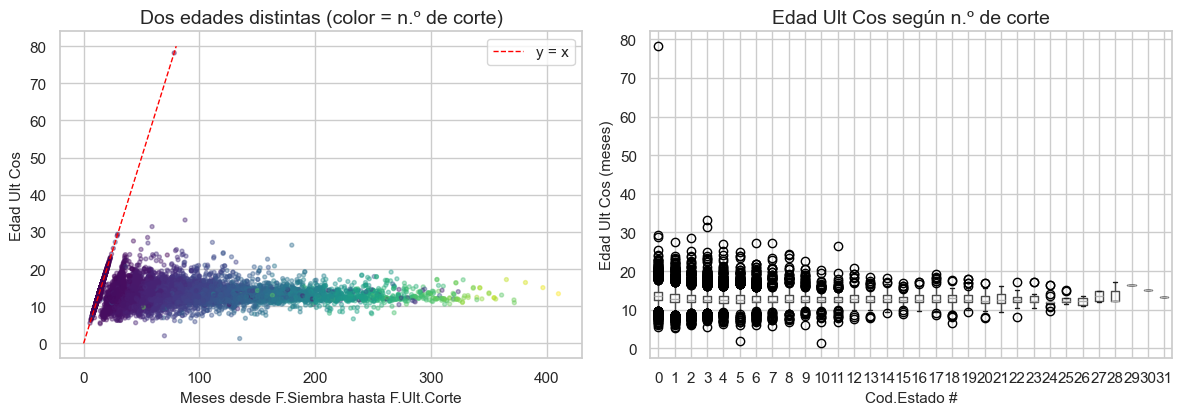

In [14]:
df_suertes["edad_desde_siembra"] = (
    (df_suertes["F.Ult.Corte"] - df_suertes["F.Siembra"]).dt.days / (365.25 / 12)
)

cmp_edad = pd.DataFrame({
    "Edad Ult Cos": df_suertes["Edad Ult Cos"],
    "edad_desde_siembra": df_suertes["edad_desde_siembra"],
})
cmp_edad["diferencia"] = cmp_edad["Edad Ult Cos"] - cmp_edad["edad_desde_siembra"]
display(cmp_edad.describe().T)

print("Correlación Edad Ult Cos vs meses desde siembra:",
      round(df_suertes["Edad Ult Cos"].corr(df_suertes["edad_desde_siembra"]), 3))
print("Correlación meses desde siembra vs n.º de corte:",
      round(df_suertes["edad_desde_siembra"].corr(df_suertes["Cod.Estado #"]), 3))

por_corte = (
    df_suertes.groupby("Cod.Estado #")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "Edad Ult Cos (media)": g["Edad Ult Cos"].mean(),
            "meses desde siembra (media)": g["edad_desde_siembra"].mean(),
            "MAE": (g["Edad Ult Cos"] - g["edad_desde_siembra"]).abs().mean(),
        }),
        include_groups=False,
    )
    .head(8)
)
display(por_corte)

plantilla = df_suertes["Cod.Estado #"] == 0
dif_plant = (df_suertes.loc[plantilla, "Edad Ult Cos"] - df_suertes.loc[plantilla, "edad_desde_siembra"]).abs()
print(
    f"Plantilla (corte 0): n={int(plantilla.sum())} | "
    f"% con |diff| < 0.2 meses: {100 * (dif_plant < 0.2).mean():.1f}% | "
    f"MAE={dif_plant.mean():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(
    df_suertes["edad_desde_siembra"],
    df_suertes["Edad Ult Cos"],
    c=df_suertes["Cod.Estado #"],
    cmap="viridis",
    s=8,
    alpha=0.4,
)
axes[0].plot([0, 80], [0, 80], color="red", linestyle="--", linewidth=1, label="y = x")
axes[0].set_xlabel("Meses desde F.Siembra hasta F.Ult.Corte")
axes[0].set_ylabel("Edad Ult Cos")
axes[0].set_title("Dos edades distintas (color = n.º de corte)")
axes[0].legend()

df_suertes.boxplot(column="Edad Ult Cos", by="Cod.Estado #", ax=axes[1])
axes[1].set_title("Edad Ult Cos según n.º de corte")
axes[1].set_xlabel("Cod.Estado #")
axes[1].set_ylabel("Edad Ult Cos (meses)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Qué muestra este paso**

No son la misma variable. Restar fechas **no reproduce** `Edad Ult Cos` (correlación ≈ 0; la derivada llega a 400 meses).

- **`Edad Ult Cos`** ≈ 13 meses en todos los cortes: edad de **este ciclo** (siembra o último corte → cosecha).
- **Meses desde `F.Siembra`** crece con `Cod.Estado #` (corr ≈ 0.96): edad de la **cepa** desde que se plantó el lote (1986…), no la del tallo que se está cortando.

Solo en **plantilla (corte 0)** coinciden: 97.6% de las filas con diferencia &lt; 0.2 meses. En corte 1 en adelante la cepa ya lleva varios ciclos y las fechas de siembra ya no son la edad a cosecha.

**Decisión.** El predictor agronómico de productividad de *este* corte es **`Edad Ult Cos`**. `F.Siembra` y `F.Ult.Corte` no entran crudas al lineal. Se deja `edad_desde_siembra` como variable derivada (edad de cepa), casi redundante con el número de corte: el VIF dirá si se puede usar junto a `Cod.Estado #`.

Siguiente: univariado del resto de `cols_candidatos` (zona, variedad, suelo, lluvias, madurante, riego).


## 9. Univariado de los candidatos

Distribución de las variables señaladas como predictores agronómicos (salvo la edad, ya vista). Interesa cómo están partidas las categorías, si hay colas raras y si un **cero** es dato real o un nulo disfrazado (dosis, riego, lluvias).


### 9.1 Categorías y ceros/nulos

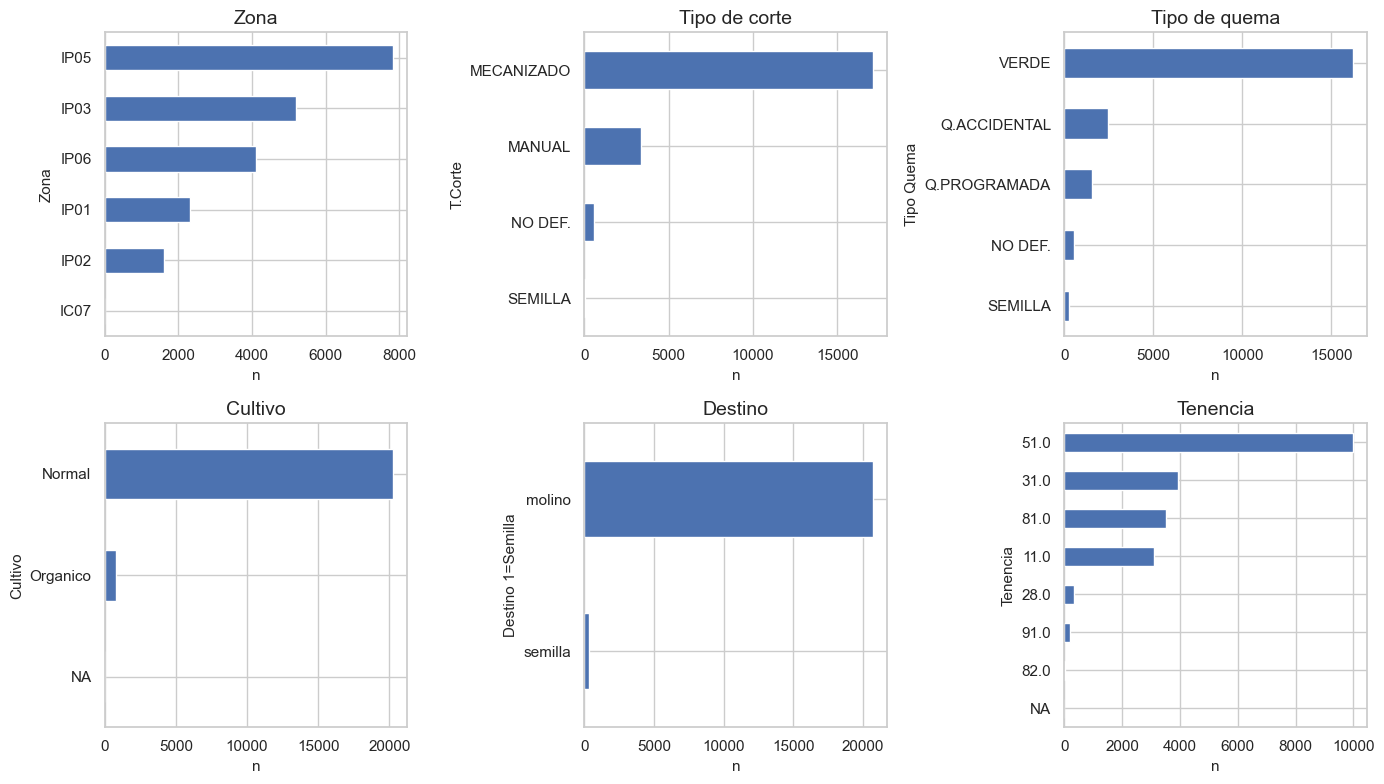

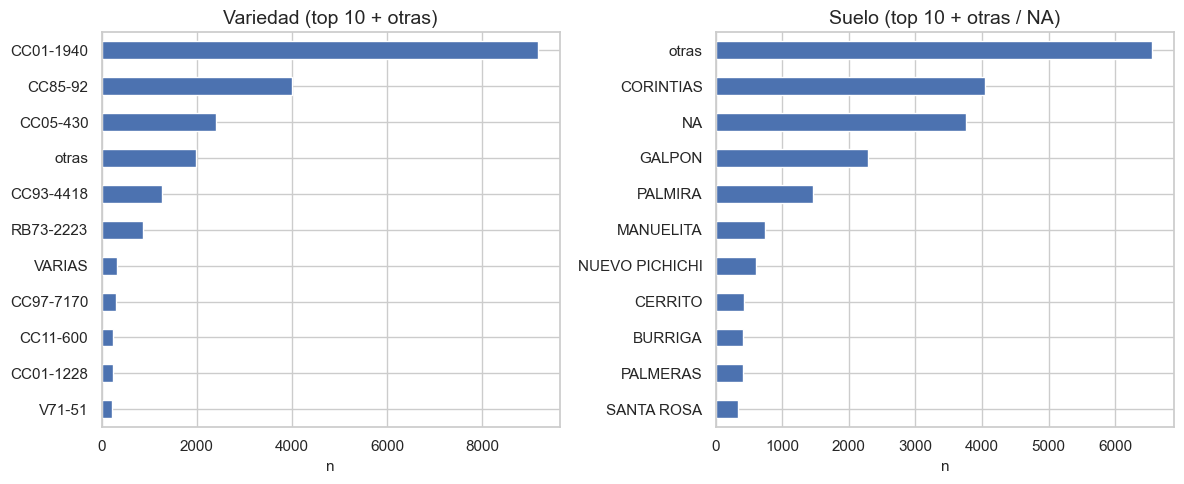

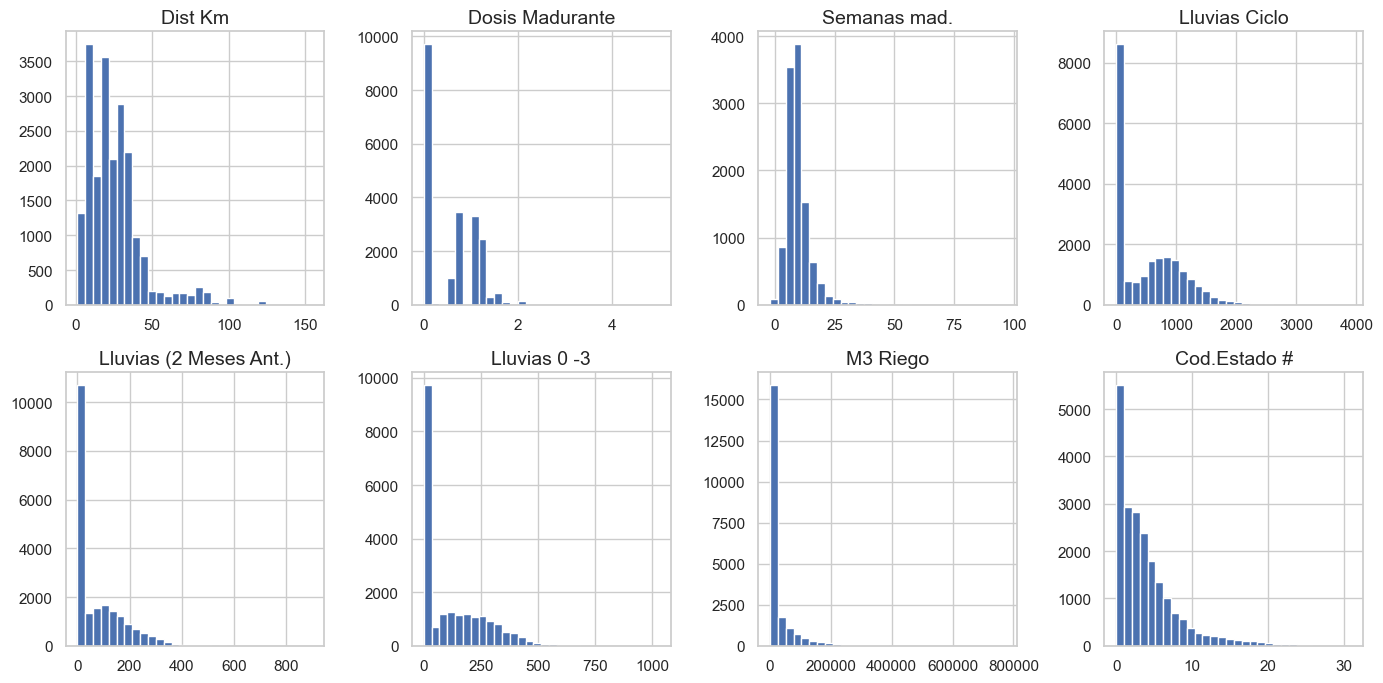

,columna,nulos,% nulos,ceros
0,Dosis Madurante,104,0.494602,9685.0
1,Semanas mad.,9775,46.487849,2.0
2,Producto,9778,46.502116,NaN
3,Num.Riegos,12589,59.870643,0.0
4,M3 Riego,0,0.000000,12557.0
5,Lluvias Ciclo,0,0.000000,7739.0
6,Lluvias (2 Meses Ant.),0,0.000000,10064.0
7,Suelo,3758,17.872259,NaN


Dosis = 0 y Producto nulo: 9671
Dosis nula y Producto nulo: 104
Num.Riegos nulo y M3 Riego = 0: 12557
Num.Riegos nulo y M3 Riego > 0: 32
Semanas mad. < 0: 13
Variedad CC01-1940: 43.6%


In [15]:
def barras_top(serie, titulo, ax, top=10, incluir_na=True):
    """Barras de los `top` niveles más frecuentes; el resto se funde en 'otras'. Por defecto top=10 e incluye NA."""
    vc = serie.value_counts(dropna=False) if incluir_na else serie.value_counts(dropna=True)
    vc.index = vc.index.map(lambda x: "NA" if pd.isna(x) else str(x))
    if len(vc) > top:
        otros = vc.iloc[top:].sum()
        vc = pd.concat([vc.iloc[:top], pd.Series({"otras": otros})])
    vc.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(titulo)
    ax.set_xlabel("n")


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
barras_top(df_suertes["Zona"], "Zona", axes[0, 0], top=10)
barras_top(df_suertes["T.Corte"], "Tipo de corte", axes[0, 1], top=10)
barras_top(df_suertes["Tipo Quema"], "Tipo de quema", axes[0, 2], top=10)
barras_top(df_suertes["Cultivo"], "Cultivo", axes[1, 0], top=10)
barras_top(df_suertes["Destino 1=Semilla"].map({0: "molino", 1: "semilla"}), "Destino", axes[1, 1], top=10)
barras_top(df_suertes["Tenencia"], "Tenencia", axes[1, 2], top=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
barras_top(df_suertes["Variedad"], "Variedad (top 10 + otras)", axes[0], top=10)
barras_top(df_suertes["Suelo"], "Suelo (top 10 + otras / NA)", axes[1], top=10)
plt.tight_layout()
plt.show()

num_univar = [
    "Dist Km", "Dosis Madurante", "Semanas mad.",
    "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Lluvias 0 -3",
    "M3 Riego", "Cod.Estado #",
]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_univar):
    s = df_suertes[col].dropna()
    ax.hist(s, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

cero_na = []
for col in ["Dosis Madurante", "Semanas mad.", "Producto", "Num.Riegos", "M3 Riego",
            "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Suelo"]:
    s = df_suertes[col]
    n_na = int(s.isna().sum())
    n_cero = int((s == 0).sum()) if pd.api.types.is_numeric_dtype(s) else np.nan
    cero_na.append({"columna": col, "nulos": n_na, "% nulos": 100 * n_na / len(df_suertes),
                    "ceros": n_cero})
display(pd.DataFrame(cero_na))

print("Dosis = 0 y Producto nulo:", int(((df_suertes["Dosis Madurante"] == 0) & df_suertes["Producto"].isna()).sum()))
print("Dosis nula y Producto nulo:", int((df_suertes["Dosis Madurante"].isna() & df_suertes["Producto"].isna()).sum()))
print("Num.Riegos nulo y M3 Riego = 0:", int((df_suertes["Num.Riegos"].isna() & (df_suertes["M3 Riego"] == 0)).sum()))
print("Num.Riegos nulo y M3 Riego > 0:", int((df_suertes["Num.Riegos"].isna() & (df_suertes["M3 Riego"] > 0)).sum()))
print("Semanas mad. < 0:", int((df_suertes["Semanas mad."] < 0).sum()))
print("Variedad CC01-1940:", f"{100 * (df_suertes['Variedad'] == 'CC01-1940').mean():.1f}%")

**Qué muestra este paso**

La cosecha es mayormente mecanizada y en verde, y el destino semilla es raro (294 de 21.027 filas), lo que coincide con los TCH extremos que ya habíamos visto: esos valores bajos no eran un patrón grande, eran justo esta minoría. El cultivo orgánico es apenas ~3.6% del total, y la zona está desbalanceada: IP05 domina el dataset mientras que IC07 es una sola fila suelta.

`Variedad` tiene 58 niveles, pero CC01-1940 concentra el 43.6% y las 5 más frecuentes suman ~84%, así que el resto queda repartido en variedades con muy pocas filas cada una. Si esas entran crudas al modelo lineal, generan columnas casi vacías e inestables, por lo que va a haber que agruparlas en "otras" más adelante. Lo mismo pasa con `Suelo`: 102 tipos y 3.758 nulos, también para agrupar.

En cuanto a ceros y nulos, no todo cero significa lo mismo, así que toca revisar caso por caso antes de imputar. En maduración, la dosis en 0 (9.685 filas) casi siempre coincide con `Producto` nulo, lo que indica que no es un hueco sino que simplemente no se maduró ese lote — los 104 NA de dosis son el mismo caso, y `Semanas mad.` queda nula en paralelo. Los pocos valores negativos que aparecen ahí sí son error de captura puntual, no parte del patrón. Con el riego pasa algo parecido: `Num.Riegos` queda nulo cuando `M3 Riego` es 0 (12.557 filas), así que ese nulo en realidad significa "cero riegos", no un vacío al azar; solo 32 filas tienen metros cúbicos mayores a 0 con el número de riegos nulo, y esas sí parecen un vacío real de captura.

Con las lluvias el caso es distinto: no hay nulos, pero sí muchísimos ceros (7.739 en `Lluvias Ciclo`, más de 10.000 en la de dos meses antes). Un ciclo de más de un año con 0 mm de lluvia no tiene sentido en el Valle del Cauca, así que probablemente esos ceros sean la estación sin registrar, no que de verdad no haya llovido. Ese caso se deja para revisarlo con más cuidado en la sección de atípicos, acá no se toca todavía.

Por ahora ningún candidato sale del análisis. Queda anotado para la imputación: agrupar variedad y suelo raros en "otras", `Dosis Madurante` NA a 0, y `Num.Riegos` NA a 0 cuando el riego real sea 0. El siguiente paso es mirar cómo se relaciona cada variable con los targets (TCH contra edad, sacarosa contra lluvia de maduración, matriz de correlación completa), que es donde se va a definir qué variables son fuga de información, como `Rdto` o `TCHM`.

### 9.2 Unidades, Suelo y Tenencia

In [16]:
# Verificación de unidades. Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
cols_unidades = ["Edad Ult Cos", "Dosis Madurante", "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Area Neta"]
print("--- 1. Perfil (rango observado) ---")
display(df_suertes[cols_unidades].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(3))
print("Nulos:", df_suertes[cols_unidades].isna().sum().to_dict())
print("Ceros:", {c: int((df_suertes[c] == 0).sum()) for c in cols_unidades})

print("\nEdad Ult Cos: p5–p95 =",
      round(df_suertes["Edad Ult Cos"].quantile(0.05), 2), "–",
      round(df_suertes["Edad Ult Cos"].quantile(0.95), 2),
      "| min/max =", df_suertes["Edad Ult Cos"].min(), df_suertes["Edad Ult Cos"].max())
print("  ¿Cabe en meses 10–18? masa en p5–p95 sí. ¿Semanas 40–75? no (mediana 12.6). ¿Días 300–550? no.")

print("\nDosis Madurante > 0:")
display(df_suertes.loc[df_suertes["Dosis Madurante"] > 0, "Dosis Madurante"]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T.round(3))

print("\n--- 2. Consistencia interna ---")
plant = df_suertes["Cod.Estado #"] == 0
delta_mes = (df_suertes.loc[plant, "F.Ult.Corte"] - df_suertes.loc[plant, "F.Siembra"]).dt.days / 30.437
edad_p = df_suertes.loc[plant, "Edad Ult Cos"]
print("Plantilla (corte 0): n =", int(plant.sum()),
      "| mediana |Edad Ult Cos − (F.Ult.Corte−F.Siembra).days/30.437| =",
      round((edad_p - delta_mes).abs().median(), 3))

dosis_prod = (
    df_suertes.assign(Producto=df_suertes["Producto"].astype("string").str.strip().str.upper())
    .groupby("Producto")["Dosis Madurante"]
    .agg(mediana="median", media="mean", min="min", max="max", n="count")
    .sort_values("n", ascending=False)
    .head(8)
)
print("Dosis por Producto (top 8):")
display(dosis_prod.round(3))

print("\nProducto: value_counts completo (tras unificar BONUS):")
prod_u = df_suertes["Producto"].astype("string").str.strip().str.upper()
display(prod_u.value_counts(dropna=False).rename("n").to_frame())

# Flag actual: (Dosis > 0) OR (Producto no nulo). ¿Cuántos Producto no son madurante?
no_madurante = {
    "FERTILIZANTE LIQUIDO RENDIMIENTO",
    "AGROFOSK-M",
    "FERTILIZANTE ORGÁNICO PATER-M",
    "HERBICIDA CLICK 40 SC",
    "AMINA 2-4-D",
    "TRANSLOK",  # fertilizante foliar (llenado), no regulador
}
coadyuvante = {"COADYUVANTE  DOUCE", "COADYUVANTE DOUCE"}
madurada = (df_suertes["Dosis Madurante"].fillna(0) > 0) | df_suertes["Producto"].notna()
n_mad = int(madurada.sum())
es_no = prod_u.isin(no_madurante)
es_coad = prod_u.str.replace(r"\s+", " ", regex=True).eq("COADYUVANTE DOUCE")
print("madurada=1 (definición actual):", n_mad)
print("Producto no madurante (fertilizante / herbicida de arroz / 2,4-D / Translok): n =",
      int(es_no.sum()), f"| % de madurada=1 = {100*es_no.sum()/n_mad:.2f}%")
print("  de ellos con Dosis>0:", int((es_no & (df_suertes["Dosis Madurante"].fillna(0) > 0)).sum()),
      "| solo Producto.notna (Dosis≤0):", int((es_no & (df_suertes["Dosis Madurante"].fillna(0) <= 0)).sum()))
print("Coadyuvante DOUCE (no es el i.a. madurante): n =", int(es_coad.sum()),
      f"| % de madurada=1 = {100*es_coad.sum()/n_mad:.2f}%")
print("Si el flag solo cambia el brazo Producto.notna → nombre de madurante, delta =",
      int(n_mad - ((df_suertes["Dosis Madurante"].fillna(0) > 0) | prod_u.str.contains(
          r"BONUS|TRONNUSPAC|FUSILADE|ROUND-UP|GLIFOLAQ|BIO SAFE|OTROS MADURANTES|ENSAYO",
          regex=True, na=False)).sum()),
      "(casi todo lo cubre Dosis>0).")

tch_calc = df_suertes["TonUltCorte"] / df_suertes["Area Neta"]
print("Area Neta: max |TCH − TonUltCorte/Area Neta| =", (df_suertes["TCH"] - tch_calc).abs().max())
print("  Si Area Neta estuviera en m², TCH mediano sería",
      round((df_suertes["TonUltCorte"] / (df_suertes["Area Neta"] / 10_000)).median(), 1),
      "t/ha (absurdo).")


--- 1. Perfil (rango observado) ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Edad Ult Cos,21027.0,13.011,1.979,1.310,10.58,11.93,12.62,13.860,16.43,19.250,78.19
Dosis Madurante,20923.0,0.536,0.540,0.000,0.00,0.00,0.60,1.000,1.30,1.700,5.00
Lluvias Ciclo,21027.0,526.176,551.550,0.000,0.00,0.00,450.00,921.000,1495.70,2065.740,3917.00
Lluvias (2 Meses Ant.),21027.0,75.116,98.054,0.000,0.00,0.00,24.00,131.000,271.00,379.000,902.00
Area Neta,21027.0,8.643,7.050,0.004,0.81,3.31,7.00,12.075,22.33,30.877,65.00


Nulos: {'Edad Ult Cos': 0, 'Dosis Madurante': 104, 'Lluvias Ciclo': 0, 'Lluvias (2 Meses Ant.)': 0, 'Area Neta': 0}
Ceros: {'Edad Ult Cos': 0, 'Dosis Madurante': 9685, 'Lluvias Ciclo': 7739, 'Lluvias (2 Meses Ant.)': 10064, 'Area Neta': 0}

Edad Ult Cos: p5–p95 = 10.58 – 16.43 | min/max = 1.31 78.19
  ¿Cabe en meses 10–18? masa en p5–p95 sí. ¿Semanas 40–75? no (mediana 12.6). ¿Días 300–550? no.

Dosis Madurante > 0:


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Dosis Madurante,11238.0,0.999,0.284,0.05,0.5,0.8,1.0,1.2,1.5,2.0,5.0



--- 2. Consistencia interna ---
Plantilla (corte 0): n = 2677 | mediana |Edad Ult Cos − (F.Ult.Corte−F.Siembra).days/30.437| = 0.062
Dosis por Producto (top 8):


,mediana,media,min,max,n
Producto,,,,,
BONUS 250 EC REGULADOR FISIOLÓGICO,1.0,1.001,0.2,2.5,10381
COADYUVANTE DOUCE,1.0,0.866,0.3,5.0,380
FERTILIZANTE LIQUIDO RENDIMIENTO,0.6,0.741,0.2,2.0,179
FUSILADE 2000 BL,0.6,0.789,0.1,1.6,84
AGROFOSK-M,2.0,1.981,1.0,2.0,54
MADURANTE REGULADOR TRONNUSPAC 250 EC,0.7,0.860,0.5,1.4,36
FERTILIZANTE ORGÁNICO PATER-M,2.0,1.677,0.3,2.0,31
ROUND-UP MONSANTO 747 GRANULADO,1.3,1.159,0.6,1.4,29



Producto: value_counts completo (tras unificar BONUS):


,n
Producto,
BONUS 250 EC REGULADOR FISIOLÓGICO,10381
<NA>,9778
COADYUVANTE DOUCE,380
FERTILIZANTE LIQUIDO RENDIMIENTO,179
FUSILADE 2000 BL,84
AGROFOSK-M,54
MADURANTE REGULADOR TRONNUSPAC 250 EC,36
FERTILIZANTE ORGÁNICO PATER-M,31
ROUND-UP MONSANTO 747 GRANULADO,29


madurada=1 (definición actual): 11252
Producto no madurante (fertilizante / herbicida de arroz / 2,4-D / Translok): n = 274 | % de madurada=1 = 2.44%
  de ellos con Dosis>0: 273 | solo Producto.notna (Dosis≤0): 1
Coadyuvante DOUCE (no es el i.a. madurante): n = 380 | % de madurada=1 = 3.38%
Si el flag solo cambia el brazo Producto.notna → nombre de madurante, delta = 14 (casi todo lo cubre Dosis>0).
Area Neta: max |TCH − TonUltCorte/Area Neta| = 9.99637819631971e-07
  Si Area Neta estuviera en m², TCH mediano sería 1294796.0 t/ha (absurdo).


In [17]:
# Categorías: Suelo y Tenencia. Mismo formato de evidencia que D.S. / Cerca de (perfil → consistencia → sector → decisión).
print("--- Suelo: top 30 por frecuencia ---")
suelo = df_suertes["Suelo"].astype("string").str.strip()
print("nulos =", int(suelo.isna().sum()), f"({100 * suelo.isna().mean():.1f}%)",
      "| niveles =", suelo.nunique(dropna=True))
display(suelo.value_counts(dropna=False).head(30).rename("n").to_frame())

nom = df_suertes["Nombre"].astype("string").str.strip().str.upper()
suel_u = suelo.str.upper()
inter_nombre = sorted(set(suel_u.dropna()) & set(nom.dropna()))
print("Niveles Suelo que también aparecen como Nombre (topónimo compartido, no prueba de ID):",
      len(inter_nombre), inter_nombre)

print("\n--- Tenencia: códigos ---")
ten = df_suertes["Tenencia"]
print("nulos =", int(ten.isna().sum()), "| niveles =", ten.nunique(dropna=True))
display(ten.value_counts(dropna=False).rename("n").to_frame())
display(df_suertes.groupby("Tenencia")[["TCH", "%Sac.Caña"]].agg(["mean", "count"]).round(2))


--- Suelo: top 30 por frecuencia ---
nulos = 3758 (17.9%) | niveles = 102


,n
Suelo,
CORINTIAS,4042
<NA>,3758
GALPON,2282
PALMIRA,1457
MANUELITA,742
NUEVO PICHICHI,599
CERRITO,431
BURRIGA,415
PALMERAS,407


Niveles Suelo que también aparecen como Nombre (topónimo compartido, no prueba de ID): 9 ['ARANJUEZ', 'BRITANIA', 'CHAMBURO', 'CHONTADURO', 'CORINTO', 'LA PAZ', 'MARSELLA', 'SAN CAMILO', 'SANTA ELENA']

--- Tenencia: códigos ---
nulos = 1 | niveles = 7


,n
Tenencia,
51.0,9968
31.0,3916
81.0,3528
11.0,3089
28.0,326
91.0,186
82.0,13
NaN,1


TCH       %Sac.Caña      
            mean count      mean count
Tenencia                              
11.0      126.30  3089     11.90  2788
28.0      122.99   326     12.55   319
31.0      130.68  3916     12.44  3882
51.0      132.67  9968     12.44  9881
81.0      123.67  3528     12.17  3509
82.0      128.35    13     10.95    13
91.0      121.70   186     12.35   185

**Unidades y categorías raras (cierre del univariado)**

Mismo orden de evidencia que las variables sin ficha: perfil → consistencia interna → nomenclatura de sector → decisión.

**`Edad Ult Cos` — meses del ciclo actual, confianza alta.**
El rango observado (mediana **12.62**, p5–p95 **10.58–16.43**, min 1.31, máx 78.19, con n = 21.027 y 0 nulos) no calza con semanas (habría que esperar valores entre 40 y 75) ni con días (entre 300 y 550) — solo tiene sentido en meses. Esto se confirma cruzando la fecha de siembra contra la de corte en los lotes de plantilla (corte 0, n = 2.677): la mediana de |edad − días(F.Ult.Corte − F.Siembra)/30.437| es apenas **0.062**. Cenicaña reporta que la cosecha ocurre a los 12–14 meses y la aplicación del madurante a los 10–12, justo el rango que se observa aquí. El máximo de 78.19 es cola; el 99 % de los datos está por debajo de 19.25.

**`Dosis Madurante` — L/ha de producto comercial, confianza razonable–alta.**
En los lotes con dosis mayor a cero (n = 11.238), la mediana es **1.0** L/ha, con p25–p75 de **0.8–1.2**, p95 de 1.5 y máximo de 5.0. El producto más frecuente, `BONUS 250 EC` (presente en 10.381 filas), tiene mediana entre 1.0 y 1.1 L/ha. El **250** en el nombre del producto se refiere a la concentración (**250 g/L de trinexapac-etil**), no a la dosis de campo. La columna `Producto` incluye también la etiqueta `PRODUCTO ENSAYO EN LITROS`, que confirma la unidad. La literatura especializada indica que el trinexapac a 250 g/L se aplica en dosis de ~**0.8–1.0 L/ha**, y Cenicaña ajusta esta dosis según variedad y clima, sin recomendar un único valor fijo. Aunque el diccionario del dataset no incluye una ficha explícita de unidad, el rango observado y la nomenclatura del producto encajan con L/ha.

**`Lluvias Ciclo` — milímetros en el ciclo, confianza alta.**
La distribución muestra mediana 450 mm, p75 de 921 mm, p95 de 1.496 mm y máximo de 3.917 mm; además, hay **7.739 registros en cero**. El Valle del río Cauca tiene una precipitación anual de ~**1.000–1.500 mm** (Asocaña reporta ~1.400 mm; Cenicaña registra 795 mm en Rozo y 1.970 mm en Viterbo), así que un ciclo de ~13 meses puede acumular ese orden de magnitud. Si la unidad fuera centímetros, estaríamos hablando de 4.5 metros de agua, lo cual no tiene sentido. Los ceros ya se anotaron en el análisis (corresponden a sequía o estaciones meteorológicas que reportaron cero), y no invalidan la interpretación de la unidad como milímetros.

**`Lluvias (2 Meses Ant.)` — milímetros en ~60 días, confianza alta.**
La mediana es 24 mm, el p75 es 131 mm, el p95 es 271 mm y el máximo es 902 mm; hay 10.064 registros en cero. Dos meses húmedos en la región del Valle del Cauca suelen acumular entre 100 y 300 mm (por ejemplo, noviembre de 2010 registró 297 mm a nivel regional). El valor máximo de 902 mm es cola alta, pero está dentro del orden de magnitud esperado para milímetros, descartando kilómetros o centímetros como unidades alternativas.

**`Area Neta` — hectáreas, confianza alta.**
La identidad `TCH ≈ TonUltCorte / AreaNeta` (diferencia máxima ~10⁻⁶) prueba que TCH está calculado dividiendo toneladas por el valor de `Area Neta`. Si `Area Neta` estuviera en m², el TCH mediano sería del orden de ~1.3 millones de t/ha, lo cual es absurdo. La distribución muestra mediana 7.0 ha y máximo 65 ha, rango razonable para lotes agrícolas. Esa identidad matemática es la prueba definitiva de que el denominador de TCH está en hectáreas, no en m².

| Variable | Confianza y unidad |
|---|---|
| `Edad Ult Cos` | Alta — meses del ciclo actual |
| `Dosis Madurante` | Razonable–alta — L/ha de producto comercial |
| `Lluvias Ciclo` | Alta — milímetros en el ciclo |
| `Lluvias (2 Meses Ant.)` | Alta — milímetros en ~60 días |
| `Area Neta` | Alta — hectáreas |


**Resto de `Producto` (no solo BONUS).** `value_counts` completo: 17 etiquetas no nulas (11.249 filas). Además de BONUS:

- **Sí son madurantes químicos en caña (Cenicaña: glifosato, fluazifop-p-butil, trinexapac-etil).** `MADURANTE REGULADOR TRONNUSPAC 250 EC` (36; mismo 250 g/L de trinexapac). `FUSILADE 2000 BL` (84; fluazifop-p-butil): es herbicida graminicida, **pero en Colombia está registrado como madurante de caña a 0.5–0.6 L/ha** (4–6 semanas antes del corte); la mediana aquí es **0.6**, la dosis de maduración, no la de maleza (1.5–2.0 L/ha). Hasta los 90, Fusilade 2000 y Roundup eran los únicos madurantes registrados en el país. `ROUND-UP MONSANTO 747 GRANULADO` (29; mediana 1.3): glifosato; Cenicaña lo usa como testigo comercial (0.75–1.5 L/ha). `MADURANTE BIO SAFE ORGANIC` (17) y `OTROS MADURANTES` (4) se autodescriben. `PRODUCTO ENSAYO EN LITROS` (18) es ensayo, unidad litros. `GLIFOLAQ` (1) es glifosato.
- **No son madurantes.** `FERTILIZANTE LIQUIDO RENDIMIENTO` (179; foliar). `AGROFOSK-M` (54; fosfato/potasio foliar, no un regulador). `FERTILIZANTE ORGÁNICO PATER-M` (31). `TRANSLOK` (7; foliar de llenado). `HERBICIDA CLICK 40 SC` (1; bispiribac, arroz). `AMINA 2-4-D` (2; herbicida auxínico, no está en la terna Cenicaña).
- **No es el principio activo.** `COADYUVANTE DOUCE` (380): surfactante de tanque. El lote *pudo* madurarse con otro producto no anotado; el nombre solo no prueba maduración.
- **Indeterminado** (n chico): `baykal` (22), `GREEN LIFE` (3).

**Impacto en `madurada` = (Dosis > 0) ∨ (Producto no nulo).** `madurada = 1` en **11.252** filas. Producto claramente no madurante: **274** filas (fertilizantes, incluido Translok, + CLICK + 2,4-D) = **2.44 %** de las `madurada=1`. Casi todas tienen también Dosis > 0: si solo se restringe el brazo `Producto.notna()`, el flag **apenas se mueve (14 filas, 0.12 %)**: 13 `baykal` con dosis 0 y 1 CLICK. Incluir el coadyuvante sumaría 380 (3.38 %); el conjunto no-madurante+coadyuvante sería 5.81 %, pero el coadyuvante no se puede tratar como falso positivo seguro.

**Decisión sobre el flag: (a) limitación documentada, no se cambia.** 274 filas son más que "unas decenas", pero el 2.4 % no mueve el VIF de alerta (~8.5) ni los signos del OLS: esas filas ya tienen dosis > 0 y `madurada=1` a la vez, que es exactamente el patrón de colinealidad. Una corrección estricta (lista de exclusión + anular dosis en no-madurantes) se deja escrita como alternativa. Lista de exclusión de la alternativa: `FERTILIZANTE LIQUIDO RENDIMIENTO`, `AGROFOSK-M`, `FERTILIZANTE ORGÁNICO PATER-M`, `TRANSLOK`, `HERBICIDA CLICK 40 SC`, `AMINA 2-4-D`. `FUSILADE` y `ROUND-UP` **no** entran en esa lista.




**`Suelo` — nomenclatura de suelos del Valle del Cauca, no de hacienda, confianza razonable–alta.**
La columna tiene 102 niveles con 3.758 nulos (17.9 %). Los más frecuentes son CORINTIAS (4.042 filas), GALPON (2.282), PALMIRA, MANUELITA, NUEVO PICHICHI, CERRITO, BURRIGA y PALMERAS. Estos nombres corresponden a **conjuntos y consociaciones** del estudio semidetallado de suelos realizado por Cenicaña, el IGAC y la CVC (por ejemplo, Galpón GL, Burriga BU, Manuelita MN, Corintias), no a identificadores de finca. Solo **9** de los 102 nombres coinciden con el campo `Nombre` de hacienda, y esas coincidencias se explican por topónimos compartidos (Marsella, Chontaduro, etc.), no porque la columna esté duplicando el identificador. El caso de `CERRITO-NIMA` confirma esto: es una asociación de series de suelo, no un ID. La cardinalidad alta es la del mapa de series, no un identificador disfrazado. Por esta razón, `Suelo` **no** se trata como `Nombre` o `Hacienda`, y agrupar los niveles con frecuencia baja en una categoría `OTRAS` sigue siendo válido.

**`Tenencia` — relación jurídica lote–productor, etiqueta desconocida, confianza ambigua residual.**
La columna contiene códigos numéricos: **11, 28, 31, 51, 81, 82, 91** (más 1 nulo). El código 51 cubre 9.968 filas, casi la mitad del dataset. La clasificación estándar del DANE y la Encuesta Nacional Agropecuaria (ENA) habla de categorías como propia, arrendada, aparcería, usufructo y comodato, pero **sin asignar estos números específicos**. El diccionario del Excel no traduce los códigos a etiquetas, así que el significado exacto de cada número queda desconocido. La variable entra al modelo como dummy (el mismo caso de `D.S.` en las filas marcadas literalmente `DS`), pero no se puede afirmar con certeza que "51 = propia" o cualquier otra interpretación específica.

| Variable | Confianza y significado |
|---|---|
| `Suelo` | Razonable–alta — nomenclatura de suelos del Valle del Cauca |
| `Tenencia` | Ambigua residual — relación jurídica lote–productor (códigos sin traducción) |

`Edad Ult Cos` queda en **meses**, así que un coeficiente del lineal se lee en t/ha por mes. `Dosis Madurante` queda en L/ha y las lluvias en mm. El ruido de fertilizante en `Producto` (**2.4 %** de `madurada=1`) es una limitación del flag: el OLS deja fuera `madurada` por VIF y se queda con `Dosis Madurante`. `Tenencia` sigue sin traducción de los códigos.

In [18]:
# Significado del vacío en Suelo (17.9 % nulos): ¿es informativo o falta al azar?
# Orden: 1 perfil → 2 consistencia interna → 3 decisión (markdown).
def pct_por_grupo(mascara, agrupador, etiqueta, resumen=None):
    """% de mascara=True dentro de cada nivel de agrupador; para hacienda, además resume todas/ninguna/mezcladas."""
    if resumen is not None:
        frac = mascara.groupby(agrupador).mean()
        todas, ninguna = resumen
        print("Haciendas: todas sus filas " + todas + " =", round(100 * (frac == 1).mean(), 1),
              "% | ninguna " + ninguna + " =", round(100 * (frac == 0).mean(), 1),
              "% | mezcladas =", round(100 * ((frac > 0) & (frac < 1)).mean(), 1), "%")
        return frac
    pct = (mascara.groupby(agrupador).mean() * 100).round(1)
    display(pct.to_frame(f"% {etiqueta}").T)
    return pct


mask_suelo_nulo = df_suertes["Suelo"].isna()
print("--- 1. Perfil: Suelo nulo por año, zona y hacienda ---")
anio_periodo = df_suertes["Período"] // 100
pct_por_grupo(mask_suelo_nulo, anio_periodo, "Suelo nulo")
pct_por_grupo(mask_suelo_nulo, df_suertes["Zona"], "Suelo nulo")
pct_por_grupo(mask_suelo_nulo, df_suertes["Hacienda"], "Suelo nulo", resumen=("con Suelo nulo", "nula"))

print("\n--- 2. Consistencia: ¿el vacío se asocia con los targets o con otras variables? ---")
display(df_suertes.groupby(mask_suelo_nulo)[["TCH", "%Sac.Caña"]].agg(["mean", "count"]).round(2))
print("Cod.Estado # (nº de corte) medio: nulo =", round(df_suertes.loc[mask_suelo_nulo, "Cod.Estado #"].mean(), 2),
      "| con dato =", round(df_suertes.loc[~mask_suelo_nulo, "Cod.Estado #"].mean(), 2))
print("Cultivo orgánico: % en Suelo nulo =", round(100 * (df_suertes.loc[mask_suelo_nulo, "Cultivo"] == "Organico").mean(), 1),
      "| % en Suelo con dato =", round(100 * (df_suertes.loc[~mask_suelo_nulo, "Cultivo"] == "Organico").mean(), 1))


--- 1. Perfil: Suelo nulo por año, zona y hacienda ---


Período,2017,2018,2019,2020,2021,2022,2023,2024
% Suelo nulo,14.4,17.2,17.8,23.4,24.2,16.7,14.1,13.7


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% Suelo nulo,100.0,8.8,3.2,16.5,31.2,5.1


Haciendas: todas sus filas con Suelo nulo = 47.9 % | ninguna nula = 43.1 % | mezcladas = 9.0 %

--- 2. Consistencia: ¿el vacío se asocia con los targets o con otras variables? ---


TCH        %Sac.Caña       
         mean  count      mean  count
Suelo                                
False  130.85  17269     12.33  16847
True   123.91   3758     12.30   3731

Cod.Estado # (nº de corte) medio: nulo = 4.64 | con dato = 4.18
Cultivo orgánico: % en Suelo nulo = 0.0 | % en Suelo con dato = 4.4


**El vacío en `Suelo`: ¿informativo o al azar?**

Mismo orden: perfil → consistencia interna → decisión.

**Perfil.** El nulo cubre **3.758** filas (**17.9 %**). Por año no es un solo hueco: va de **13.7 %** (2024) a **24.2 %** (2021), con pico en 2020–2021 (**23.4 %** y **24.2 %**). Por zona sí se concentra: **IP05 31.2 %**, **IP03 16.5 %**; el resto queda en **3.2–8.8 %** (IC07 es 100 %, pero es 1 fila). En haciendas el patrón es de finca, no de fila: de 926 haciendas, **47.9 %** tienen `Suelo` nulo en **todas** sus filas, **43.1 %** no tienen ningún nulo y solo **9.0 %** mezclan. Eso es “esta finca nunca tuvo levantamiento de suelo”.

**Clasificación.** **Probablemente informativo (finca sin estudio agronómico, no MCAR).**

**Consistencia.** TCH medio **123.91** sin suelo vs **130.85** con dato (n = 3.758 / 17.269): **6.94 t/ha** menos, diferencia relevante. `%Sac.Caña` casi no se mueve (**12.30** vs **12.33**; n = 3.731 / 16.847). `Cod.Estado #` medio **4.64** (nulo) vs **4.18** (con dato). Cultivo orgánico: **0.0 %** entre nulos y **4.4 %** entre filas con dato.

**Decisión.** La imputación correcta es una categoría explícita `SIN DATO`, no la moda por zona: esa moda hace desaparecer la señal de “finca sin estudio”. Mismo criterio que `Producto` → `SIN MADURANTE`.

Esto ajusta la imputación de `Suelo` que se aplica más adelante, en el paso 16.


### 9.3 Columnas fuera del modelo: fertilizantes, estación y fuga

In [19]:
# Auditoría de columnas que nunca entraron a cols_candidatos.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
pcts = [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

print("--- 1. Perfil: Vejez, TAH/TAHM, KATRHM, Edad.Precosecha ---")
cols_core = ["Vejez", "TAH", "TAHM", "KATRHM", "%ATR", "Edad.Precosecha", "Edad Ult Cos", "TCH", "%Sac.Caña", "Rdto", "Ton.Azucar"]
display(df_suertes[cols_core].describe(percentiles=pcts).T.round(3))
print("Nulos:", df_suertes[cols_core].isna().sum().to_dict())

print("\nVejez: p5–p95 =",
      round(df_suertes["Vejez"].quantile(0.05), 3), "–",
      round(df_suertes["Vejez"].quantile(0.95), 3),
      "| min/max =", df_suertes["Vejez"].min(), df_suertes["Vejez"].max())
print("  ¿Cabe en horas (~0–72, cola a ~200)? masa en p25–p50 sí (2.1–2.7). ¿Días 1–10? no explica p95=57 ni el cruce con quema. ¿Semanas? no (mediana 2.7).")

print("\n--- 2. Consistencia interna ---")
print("Vejez por Tipo Quema:")
display(df_suertes.groupby("Tipo Quema")["Vejez"].describe(percentiles=[0.5, 0.95]).round(2))
print("Vejez por T.Corte:")
display(df_suertes.groupby("T.Corte")["Vejez"].describe(percentiles=[0.5, 0.95]).round(2))

m_tah = df_suertes[["TAH", "Ton.Azucar", "Area Neta"]].notna().all(axis=1)
tah_ha = df_suertes.loc[m_tah, "Ton.Azucar"] / df_suertes.loc[m_tah, "Area Neta"]
print("TAH vs Ton.Azucar/Area Neta: n =", int(m_tah.sum()),
      "| max |diff| =", (df_suertes.loc[m_tah, "TAH"] - tah_ha).abs().max())

m_rdto = df_suertes[["TAH", "TCH", "Rdto"]].notna().all(axis=1) & (df_suertes["Rdto"] > 0)
tah_rdto = df_suertes.loc[m_rdto, "TCH"] * df_suertes.loc[m_rdto, "Rdto"] / 100
print("TAH vs TCH×Rdto/100: n =", int(m_rdto.sum()),
      "| mediana |diff| =", (df_suertes.loc[m_rdto, "TAH"] - tah_rdto).abs().median())

m_sac = df_suertes[["TAH", "TCH", "%Sac.Caña"]].notna().all(axis=1) & (df_suertes["%Sac.Caña"] > 0)
tah_sac = df_suertes.loc[m_sac, "TCH"] * df_suertes.loc[m_sac, "%Sac.Caña"] / 100
ratio_sac = df_suertes.loc[m_sac, "TAH"] / tah_sac
print("TAH / (TCH×%Sac.Caña/100): mediana =", round(ratio_sac.median(), 4),
      "| p25–p75 =", round(ratio_sac.quantile(0.25), 4), "–", round(ratio_sac.quantile(0.75), 4),
      "(recuperación de fábrica < pol en caña)")

m_hm = df_suertes[["TAHM", "TAH", "Edad Ult Cos"]].notna().all(axis=1) & (df_suertes["Edad Ult Cos"] > 0)
tahm_edad = df_suertes.loc[m_hm, "TAH"] / df_suertes.loc[m_hm, "Edad Ult Cos"]
print("TAHM vs TAH/Edad Ult Cos: n =", int(m_hm.sum()),
      "| max |diff| =", (df_suertes.loc[m_hm, "TAHM"] - tahm_edad).abs().max())

m_k = df_suertes[["KATRHM", "TCHM", "%ATR"]].notna().all(axis=1)
katr_calc = df_suertes.loc[m_k, "TCHM"] * df_suertes.loc[m_k, "%ATR"] / 100 * 1000
print("KATRHM vs TCHM×%ATR/100×1000: n =", int(m_k.sum()),
      "| mediana |diff| =", (df_suertes.loc[m_k, "KATRHM"] - katr_calc).abs().median(),
      "| max |diff| =", (df_suertes.loc[m_k, "KATRHM"] - katr_calc).abs().max())

m_pre = df_suertes[["Edad.Precosecha", "Edad Ult Cos"]].notna().all(axis=1)
delta_pre = df_suertes.loc[m_pre, "Edad Ult Cos"] - df_suertes.loc[m_pre, "Edad.Precosecha"]
print("\nEdad.Precosecha vs Edad Ult Cos: n ambas =", int(m_pre.sum()),
      "| corr =", round(df_suertes.loc[m_pre, ["Edad.Precosecha", "Edad Ult Cos"]].corr().iloc[0, 1], 3))
print("  Edad Ult − Precosecha: mediana =", round(delta_pre.median(), 3),
      "| % Precosecha < Ult =", round((df_suertes.loc[m_pre, "Edad.Precosecha"] < df_suertes.loc[m_pre, "Edad Ult Cos"]).mean(), 3))
print("  Precosecha p5–p95 =",
      round(df_suertes["Edad.Precosecha"].quantile(0.05), 2), "–",
      round(df_suertes["Edad.Precosecha"].quantile(0.95), 2),
      "| ¿meses 10–18? sí. ¿semanas 40–75? no. ¿días 300–550? no.")

print("\n--- Fertilizantes (subconjunto no nulo) y Fosfato Jugo ---")
cols_fert = ["Urea 46%", "MEZ", "Fosfato Jugo", "Fert.Nitrogen.", "Boro Granul.",
             "MicroZinc", "NITO_XTEND", "Sul.Amonio", "NITRAX-S", "Vinaza"]
fert_tab = df_suertes[cols_fert].describe(percentiles=pcts).T
fert_tab["nulos"] = df_suertes[cols_fert].isna().sum()
fert_tab["pct_nulos"] = (100 * df_suertes[cols_fert].isna().mean()).round(2)
display(fert_tab.round(3))

print("Si las dosis N fueran kg totales del lote, kg/ha = valor/Area Neta (mediana):")
for c in ["Urea 46%", "MEZ", "Boro Granul.", "MicroZinc", "NITO_XTEND", "Sul.Amonio", "NITRAX-S", "Vinaza"]:
    m = df_suertes[c].notna() & (df_suertes["Area Neta"] > 0)
    perha = df_suertes.loc[m, c] / df_suertes.loc[m, "Area Neta"]
    print(f"  {c}: n={int(m.sum())}  crudo p50={df_suertes.loc[m, c].median():.1f}  /ha p50={perha.median():.1f}")

print("\n--- Estación meteorológica ---")
cols_clima = [
    "Temp. Media 0-3", "Temp. Media Ciclo", "Temp Max Ciclo", "Temp Min Ciclo",
    "Humedad Rel Media 0-3 ", "Humedad Rel Media Ciclo",
    "Oscilacion Temp Med 0-3", "Oscilacion Temp Ciclo", "Sum Oscilacion Temp Ciclo",
    "Radicion Solar 0-3", "Radiacion Solar Ciclo",
    "Precipitacion 0_3", "Precipitacion Ciclo",
    "Evaporacion 0-3", "Evaporacion Ciclo",
]
clima_tab = df_suertes[cols_clima].describe(percentiles=pcts).T
clima_tab["nulos"] = df_suertes[cols_clima].isna().sum()
clima_tab["pct_nulos"] = (100 * df_suertes[cols_clima].isna().mean()).round(2)
display(clima_tab.round(3))

print("\n--- Cobertura temporal de la estación meteorológica ---")
col_estacion_representativa = "Temp. Media Ciclo"  # representativa: mismo patrón de nulos que las 14 columnas de estación
mask_estacion_con_dato = df_suertes[col_estacion_representativa].notna()
anio_periodo = df_suertes["Período"] // 100
print("Períodos con al menos una fila con dato de estación:", sorted(df_suertes.loc[mask_estacion_con_dato, "Período"].unique())[:3],
      "...", sorted(df_suertes.loc[mask_estacion_con_dato, "Período"].unique())[-3:])
display((mask_estacion_con_dato.groupby(anio_periodo).agg(["sum", "count", "mean"])).rename(columns={"sum": "con_dato", "count": "n", "mean": "%_con_dato"}).round(3))
print("Primer período con dato:", df_suertes.loc[mask_estacion_con_dato, "Período"].min(),
      "| último período SIN dato:", df_suertes.loc[~mask_estacion_con_dato, "Período"].max())

m_osc = df_suertes[["Oscilacion Temp Ciclo", "Temp. Media Ciclo"]].notna().all(axis=1)
print("Oscilacion Temp Ciclo vs Temp. Media Ciclo: max |diff| =",
      (df_suertes.loc[m_osc, "Oscilacion Temp Ciclo"] - df_suertes.loc[m_osc, "Temp. Media Ciclo"]).abs().max(),
      "| iguales =", (df_suertes.loc[m_osc, "Oscilacion Temp Ciclo"] == df_suertes.loc[m_osc, "Temp. Media Ciclo"]).all())
print("Radiación ciclo / 0-3 (ambas > 0): mediana =",
      round((df_suertes.loc[(df_suertes["Radiacion Solar Ciclo"] > 0) & (df_suertes["Radicion Solar 0-3"] > 0), "Radiacion Solar Ciclo"]
             / df_suertes.loc[(df_suertes["Radiacion Solar Ciclo"] > 0) & (df_suertes["Radicion Solar 0-3"] > 0), "Radicion Solar 0-3"]).median(), 3))
print("  ¿cal/cm²·día (Cenicaña ~400–450)? mediana ciclo =",
      round(df_suertes["Radiacion Solar Ciclo"].median(), 1),
      "| ¿MJ/m²·día 15–20? no. ¿horas de brillo 5–8? no.")


--- 1. Perfil: Vejez, TAH/TAHM, KATRHM, Edad.Precosecha ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Vejez,18582.0,12.294,20.994,0.017,1.429,2.108,2.737,10.757,57.282,96.347,205.650
TAH,20786.0,13.889,3.805,0.000,7.584,11.690,14.015,16.298,19.611,22.422,72.168
TAHM,20786.0,1.071,0.285,0.000,0.601,0.909,1.088,1.253,1.490,1.671,5.192
KATRHM,20505.0,1372.454,341.454,49.089,811.661,1165.487,1383.493,1586.078,1881.360,2114.788,15466.533
%ATR,20505.0,13.719,1.452,7.750,11.777,13.016,13.753,14.472,15.475,16.264,144.450
Edad.Precosecha,8919.0,12.360,1.421,0.000,11.070,11.530,12.090,12.940,14.820,16.490,23.520
Edad Ult Cos,21027.0,13.011,1.979,1.310,10.580,11.930,12.620,13.860,16.430,19.250,78.190
TCH,21027.0,129.609,32.846,1.574,75.360,108.691,129.480,150.408,182.745,210.731,401.046
%Sac.Caña,20578.0,12.320,1.146,7.086,10.330,11.619,12.371,13.088,14.065,14.849,18.400
Rdto,20760.0,10.734,1.517,0.000,8.687,10.117,10.891,11.598,12.537,13.223,15.894


Nulos: {'Vejez': 2445, 'TAH': 241, 'TAHM': 241, 'KATRHM': 522, '%ATR': 522, 'Edad.Precosecha': 12108, 'Edad Ult Cos': 0, 'TCH': 0, '%Sac.Caña': 449, 'Rdto': 267, 'Ton.Azucar': 241}

Vejez: p5–p95 = 1.429 – 57.282 | min/max = 0.017 205.65
  ¿Cabe en horas (~0–72, cola a ~200)? masa en p25–p50 sí (2.1–2.7). ¿Días 1–10? no explica p95=57 ni el cruce con quema. ¿Semanas? no (mediana 2.7).

--- 2. Consistencia interna ---
Vejez por Tipo Quema:


,count,mean,std,min,50%,95%,max
Tipo Quema,,,,,,,
NO DEF.,64.0,11.85,22.99,1.16,2.86,38.21,116.04
Q.ACCIDENTAL,2268.0,47.73,31.49,0.02,42.35,105.67,205.65
Q.PROGRAMADA,1448.0,33.13,18.15,0.18,33.24,62.22,147.33
SEMILLA,97.0,9.93,16.14,0.43,2.41,44.84,89.73
VERDE,14705.0,4.79,8.66,0.02,2.47,19.95,143.70


Vejez por T.Corte:


...

Si las dosis N fueran kg totales del lote, kg/ha = valor/Area Neta (mediana):
  Urea 46%: n=723  crudo p50=881.0  /ha p50=194.8
  MEZ: n=971  crudo p50=350.0  /ha p50=53.3
  Boro Granul.: n=1285  crudo p50=80.0  /ha p50=14.5
  MicroZinc: n=1149  crudo p50=100.0  /ha p50=15.7
  NITO_XTEND: n=3679  crudo p50=1600.0  /ha p50=244.4
  Sul.Amonio: n=1357  crudo p50=1700.0  /ha p50=251.2
  NITRAX-S: n=748  crudo p50=1121.0  /ha p50=172.7
  Vinaza: n=4098  crudo p50=53100.0  /ha p50=6098.5

--- Estación meteorológica ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,nulos,pct_nulos
Temp. Media 0-3,4530.0,23.376,1.254,22.040,22.608,22.857,23.100,23.358,24.949,29.956,32.362,16497,78.46
Temp. Media Ciclo,4530.0,24.556,2.472,22.353,22.704,22.946,23.202,25.660,30.128,31.122,32.358,16497,78.46
Temp Max Ciclo,4530.0,34.588,0.985,32.600,33.300,33.700,34.500,35.400,36.000,37.000,38.300,16497,78.46
Temp Min Ciclo,4530.0,15.416,0.488,13.900,14.500,15.200,15.400,15.600,16.300,16.700,17.300,16497,78.46
Humedad Rel Media 0-3,4530.0,81.177,2.849,60.341,75.901,80.110,81.576,83.132,84.522,85.538,86.495,16497,78.46
Humedad Rel Media Ciclo,4530.0,80.765,2.752,63.327,75.057,80.038,81.292,82.440,83.715,84.213,84.816,16497,78.46
Oscilacion Temp Med 0-3,4530.0,16.060,1.300,12.500,14.200,15.200,15.700,16.800,18.700,19.100,19.700,16497,78.46
Oscilacion Temp Ciclo,4530.0,24.556,2.472,22.353,22.704,22.946,23.202,25.660,30.128,31.122,32.358,16497,78.46
Sum Oscilacion Temp Ciclo,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21027,100.00
Radicion Solar 0-3,4530.0,435.119,21.307,352.013,398.531,421.345,436.591,449.274,468.104,478.579,500.212,16497,78.46



--- Cobertura temporal de la estación meteorológica ---
Períodos con al menos una fila con dato de estación: [202202, 202203, 202204] ... [202405, 202406, 202407]


,con_dato,n,%_con_dato
Período,,,
2017,0,2517,0.000
2018,0,2879,0.000
2019,0,2852,0.000
2020,0,2889,0.000
2021,0,2504,0.000
2022,1648,2932,0.562
2023,1941,3022,0.642
2024,941,1432,0.657


Primer período con dato: 202202 | último período SIN dato: 202407
Oscilacion Temp Ciclo vs Temp. Media Ciclo: max |diff| = 0.0 | iguales = True
Radiación ciclo / 0-3 (ambas > 0): mediana = 1.011
  ¿cal/cm²·día (Cenicaña ~400–450)? mediana ciclo = 439.1 | ¿MJ/m²·día 15–20? no. ¿horas de brillo 5–8? no.


**Columnas fuera de `cols_candidatos` (cierre de las 85 columnas originales)**

Mismo orden: perfil → consistencia interna → nomenclatura de sector → decisión. Ninguna de estas variables entra al lineal; el objetivo es documentar unidad y por qué el descarte se sostiene.


**`Vejez` — horas desde corte/quema hasta molino (deterioro poscosecha), confianza alta.**
La variable tiene n = 18.582 (11.6 % nulos), con mediana **2.74** horas, p25 **2.11**, p75 **10.76**, p95 **57.28** y máximo **205.65**. No es un valor entero. Por tipo de quema, la mediana es **2.47** h para `VERDE`, **42.35** h para `Q.ACCIDENTAL` y **33.24** h para `Q.PROGRAMADA`. Por tipo de corte, `MECANIZADO` tiene mediana **2.57** h versus `MANUAL` con **37.70** h. Si la unidad fuera días, los valores de 42 (quema accidental) y 205 (máximo) no calzarían con la logística típica de un patio de ingenio; en cambio, como horas sí tiene sentido: 2.5 h para caña verde, 42 h (~1.8 días) para quema no programada, y la cola de 205 h = 8.6 días entra dentro del rango de deterioro documentado en la literatura (7–11 días). `Vejez` no se deriva de TCH ni de sacarosa, pero solo se conoce después del corte, cuando la caña llega al molino. Por eso es fuga de información para un modelo que busca anticipar el resultado antes de la cosecha, y no es candidata a predictor; el recorte del paso 14 la dejó fuera del modelo.

**`TAH` — toneladas de azúcar por hectárea (azúcar recuperado, no sacarosa en tallo), confianza alta.**
La variable tiene n = 20.786, con mediana **14.02** t/ha y p5–p95 de **7.58–19.61** (Cenicaña reporta ~13.6–14.5 TAH). La identidad `TAH ≈ Ton.Azucar / Area Neta` (diferencia máxima ~10⁻⁶) confirma que `TAH` es exactamente la división de las toneladas de azúcar entre el área. También se cumple `TAH = TCH × Rdto / 100` con diferencia mediana de ~6×10⁻⁵, prácticamente cero. Al comparar `TAH` con `TCH × %Sac.Caña / 100`, la razón es **0.88** (p25–p75 de 0.87–0.89), lo que indica que el pol en caña (sacarosa en el tallo) **no es lo mismo** que el azúcar comercial recuperado en fábrica. La exclusión de `TAH` por fuga (paso 10) **se confirma**: es el target de azúcar del mismo corte, derivado directamente de los datos de producción.

**`TAHM` — toneladas de azúcar por hectárea por mes de este ciclo, confianza alta.**
La mediana es **1.09** t/ha·mes (Cenicaña reporta ~1.08). La identidad `TAHM = TAH / Edad Ult Cos` se cumple con diferencia máxima ~10⁻⁶, el mismo patrón observado en `TCHM` = TCH/edad. `TAHM` es simplemente una reescala de `TAH` dividiendo por la edad del ciclo, lo que la convierte en fuga automática: no aporta información independiente al modelo porque está determinada por variables ya presentes (o excluidas por fuga).

**`KATRHM` — kg de ATR por hectárea por mes, confianza alta.**
La variable tiene n = 20.505, con mediana **1.383** kg/ha·mes. La identidad `KATRHM = TCHM × %ATR / 100 × 1000` se cumple con diferencia máxima < 5×10⁻⁴. La mediana de `%ATR` es 13.75 % (un outlier de 144.45 arrastra un valor de KATRHM de 15.467). ATR significa azúcares totales recuperables, una medición de laboratorio. El valor de 1.383 kg/ha·mes equivale a 1.38 t/ha·mes, del mismo orden de magnitud que `TAHM` pero en otra base analítica. `KATRHM` queda excluida por fuga: es función directa de TCH, `%ATR` del mismo corte y la edad del ciclo. La exclusión se sostiene.

**`Edad.Precosecha` — meses a la muestra precosecha (no al corte), confianza alta para la unidad.**
La variable tiene n = 8.919 (57.6 % nulos), con mediana **12.09** meses, p5–p95 de **11.07–14.82** y máximo de 23.52. El rango no cae en 40–75 (semanas) ni en 300–550 (días), confirmando que la unidad son meses. Comparada con `Edad Ult Cos`, la correlación es **0.59**; la mediana de (Ult − Pre) es **0.59** meses, y Pre < Ult en **89.8 %** de los casos. `Edad.Precosecha` mide los meses transcurridos hasta la **muestra precosecha**, no hasta el corte final. Está relacionada con la edad de cosecha, pero no es la misma serie temporal. Salió del modelo lineal por el alto porcentaje de nulos y por no ser la edad relevante para el corte (paso 14), no por problemas con la unidad.

| Variable | Confianza y significado |
|---|---|
| `Vejez` | Alta — horas desde corte/quema hasta molino |
| `TAH` | Alta — toneladas de azúcar por hectárea (azúcar recuperado) |
| `TAHM` | Alta — toneladas de azúcar por hectárea por mes |
| `KATRHM` | Alta — kg de ATR por hectárea por mes |
| `Edad.Precosecha` | Alta — meses a la muestra precosecha |


**Fertilizantes y `Fosfato Jugo`** (párrafo por columna; no entran al modelo: 80–100 % nulos, salvo fosfato).

- **`Urea 46%`.** n = 723 (96.6 % nulos). El 46 % es N del producto, no la unidad de la columna. Crudo: mediana 881 (alto para kg/ha). Crudo/`Area Neta`: mediana **195 kg/ha** (Cenicaña ~100–300 kg urea/ha). Lectura razonable: **kg de producto en el lote**. Un valor 1.23×10⁷ es error de captura. Sigue fuera por nulos.
- **`MEZ`.** n = 971. Mediana 350; /ha mediana 53. Mezcla física (N-P-K u otra); **kg de producto en el lote**, confianza media. Fuera por nulos.
- **`Fosfato Jugo`.** n = 19.169 (**8.8 % nulos**, no es el bloque vacío). Mediana **289**, p25–p75 **233–359**. Eso es **mg P₂O₅/L (ppm) en jugo de molino** (clarificación ~300 ppm; ICUMSA GS7-15), no un fertilizante de campo. Sale en el paso 10 como laboratorio del corte; esta lectura **refuerza** la fuga.
- **`Fert.Nitrogen.`.** 21.027 nulos: columna **vacía**. No hay unidad que verificar.
- **`Boro Granul.`.** n = 1.285. Mediana 80; /ha ~15 kg/ha. Micronutriente; **kg de producto en el lote**. Fuera por nulos.
- **`MicroZinc`.** n = 1.149. Mediana 100; /ha ~16 kg/ha. Igual: **kg en el lote**. Fuera por nulos.
- **`NITO_XTEND`.** n = 3.679 (82.5 % nulos). Urea estabilizada (Nitro Xtend, ~40 % N). Mediana 1.600; /ha **244 kg/ha** (fichas ~190–400 kg/ha). **kg de producto en el lote**. Fuera por nulos.
- **`Sul.Amonio`.** n = 1.357. SAM 21 % N. Mediana 1.700; /ha **251 kg/ha**. **kg de producto en el lote**. Fuera por nulos.
- **`NITRAX-S`.** n = 748. Fertilizante 28-4-0+6S; etiqueta caña ~250 kg/ha. Mediana 1.121; /ha **173 kg/ha**. **kg de producto en el lote**. Fuera por nulos.
- **`Vinaza`.** n = 4.098 (80.5 % nulos). Mediana **53.100**. Como L/ha ≈ **53 m³/ha**, calza con carro-tanque (35–50 m³/ha). Como kg totales / ha daría ~6 m³/ha, bajo. Unidad más plausible: **L/ha (o kg/ha de líquido)**. Fuera por nulos.

**Estación meteorológica** (14 columnas, **78.46 % nulos**, n = 4.530 cuando hay dato; `Sum Oscilacion Temp Ciclo` está **100 % vacía**).

- **Temperaturas.** Media 0–3 / ciclo ~23.1 / 23.2 °C; máx ciclo 34.5; mín 15.4. Coherente con **°C** del valle (RMA Cenicaña ~23–24 °C).
- **Humedad relativa.** Medianas 81.6 % y 81.3 %. Coherente con **%**. El nombre `Humedad Rel Media 0-3 ` trae espacio final (no se renombra).
- **Oscilación 0–3.** Mediana 15.7 °C: rango diurno. **`Oscilacion Temp Ciclo` es un clon de `Temp. Media Ciclo`** (máx. |diff| = 0): no es una oscilación. Hallazgo de calidad, no de unidad.
- **Radiación.** Medianas 437 (0–3) y 439 (ciclo). Cenicaña publica **cal/cm²·día** (~400–450; 2020: 414 media). No es MJ/m²·día (15–20) ni horas de brillo (5–8). Ciclo/0–3 ≈ **1.01**: es **media diaria**, no la suma del ciclo. Typo: `Radicion Solar 0-3`.
- **Precipitación.** 0–3 mediana 297 mm; ciclo **1.181 mm** (Valle ~1.000–1.500 mm/año). **mm acumulados** en la ventana. Distinta de `Lluvias Ciclo` del lote (corr ~0.34).
- **Evaporación.** 0–3 mediana 441 mm; ciclo **1.885 mm** (~4–5 mm/día × ~90 / ~400 días). **mm de tanque**, acumulados.

**Cobertura temporal (limitación estructural, no faltante al azar).** Los datos de estación cubren desde **febrero de 2022** (`Período` 202202) en adelante; en 2017–2021 el **100 %** de las filas está sin dato (tabla arriba). A partir de febrero la cobertura no es total: **56.2 %** de las filas de 2022 tienen dato, **64.2 %** en 2023 y **65.7 %** en 2024 (tabla arriba). No es un hueco disperso a lo largo del histórico: es un corte limpio en el tiempo, coherente con que el Ingenio integrara esta fuente climática por API en un momento dado. Por eso el **78.46 %** de nulos de estas 14 columnas no se trata como *missing at random*: es cobertura incompleta del período 2017–2024, y así debe leerse en el informe. La estación sigue fuera del lineal por el umbral de nulos del paso 3. Antes de descartarla del todo se consideraron tres caminos: restringirla a 2022 en adelante como análisis complementario (reduce la muestra a los años con cobertura real); marcar con una bandera binaria qué filas tienen dato medido, como se hizo con `lluvia_sin_dato` para la lluvia por lote (paso 9); o imputar con la media por zona y mes, documentada como aproximación, no como dato real. Se optó por excluirla del todo: con 78.46 % de nulos y un vacío de 5 años completos, ninguna de las tres alternativas da suficiente información nueva para justificar la complejidad de un modelo complementario en este benchmark. Queda documentado para el reporte y para un trabajo posterior con estos datos.

**Trabajo futuro: rezago climático.** Los predictores de lluvia de este notebook (`Lluvias Ciclo`/ventanas) usan el clima **del mismo ciclo** que se cosecha. Fenómenos como El Niño/La Niña de un año pueden afectar cosechas de años posteriores por el ciclo de maduración de 12–14 meses (paso 9): una sequía en el año de siembra podría pesar más que la lluvia del ciclo de cosecha en sí. Construir variables climáticas con rezago respecto a `F.Siembra`, en vez de solo respecto al período de cosecha, es una línea de trabajo futuro que este notebook no implementa: requeriría cruzar el histórico de lluvias por zona con la fecha de siembra de cada lote, no solo con su período de corte, y no está disponible en el set actual de predictores.

### 9.4 Zona = IC07 y prefijos de Variedad

In [20]:
# IC07 (1 fila) y prefijos de Variedad. Orden: 1 perfil → 2 consistencia → 3 sector (markdown) → 4 decisión.
print("--- 1. Perfil: Zona ---")
print(df_suertes["Zona"].value_counts(dropna=False).to_string())
print("IP07 en el Excel:", int((df_suertes["Zona"].astype("string").str.upper() == "IP07").sum()),
      "| IP04:", int((df_suertes["Zona"].astype("string").str.upper() == "IP04").sum()))

ic07 = df_suertes["Zona"].astype("string").str.upper() == "IC07"
print("\nFilas Zona = IC07:", int(ic07.sum()))
fila = df_suertes.loc[ic07].iloc[0]
print("\n--- Fila IC07 (campos no nulos) ---")
vista = fila[fila.notna()]
display(vista.to_frame("valor"))

cols_ctx = ["Período", "Hacienda", "Nombre", "Suerte", "Zona", "Tenencia", "Suelo",
            "Variedad", "Area Neta", "Dist Km", "Cerca de", "Cosechó",
            "TCH", "%Sac.Caña", "Destino 1=Semilla", "T.Corte", "Tipo Quema", "Vejez"]
cols_ctx = [c for c in cols_ctx if c in df_suertes.columns]
print("\n--- Contexto pedido ---")
display(df_suertes.loc[ic07, cols_ctx])

print("\n--- 2. Consistencia interna ---")
hac, nom = fila["Hacienda"], fila["Nombre"]
print("Misma Hacienda", hac, "en el histórico: n =", int((df_suertes["Hacienda"] == hac).sum()))
print("Mismo Nombre", repr(nom), ": n =", int((df_suertes["Nombre"] == nom).sum()))

nom_u = df_suertes["Nombre"].astype("string").str.upper()
manu = nom_u.str.contains("MANUELITA", na=False)
print("Nombres *MANUELITA*:", int(manu.sum()), "filas;",
      df_suertes.loc[manu, "Nombre"].nunique(), "fincas distintas")
print(df_suertes.loc[manu, "Zona"].value_counts(dropna=False).to_string())
print("Haciendas MANUELITA vecinas a 81698 (81690–81710):")
vecinas = df_suertes.loc[manu & df_suertes["Hacienda"].between(81690, 81710),
                         ["Hacienda", "Nombre", "Zona", "Período", "Suerte"]].drop_duplicates()
display(vecinas.sort_values("Hacienda"))

incauca = nom_u.str.contains("INCAUCA", na=False)
print("Nombres *INCAUCA* (proveedores con esa etiqueta): n =", int(incauca.sum()))
print(df_suertes.loc[incauca, "Zona"].value_counts(dropna=False).to_string())
print("Dist Km IC07 =", fila["Dist Km"],
      "| mediana IP03 =", round(df_suertes.loc[df_suertes["Zona"] == "IP03", "Dist Km"].median(), 1),
      "| mediana IP05 =", round(df_suertes.loc[df_suertes["Zona"] == "IP05", "Dist Km"].median(), 1),
      "| mediana IP01 =", round(df_suertes.loc[df_suertes["Zona"] == "IP01", "Dist Km"].median(), 1))

print("\n--- Variedad: prefijos (contexto, no cambia el agrupamiento) ---")
var = df_suertes["Variedad"].astype("string").str.strip().str.upper()
pref = var.str.extract(r"^([A-Z]+)", expand=False)
print(pref.value_counts(dropna=False).to_string())
print("Niveles de Variedad:", int(var.nunique()),
      "| min_n=200 del agrupamiento ya hecho en el paso 14.")


--- 1. Perfil: Zona ---
Zona
IP05    7827
IP03    5184
IP06    4113
IP01    2307
IP02    1595
IC07       1


IP07 en el Excel: 0 | IP04: 0



Filas Zona = IC07: 1

--- Fila IC07 (campos no nulos) ---


,valor
Período,202201
Hacienda,81698
Nombre,SAN MIGUEL MANUELITA
Zona,IC07
Tenencia,81.0
Suerte,004
Area Neta,0.83
Dist Km,39.9
Variedad,VARIAS
Cod.Estado #,1



--- Contexto pedido ---


,Período,Hacienda,Nombre,Suerte,Zona,Tenencia,Suelo,Variedad,Area Neta,Dist Km,Cerca de,Cosechó,TCH,%Sac.Caña,Destino 1=Semilla,T.Corte,Tipo Quema,Vejez
13685,202201,81698,SAN MIGUEL MANUELITA,004,IC07,81.0,NaN,VARIAS,0.83,39.9,Palmira,AI08,199.036144,10.279,0,MECANIZADO,VERDE,1.674



--- 2. Consistencia interna ---
Misma Hacienda 81698 en el histórico: n = 1
Mismo Nombre 'SAN MIGUEL MANUELITA' : n = 1


Nombres *MANUELITA*: 68 filas; 43 fincas distintas
Zona
IP05    65
IP01     1
IC07     1
IP02     1
Haciendas MANUELITA vecinas a 81698 (81690–81710):


,Hacienda,Nombre,Zona,Período,Suerte
13685,81698,SAN MIGUEL MANUELITA,IC07,202201,004
13683,81699,ANTOJO AIM MANUELITA,IP05,202201,002


Nombres *INCAUCA* (proveedores con esa etiqueta): n = 541
Zona
IP05    519
IP01     18
IP03      2
IP02      2
Dist Km IC07 = 39.9 | mediana IP03 = 29.6 | mediana IP05 = 29.2 | mediana IP01 = 7.4

--- Variedad: prefijos (contexto, no cambia el agrupamiento) ---
Variedad
CC        19398
RB          877
VARIAS      324
V           222
PR          129
SP           35
RD           22
Q            16
CO            3
MZC           1
Niveles de Variedad: 58 | min_n=200 del agrupamiento ya hecho en el paso 14.


**`Zona = IC07` y prefijos de `Variedad`**

Mismo orden: perfil → consistencia interna → nomenclatura de sector → decisión.


**`Zona = IC07` — prefijo de otro ingenio o error de captura, confianza ambigua residual.**
La columna `Zona` tiene solo **1 fila** con el valor IC07 de un total de 21.027 (identificada en el paso 5 como "posible código de otro ingenio o error"). El registro completo es: Hacienda **81698**, Nombre **SAN MIGUEL MANUELITA**, Suerte 004, Período 202201, Variedad `VARIAS`, Suelo nulo, `Area Neta` 0.83 ha, `Dist Km` 39.9, `Cerca de` Palmira, `Cosechó` AI08, TCH **199.0**, `%Sac.Caña` **10.28**, destino molino, verde/mecanizado, `Vejez` 1.67 h. Esa hacienda y ese nombre **no vuelven a aparecer** en ninguna otra fila del dataset. Las demás fincas con nombre `*MANUELITA*` (68 filas en total) están en la zona **IP05** (casi todas); la hacienda vecina **81699 ANTOJO AIM MANUELITA** también es IP05. No existe zona **IP07** ni **IP04** en el Excel. El typo documentado en el paso 5 fue `ip05` → `IP05` (corrección de mayúsculas), no un cambio de letra. Las teclas C y P no son vecinas en el teclado, así que pasar de IP05 a IC07 requeriría dos sustituciones. Hay **541** filas con nombre `*INCAUCA*` y **todas** ya están codificadas en zonas IP (sobre todo IP05): el Excel sí procesa caña de fincas etiquetadas Incauca, pero las recodifica a zonas IP. Dos lecturas siguen abiertas: (1) **Prefijo de otro ingenio**: IP = Ingenio Providencia es el patrón de las 6 zonas del dataset; IC = Ingenio del Cauca / Incauca sería la analogía natural. Providencia e Incauca usan aplicaciones hermanas del mismo proveedor (Vectorial: `com.proveedorescanaapp` vs `com.proveedorescanaincapp`). Sin embargo, Cenicaña abrevia Incauca como **CA** y las zonas agroecológicas son del tipo 2C1, no IC07. Además, el nombre de *esta* finca específica es MANUELITA, no INCAUCA. (2) **Typo de IP07**: hipótesis débil porque no existe una zona IP07 que pudiera recibir la corrección, y este lote no reaparece como IP en ningún otro período. La interpretación es **ambigua residual** (como las filas `DS` de `D.S.` y los códigos de `Tenencia`): no se afirma con certeza que "es Incauca" ni que "es IP07". Se fusiona en la categoría `OTRAS`: 1 sola fila no sostiene un dummy propio en el modelo.

| Variable | Confianza y significado |
|---|---|
| `Zona = IC07` | Ambigua residual — prefijo de otro ingenio o error de captura |

**`Variedad` (contexto agronómico; no toca el modelo).** Los códigos siguen la convención de bancos de germoplasma: letras del programa + año + número de selección. En este Excel: **CC** 19.398 (Cenicaña Colombia; p. ej. CC01-1940, CC85-92), **RB** 877 (Brasil, RIDESA / “República do Brasil”; el material comercial RB es germoplasma brasileño, no un ID de finca), **V** 222 (Venezuela; aquí V71-51). Aparecen también PR (Puerto Rico), SP (São Paulo), RD (República Dominicana), Q (Australia) y `VARIAS` (324). Eso explica la cardinalidad (58 niveles) y por qué **CC01-1940** concentra el 43.6 %. El agrupamiento por frecuencia (`agrupar_cola`, min_n = 200) **sigue siendo el criterio correcto**: el origen del prefijo no pide un dummy por país ni cambia el set de X. Confianza: **Alta** para CC y RB, **Razonable** para el resto de prefijos.



### 9.5 Semanas mad., M3 Riego y Dist Km

In [21]:
# Unidad y significado de Semanas mad., M3 Riego y Dist Km (predictores del lineal).
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes: no imputa ni agrega columnas.
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

# ---------- A. Semanas mad. ----------
print("=== A. Semanas mad. ===")
print("--- 1. Perfil (rango observado) ---")
semanas_mad = df_suertes["Semanas mad."]
display(semanas_mad.describe(percentiles=percentiles).to_frame().T.round(3))
print("Nulos:", int(semanas_mad.isna().sum()), "| ceros:", int((semanas_mad == 0).sum()), "| negativos:", int((semanas_mad < 0).sum()))

print("\n--- 2. Consistencia interna ---")
filas_con_fechas = df_suertes[["Semanas mad.", "Fec.Madur.", "F.Ult.Corte"]].dropna()
dif_semanas_calculada = (filas_con_fechas["Semanas mad."] - (filas_con_fechas["F.Ult.Corte"] - filas_con_fechas["Fec.Madur."]).dt.days / 7).abs()
print("n con las tres columnas =", len(filas_con_fechas),
      "| mediana |Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7| =", round(dif_semanas_calculada.median(), 4),
      "| máx =", round(dif_semanas_calculada.max(), 4),
      "| % con dif < 0.01 =", round(100 * (dif_semanas_calculada < 0.01).mean(), 2))
print("Semanas mad. < 0:", int((semanas_mad < 0).sum()),
      "| Fec.Madur. posterior a F.Ult.Corte:", int((df_suertes["Fec.Madur."] > df_suertes["F.Ult.Corte"]).sum()))
mask_madurada = (df_suertes["Dosis Madurante"].fillna(0) > 0) | df_suertes["Producto"].notna()
print("Fec.Madur. no nula vs madurada = (Dosis > 0) ∨ (Producto no nulo):")
display(pd.crosstab(df_suertes["Fec.Madur."].notna().rename("Fec.Madur. no nula"),
                    mask_madurada.rename("madurada")))
producto_normalizado = df_suertes["Producto"].astype("string").str.strip().str.upper()
print("Semanas mad. por Producto (top 6 por n):")
display(
    df_suertes.assign(_prod=producto_normalizado).groupby("_prod")["Semanas mad."]
    .agg(mediana="median", p5=lambda s: s.quantile(0.05), p95=lambda s: s.quantile(0.95), n="count")
    .sort_values("n", ascending=False).head(6).round(2)
)

# ---------- B. M3 Riego ----------
print("\n=== B. M3 Riego ===")
riego_positivo = df_suertes.loc[(df_suertes["M3 Riego"] > 0) & (df_suertes["Area Neta"] > 0),
                     ["M3 Riego", "Area Neta", "Num.Riegos", "Lluvias Ciclo"]].copy()
riego_positivo["m3_ha"] = riego_positivo["M3 Riego"] / riego_positivo["Area Neta"]
riego_positivo["mm_equiv"] = riego_positivo["m3_ha"] / 10          # 1 mm de lámina de agua = 10 m³/ha
riego_positivo["mm_por_riego"] = riego_positivo["mm_equiv"] / riego_positivo["Num.Riegos"].where(riego_positivo["Num.Riegos"] > 0)
print("--- 1. Perfil (filas con M3 Riego > 0; M3 Riego = 0 es sin riego) ---")
print("n =", len(riego_positivo))
display(riego_positivo[["M3 Riego", "m3_ha", "mm_equiv", "mm_por_riego"]].describe(percentiles=percentiles).T.round(1))

print("\n--- 2. Consistencia interna: ¿total del lote o por hectárea? ---")
for metodo_corr in ["pearson", "spearman"]:
    print(f"{metodo_corr:9s} corr(M3 Riego, Area Neta) =", round(riego_positivo["M3 Riego"].corr(riego_positivo["Area Neta"], method=metodo_corr), 3),
          "| corr(m3_ha, Area Neta) =", round(riego_positivo["m3_ha"].corr(riego_positivo["Area Neta"], method=metodo_corr), 3))
print("Mediana mm_equiv =", round(riego_positivo["mm_equiv"].median(), 1),
      "| mediana Lluvias Ciclo (mismas filas) =", round(riego_positivo["Lluvias Ciclo"].median(), 1), "(ambas en mm)")

# ---------- C. Dist Km ----------
print("\n=== C. Dist Km ===")
print("--- 1. Perfil (rango observado) ---")
dist_km = df_suertes["Dist Km"]
display(dist_km.describe(percentiles=percentiles).to_frame().T.round(2))
print("Nulos:", int(dist_km.isna().sum()), "| ceros:", int((dist_km == 0).sum()), "| min/max =", dist_km.min(), dist_km.max())

print("\n--- 2. Consistencia interna: ¿se comporta como distancia a un punto fijo? ---")
n_valores_distintos_por_hacienda = df_suertes.groupby("Hacienda")["Dist Km"].nunique()
n_haciendas_con_dato = int((n_valores_distintos_por_hacienda > 0).sum())
print("Haciendas con dato:", n_haciendas_con_dato, "| con más de un valor distinto:", int((n_valores_distintos_por_hacienda > 1).sum()),
      f"({100 * (n_valores_distintos_por_hacienda > 1).sum() / n_haciendas_con_dato:.1f}%)")
rango_dist_por_hacienda = df_suertes.groupby("Hacienda")["Dist Km"].agg(lambda s: s.max() - s.min())
print("Rango (máx − mín) de Dist Km dentro de cada hacienda:")
display(rango_dist_por_hacienda.describe(percentiles=[0.5, 0.95]).to_frame().T.round(2))
print("Dist Km por Zona:")
display(df_suertes.groupby("Zona")["Dist Km"].agg(["count", "min", "median", "max"]).round(1))
print("Dist Km por Cerca de (top 10 por n):")
display(df_suertes.groupby("Cerca de")["Dist Km"].agg(["count", "min", "median", "max"])
        .sort_values("count", ascending=False).head(10).round(1))


=== A. Semanas mad. ===
--- 1. Perfil (rango observado) ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Semanas mad.,11252.0,9.589,5.585,-2.0,3.571,6.571,8.571,11.143,19.0,31.286,96.286


Nulos: 9775 | ceros: 2 | negativos: 13

--- 2. Consistencia interna ---
n con las tres columnas = 11252 | mediana |Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7| = 0.0 | máx = 0.0 | % con dif < 0.01 = 100.0
Semanas mad. < 0: 13 | Fec.Madur. posterior a F.Ult.Corte: 13
Fec.Madur. no nula vs madurada = (Dosis > 0) ∨ (Producto no nulo):


madurada,False,True
Fec.Madur. no nula,,
False,9775,0
True,0,11252


Semanas mad. por Producto (top 6 por n):


...

,count,mean,std,min,50%,95%,max
Dist Km,923.0,0.01,0.3,0.0,0.0,0.0,9.0


Dist Km por Zona:


,count,min,median,max
Zona,,,,
IC07,1,39.9,39.9,39.9
IP01,2307,1.8,7.4,65.4
IP02,1595,1.1,10.7,100.0
IP03,5182,14.7,29.6,139.0
IP05,7824,3.6,29.2,155.0
IP06,4113,4.5,13.4,120.0


Dist Km por Cerca de (top 10 por n):


,count,min,median,max
Cerca de,,,,
El Cerrito,7178,1.1,10.1,25.9
Palmira,6064,3.6,27.0,50.0
Guacari,2280,14.7,22.1,90.0
Buga,1841,24.0,32.2,53.2
Ginebra,825,7.6,13.3,24.0
Yumbo,442,29.2,29.2,35.0
Yotoco,436,40.0,45.5,68.0
Candelaria,250,20.0,32.8,82.4
Andalucia,224,78.5,86.2,120.0


**`Semanas mad.`, `M3 Riego` y `Dist Km`: unidad y significado**

Mismo orden de evidencia que las demás variables: perfil → consistencia interna → nomenclatura de sector → decisión. Las tres son predictores del lineal y su unidad no aparece en el diccionario, o aparece con una redacción ambigua.


**`Semanas mad.` — semanas entre la aplicación del madurante y el corte, confianza alta.**
La variable tiene n = 11.252 con mediana **8.57** semanas, p5–p95 de **3.57–19.00**, y 13 valores negativos. La identidad `|Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7|` tiene mediana **0.0000**, máximo **0.0000** y **100 %** de las filas con diferencia < 0.01 (n = 11.252), confirmando que la variable se calcula exactamente dividiendo la diferencia de fechas entre 7. Los 13 valores negativos corresponden a 13 registros donde `Fec.Madur.` es posterior al corte (error de captura; se anulan en el paso 13). El cruce entre `Fec.Madur.` y `madurada` es perfecto: **11.252 / 11.252**. La ventana recomendada por la literatura es de ≈ 4–10 semanas (Fusilade 4–6 según paso 9; Plata y Buenaventura 1985 para Polado/Polaris/Roundup en 7.ª–8.ª semana; Pronutiva/UPL 6–10): el p5–p95 envuelve ese rango, pero la cola lo excede (p75 **11.14**, p95 **19.00**, p99 **31.29**, máx. **96.29** semanas). Como la identidad se cumple en todas las filas, la cola es dispersión real entre fechas, no un error de escala. El diccionario describe la variable como "hasta alcanzar la madurez", pero eso no coincide con los datos: "más semanas" significa más exposición al madurante, no que la caña tardó más en madurar.

**`M3 Riego` — m³ totales del lote en el ciclo (no lámina por hectárea), confianza razonable–alta para el significado.**
En las filas con M3 > 0 (n = 8.470), la correlación de Pearson con `Area Neta` es **0.59** y Spearman **0.578**; al calcular m³/ha, las correlaciones caen a **−0.056** y **−0.089** (la relación con el tamaño del lote desaparece al dividir por el área). La lámina mediana resultante es **647.3 mm** (p25–p75 de **329–1.009**) frente a `Lluvias Ciclo` con **913.0 mm** en las mismas filas (recordar que 1 mm = 10 m³/ha); dividiendo por número de riegos, la mediana es **126.5 mm** por riego. El sector reporta un régimen hídrico anual de ≈ 1.000–1.200 mm, no una lámina por riego individual. La cola no es plausible como lámina: p99 **6.643 mm** y máximo **502.020 mm** por ciclo; mínimo **0.9 mm**. Los ceros corresponden a lotes sin riego (paso 9). La interpretación es **m³ totales del lote en el ciclo**. Como `Area Neta` sale del modelo lineal (TCH ya está por hectárea, paso 14), el signo positivo de M3 Riego en los pasos 18–23 no se lee como "más riego por hectárea". **Limitación documentada**: la alternativa sería crear `m3_ha = M3 Riego / Area Neta` (0 si M3 = 0) fila a fila e incluirla en `cols_x_num` y en las reglas de los pasos 13 y 16, pero con esa cola se requeriría primero tratar los extremos (áreas muy chicas o m³ incoherentes con el área). La cola es dato dudoso.

**`Dist Km` — distancia en km a un punto fijo por hacienda (probablemente el ingenio), confianza razonable–alta para la unidad, razonable para la referencia.**
La variable tiene n = 21.022 (5 nulos), con mediana **21.9** km, p5–p95 de **5.3–64.9** y máximo **155.0**. Hay 923 haciendas con dato; solo **1 (0.1 %)** tiene más de un valor distinto; el rango interno tiene mediana **0.0**, confirmando que cada hacienda está asociada a una única distancia. Por zona, las medianas son IP01 **7.4** km versus IP05 **29.2** km. Agrupando por `Cerca de`, las medianas crecen al alejarse de El Cerrito (donde está el Ingenio Providencia según El País): El Cerrito **10.1**, Guacarí **22.1**, Buga **32.2**, Tuluá **76.2**, Andalucía **86.2**. El diccionario describe la variable como "planta procesadora u otro punto", pero los pasos 6, 14 y 18–23 la interpretan como "distancia al ingenio". La unidad (km) es razonable–alta; la referencia (probablemente el ingenio) es razonable, porque el orden por municipio coincide con El Cerrito como origen, pero el diccionario no lo confirma explícitamente. El coeficiente en los pasos 18–23 se lee "por km" con esa salvedad.

| Variable | Confianza y significado |
|---|---|
| `Semanas mad.` | Alta — semanas entre aplicación del madurante y el corte |
| `M3 Riego` | Razonable–alta — m³ totales del lote en el ciclo |
| `Dist Km` | Razonable–alta (unidad), Razonable (referencia) — km a punto fijo (probablemente ingenio) |

La lectura de los coeficientes es: `Semanas mad.` como semanas de exposición al madurante, `M3 Riego` como volumen del lote (no lámina por hectárea) y `Dist Km` como kilómetros a un punto fijo, probablemente el ingenio, con la salvedad del diccionario.


### 9.6 Tipo Quema, T.Corte y Cultivo

In [22]:
# Niveles de Tipo Quema, T.Corte y Cultivo, con "NO DEF." y nulos.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes.
anio_periodo = df_suertes["Período"] // 100

print("--- 1. Perfil (niveles, con nulos) ---")
for columna_actual in ["Tipo Quema", "T.Corte", "Cultivo"]:
    print(df_suertes[columna_actual].value_counts(dropna=False).rename(columna_actual).to_frame().T.to_string(), "\n")

print("--- 2. Consistencia interna ---")
print("Tipo Quema × T.Corte")
display(pd.crosstab(df_suertes["Tipo Quema"], df_suertes["T.Corte"], margins=True))
print("Tipo Quema × Destino 1=Semilla")
display(pd.crosstab(df_suertes["Tipo Quema"], df_suertes["Destino 1=Semilla"]))
for columna_actual in ["Tipo Quema", "T.Corte"]:
    mask_no_def = df_suertes[columna_actual].eq("NO DEF.")
    print(f"\n{columna_actual} = NO DEF. (n = {int(mask_no_def.sum())}, {100 * mask_no_def.mean():.1f} %): % por año y por zona")
    pct_por_grupo(mask_no_def, anio_periodo, "por año")
    pct_por_grupo(mask_no_def, df_suertes["Zona"], "por zona")


--- 1. Perfil (niveles, con nulos) ---
Tipo Quema  VERDE  Q.ACCIDENTAL  Q.PROGRAMADA  NO DEF.  SEMILLA
Tipo Quema  16204          2470          1536      523      294 

T.Corte  MECANIZADO  MANUAL  NO DEF.  SEMILLA
T.Corte       17121    3363      542        1 

Cultivo  Normal  Organico  NaN
Cultivo   20266       759    2 

--- 2. Consistencia interna ---
Tipo Quema × T.Corte


T.Corte,MANUAL,MECANIZADO,NO DEF.,SEMILLA,All
Tipo Quema,,,,,
NO DEF.,118,126,279,0,523
Q.ACCIDENTAL,1046,1418,6,0,2470
Q.PROGRAMADA,1139,389,8,0,1536
SEMILLA,10,34,249,1,294
VERDE,1050,15154,0,0,16204
All,3363,17121,542,1,21027


Tipo Quema × Destino 1=Semilla


Destino 1=Semilla,0,1
Tipo Quema,,
NO DEF.,523,0
Q.ACCIDENTAL,2470,0
Q.PROGRAMADA,1536,0
SEMILLA,0,294
VERDE,16204,0



Tipo Quema = NO DEF. (n = 523, 2.5 %): % por año y por zona


Período,2017,2018,2019,2020,2021,2022,2023,2024
% por año,11.2,1.9,2.2,0.5,1.4,1.3,1.0,0.5


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% por zona,0.0,1.0,0.7,2.0,4.0,1.8



T.Corte = NO DEF. (n = 542, 2.6 %): % por año y por zona


Período,2017,2018,2019,2020,2021,2022,2023,2024
% por año,11.8,1.1,1.5,0.9,0.8,1.7,1.6,1.7


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% por zona,0.0,2.4,1.3,1.3,3.4,3.2


**`Tipo Quema`, `T.Corte` y `Cultivo`: niveles y `NO DEF.`**

Mismo orden de evidencia: perfil → consistencia interna → nomenclatura de sector → decisión.


**`Tipo Quema` — tipo de quema precosecha (o ausencia), confianza alta para VERDE y Q.PROGRAMADA, razonable–alta para Q.ACCIDENTAL, razonable para NO DEF.**
La variable tiene n = 21.027 sin nulos. Los niveles son: `VERDE` **16.204** (77.1 %), `Q.ACCIDENTAL` **2.470**, `Q.PROGRAMADA` **1.536** (7.3 %), `NO DEF.` **523** (2.5 %), y `SEMILLA` **294**. El cruce con `Destino 1=Semilla` confirma que las 294 filas con nivel `SEMILLA` son exactamente las 294 con destino 1 (semilla); ningún otro nivel de `Tipo Quema` tiene destino semilla. El 85 % de esas 294 (249 filas) tiene `T.Corte` = `NO DEF.`. El nivel `NO DEF.` se concentra en **2017** (**11.2 %** de las filas de ese año versus 0.5–2.2 % en el resto de años) y sube en la zona IP05 (**4.0 %**). Asocaña (2024) describe las quemas programadas como práctica de precosecha en cerca del **20 %** de las hectáreas a nivel sectorial; en este dataset, `Q.PROGRAMADA` representa el **7.3 %** de las filas (1.536 / 21.027), por debajo de esa referencia orientativa pero coherente con que la cosecha en verde es la práctica mayoritaria. Los significados son: `VERDE` = cosecha en verde sin quema previa; `Q.PROGRAMADA` = quema controlada de precosecha; `Q.ACCIDENTAL` = fuego no planificado (con `Vejez` mediana de **42.35** h frente a **2.47** h en verde, según paso 9); `SEMILLA` duplica el campo de destino y no describe una práctica de quema (el paso 16 lo recodifica a `VERDE`); `NO DEF.` = "no definido", es decir, vacío de captura concentrado en 2017, que se conserva como categoría propia ("sin dato de manejo") sin imputar con la moda ni eliminar las filas.

**`T.Corte` — mecanizado frente a manual, confianza alta para MECANIZADO y MANUAL, razonable para NO DEF.**
Los niveles son: `MECANIZADO` **17.121** (81.4 %), `MANUAL` **3.363**, `NO DEF.` **542** (2.6 %), y `SEMILLA` **1**. El cruce con `Tipo Quema` muestra que el verde es casi todo mecanizado (15.154 de las 16.204 filas verdes); la quema programada, en cambio, es más manual (1.139 manual frente a 389 mecanizadas). La única fila con `SEMILLA` en `T.Corte` cae también en `Tipo Quema = SEMILLA` y se agrupa en `OTRAS`. El nivel `NO DEF.` se concentra en **2017** (**11.8 %** versus 0.8–1.7 % en otros años); por zona, sube en IP05 (**3.4 %**) e IP06 (**3.2 %**). De las 542 filas con `T.Corte` = `NO DEF.`, 249 (**46 %**) son `Tipo Quema` = `SEMILLA` (es decir, el **85 %** de los 294 lotes de semilla tiene `T.Corte` = `NO DEF.`), 279 (**51 %**) también tienen `Tipo Quema` = `NO DEF.`, y 14 son otros niveles. El significado de `NO DEF.` mezcla dos casos: lotes de semilla (249 filas), donde el corte no se clasifica como mecanizado o manual (inferencia basada en el cruce), y filas sin tipo de corte ni de quema (279), que representan el vacío de captura; se conserva como categoría propia ("sin dato de manejo") sin imputar con la moda ni eliminar las filas.

**`Cultivo` — sistema de producción (normal u orgánico), confianza alta.**
Los niveles son: `Normal` **20.266** y `Organico` **759**, más **2** nulos que se imputan por zona en el paso 13. El sistema orgánico baja el `%Sac.Caña`: ~**10.6** versus ~**12.4** en el sistema normal (paso 11).

| Variable | Confianza y significado |
|---|---|
| `Tipo Quema` | Alta (VERDE, Q.PROGRAMADA), Razonable–alta (Q.ACCIDENTAL), Razonable (NO DEF.) — tipo de quema precosecha |
| `T.Corte` | Alta (MECANIZADO, MANUAL), Razonable (NO DEF.) — mecanizado frente a manual |
| `Cultivo` | Alta — sistema de producción (normal u orgánico) |

`NO DEF.` se deja como nivel propio. `T.Corte` = `NO DEF.` solapa con `Destino 1=Semilla` (249 de 294); el VIF de esa dummy en train es **3.05** (paso 17), por debajo de 5.


### 9.7 Atípicos con criterio de negocio

In [23]:
# Atípicos con criterio de negocio: qué es cada grupo y qué se decide.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes.
mask_organico = df_suertes["Cultivo"].eq("Organico")
mask_molino = df_suertes["Destino 1=Semilla"].eq(0)
anio_periodo = df_suertes["Período"] // 100

# El 1.5×IQR no decide: solo cuenta extremos; conservar o eliminar es agronómico (markdown que sigue).
print("--- 0. Censo de extremos por predictor numérico del modelo ---")
censo_columnas = ["Edad Ult Cos", "Cod.Estado #", "Dist Km", "Dosis Madurante", "Semanas mad.",
              "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Num.Riegos", "M3 Riego"]
censo_cols_cero_es_ausencia = {"Dosis Madurante", "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Num.Riegos", "M3 Riego"}  # ceros = ausencia: IQR sobre valores > 0
censo_filas = []
for censo_columna_actual in censo_columnas:
    censo_valores = df_suertes[censo_columna_actual].dropna()
    censo_base_iqr = censo_valores[censo_valores > 0] if censo_columna_actual in censo_cols_cero_es_ausencia else censo_valores
    censo_q1, censo_q3 = censo_base_iqr.quantile([0.25, 0.75])
    censo_mask_fuera_iqr = (censo_base_iqr < censo_q1 - 1.5 * (censo_q3 - censo_q1)) | (censo_base_iqr > censo_q3 + 1.5 * (censo_q3 - censo_q1))
    censo_filas.append({"variable": censo_columna_actual, "n": len(censo_valores), "% ceros": 100 * (censo_valores == 0).mean(),
                  "p1": censo_valores.quantile(0.01), "mediana": censo_valores.median(), "p99": censo_valores.quantile(0.99),
                  "máx": censo_valores.max(), "n fuera 1.5×IQR": int(censo_mask_fuera_iqr.sum()), "% fuera": 100 * censo_mask_fuera_iqr.mean()})
display(pd.DataFrame(censo_filas).set_index("variable").round(2))
print()

# TCH < 60 en destino molino se trata como error de captura, no como productividad real (paso 9).
print("--- 1. TCH bajo según destino ---")
bins_tch_bajo = pd.cut(df_suertes["TCH"], [0, 50, 60], right=False, labels=["< 50", "50–60"])
display(pd.crosstab(bins_tch_bajo, df_suertes["Destino 1=Semilla"].map({0: "molino", 1: "semilla"}), margins=True))
mask_tch_bajo_molino = (df_suertes["TCH"] < 60) & mask_molino
print(f"TCH < 60 con destino molino: n = {int(mask_tch_bajo_molino.sum())} ({100 * mask_tch_bajo_molino.mean():.2f} % de las filas)")
comparacion_tch_bajo = pd.DataFrame({
    "TCH<60 molino": df_suertes.loc[mask_tch_bajo_molino, ["TCH", "Area Neta", "Edad Ult Cos"]].median(),
    "resto molino": df_suertes.loc[mask_molino & ~mask_tch_bajo_molino, ["TCH", "Area Neta", "Edad Ult Cos"]].median(),
})
display(comparacion_tch_bajo.round(2))
print("% con %Sac.Caña nula: TCH<60 molino =", round(100 * df_suertes.loc[mask_tch_bajo_molino, "%Sac.Caña"].isna().mean(), 1),
      "| resto molino =", round(100 * df_suertes.loc[mask_molino & ~mask_tch_bajo_molino, "%Sac.Caña"].isna().mean(), 1))

# La cola alta se cruza con orgánico y área: si no se concentra ahí, es variabilidad (o lote chico), no un error.
print("\n--- 2. TCH alto ---")
bins_tch_alto = pd.cut(df_suertes["TCH"], [180, 200, 250, np.inf], labels=["180–200", "200–250", "> 250"])
display(df_suertes.assign(grupo=bins_tch_alto, org=mask_organico).dropna(subset=["grupo"]).groupby("grupo", observed=True).agg(
    n=("TCH", "size"), pct_organico=("org", lambda s: 100 * s.mean()),
    pct_semilla=("Destino 1=Semilla", lambda s: 100 * s.mean()),
    area_mediana=("Area Neta", "median"), corte_mediano=("Cod.Estado #", "median")).round(2))
print("Base: % orgánico =", round(100 * mask_organico.mean(), 2), "| Area Neta mediana =", df_suertes["Area Neta"].median(),
      "| p25 =", df_suertes["Area Neta"].quantile(0.25))

# Más de 20 cortes puede ser soca longeva real; se mira orgánico y TCH para no tratarlo como código mal digitado.
print("\n--- 3. Número de corte > 20 ---")
mask_mas_20_cortes = df_suertes["Cod.Estado #"] > 20
print("Filas:", int(mask_mas_20_cortes.sum()), "| suertes distintas:",
      df_suertes.loc[mask_mas_20_cortes, ["Hacienda", "Suerte"]].drop_duplicates().shape[0],
      "| % orgánico:", round(100 * mask_organico[mask_mas_20_cortes].mean(), 1), "vs base", round(100 * mask_organico.mean(), 1),
      "| TCH mediano:", round(df_suertes.loc[mask_mas_20_cortes, "TCH"].median(), 1), "vs resto", round(df_suertes.loc[~mask_mas_20_cortes, "TCH"].median(), 1))

# IQR solo marca candidatas: la cola se conserva si es evento real o la señal crítica que el Ingenio necesita detectar.
print("\n--- 4. %Sac.Caña: colas fuera de 1.5×IQR (candidatas) ---")
sacarosa = df_suertes["%Sac.Caña"]
sac_q1, sac_q3 = sacarosa.quantile(0.25), sacarosa.quantile(0.75)
sac_limite_inf, sac_limite_sup = sac_q1 - 1.5 * (sac_q3 - sac_q1), sac_q3 + 1.5 * (sac_q3 - sac_q1)
masks_colas_sac = {"cola baja": sacarosa < sac_limite_inf, "cola alta": sacarosa > sac_limite_sup, "resto": sacarosa.between(sac_limite_inf, sac_limite_sup)}
display(pd.DataFrame({k: {
    "n": int(m.sum()),
    "% Q.ACCIDENTAL": round(100 * (df_suertes.loc[m, "Tipo Quema"] == "Q.ACCIDENTAL").mean(), 1),
    "% VERDE": round(100 * (df_suertes.loc[m, "Tipo Quema"] == "VERDE").mean(), 1),
    "% sin madurante (dosis 0)": round(100 * (df_suertes.loc[m, "Dosis Madurante"].fillna(0) == 0).mean(), 1),
    "% orgánico": round(100 * mask_organico[m].mean(), 1)} for k, m in masks_colas_sac.items()}))

top_haciendas_cola_alta = df_suertes.loc[masks_colas_sac["cola alta"]].groupby(["Nombre", "Período"]).size().sort_values(ascending=False)
print("Cola alta de %Sac.Caña: haciendas-mes con más filas:", top_haciendas_cola_alta.head(5).to_dict(),
      "| % de la cola en los 3 primeros:", round(100 * top_haciendas_cola_alta.head(3).sum() / top_haciendas_cola_alta.sum(), 1))

# Un ciclo por encima de 12–14 meses puede ser caña dejada en pie, no una fecha mal capturada.
print("\n--- 5. Edad Ult Cos (ciclo típico 12–14 meses, paso 9) ---")
for limite_meses in (18, 24, 36):
    mask_edad_alta = df_suertes["Edad Ult Cos"] > limite_meses
    print(f"> {limite_meses} meses: n = {int(mask_edad_alta.sum())} ({100 * mask_edad_alta.mean():.2f} %)")

# 0 mm en un ciclo del Valle es faltante codificado como cero, no un año seco; de ahí lluvia_sin_dato.
print("\n--- 6. Lluvias ---")
ciclo_en_cero = df_suertes["Lluvias Ciclo"] == 0
print(f"Lluvias Ciclo = 0: n = {int(ciclo_en_cero.sum())} ({100 * ciclo_en_cero.mean():.1f} %)")
pct_por_grupo(ciclo_en_cero, anio_periodo, "Ciclo = 0")
pct_por_grupo(ciclo_en_cero, df_suertes["Zona"], "Ciclo = 0")
pct_por_grupo(ciclo_en_cero, df_suertes["Hacienda"], "Ciclo = 0", resumen=("en 0", "en 0"))
print("Lluvias (2 Meses Ant.) > Lluvias Ciclo:", int((df_suertes["Lluvias (2 Meses Ant.)"] > df_suertes["Lluvias Ciclo"]).sum()))
print("Lluvias (2 Meses Ant.), 5 mayores:", df_suertes["Lluvias (2 Meses Ant.)"].nlargest(5).tolist())


--- 0. Censo de extremos por predictor numérico del modelo ---


,n,% ceros,p1,mediana,p99,máx,n fuera 1.5×IQR,% fuera
variable,,,,,,,,
Edad Ult Cos,21027,0.00,8.38,12.62,19.25,78.19,1210,5.75
Cod.Estado #,21027,12.73,0.00,3.00,19.00,31.00,941,4.48
Dist Km,21022,0.00,1.80,21.90,89.80,155.00,1064,5.06
Dosis Madurante,20923,46.29,0.00,0.60,1.70,5.00,230,2.05
Semanas mad.,11252,0.02,1.43,8.57,31.29,96.29,682,6.06
Lluvias Ciclo,21027,36.81,0.00,450.00,2065.74,3917.00,260,1.96
Lluvias (2 Meses Ant.),21027,47.86,0.00,24.00,379.00,902.00,234,2.13
Num.Riegos,8438,0.00,1.00,5.00,66.63,278.00,235,2.79
M3 Riego,21027,59.72,0.00,0.00,281251.51,772599.60,543,6.41



--- 1. TCH bajo según destino ---


Destino 1=Semilla,molino,semilla,All
TCH,,,
< 50,146,26,172
50–60,209,16,225
All,355,42,397


TCH < 60 con destino molino: n = 355 (1.69 % de las filas)


...

,cola baja,cola alta,resto
n,244.0,69.0,20265.0
% Q.ACCIDENTAL,38.5,10.1,11.6
% VERDE,55.3,84.1,78.4
% sin madurante (dosis 0),88.1,43.5,45.3
% orgánico,27.0,0.0,3.1


Cola alta de %Sac.Caña: haciendas-mes con más filas: {('MALABAR', 202110): 5, ('LA LOMA', 202307): 3, ('VENECIA  INESA', 202011): 2, ('MALABAR', 202111): 2, ('LA LOMA', 202311): 2} | % de la cola en los 3 primeros: 14.5

--- 5. Edad Ult Cos (ciclo típico 12–14 meses, paso 9) ---
> 18 meses: n = 404 (1.92 %)
> 24 meses: n = 20 (0.10 %)
> 36 meses: n = 1 (0.00 %)

--- 6. Lluvias ---
Lluvias Ciclo = 0: n = 7739 (36.8 %)


Período,2017,2018,2019,2020,2021,2022,2023,2024
% Ciclo = 0,31.8,32.1,41.9,38.8,26.7,27.9,48.6,51.8


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% Ciclo = 0,100.0,30.3,23.6,38.2,46.9,24.6


Haciendas: todas sus filas en 0 = 54.0 % | ninguna en 0 = 19.9 % | mezcladas = 26.1 %
Lluvias (2 Meses Ant.) > Lluvias Ciclo: 0
Lluvias (2 Meses Ant.), 5 mayores: [902.0, 880.0, 880.0, 656.0, 643.0]


**Atípicos: criterio de negocio y decisión**

Los atípicos se juzgan con criterio agronómico, no con la regla 1.5×IQR sola: cada grupo se clasifica (error de captura, evento agronómico real o variabilidad natural) y recibe una decisión. La decisión es una de tres: **conservar** (el valor es real y se usa tal cual), **eliminar** (error de captura confirmado, se saca del modelo) o **poner un tope** (dejar el valor extremo en un máximo o un mínimo, sin sacar la fila del conjunto); cuál aplica depende de si el atípico es **estructural** (parte real de cómo se comporta la variable, aunque sea poco común) o **de error** (un dato mal capturado). `TCH` y `%Sac.Caña` se describen en el paso 7; el censo de este bloque cubre los 9 predictores continuos del lineal. Las banderas 0/1 y `Período` no tienen atípicos por construcción; las columnas fuera del modelo (laboratorio, toneladas, fertilizantes, estación) no entran y no cambian ningún resultado.

| Variable | Criterio y evidencia | Clasificación | Confianza / decisión |
|---|---|---|---|
| `TCH` < 60, destino molino | Criterio: menos de 50–60 t/ha es atípico (el caso típico es semilla registrada como cosecha comercial). 355 filas (**1.69 %**) de molino y 42 de semilla. TCH mediano **52.39** vs **130.51**; `Area Neta` **4.13** vs **7.11**; edad **12.25** vs **12.65**; `%Sac.Caña` nula **0.0 %** vs **0.8 %**. La hipótesis de semilla mal registrada no se confirma: tienen sacarosa medida y ciclo normal. Pueden ser cosechas parciales o áreas mal registradas; en ambos casos el TCH no representa la productividad del lote. | **Error de registro (probable), causa no verificable.** | **Eliminar solo del modelo de `TCH`** (`excluir_tch`); se conservan en el de `%Sac.Caña`, porque la sacarosa se mide en laboratorio, independiente del área. Confianza **Razonable**. |
| `TCH` 180–250 | 875 filas en 180–200 con **3.54 %** orgánico frente a **3.61 %** en la base; 359 en 200–250 con **4.18 %**. 180 es aproximadamente el p95 de TCH (p95 = **182.7**) y el límite IQR es **212.98** (paso 7). La explicación de suertes orgánicas no aplica: el % orgánico no supera la base. | **Variabilidad natural** (cola alta de suertes convencionales). | **Conservar.** Confianza **Razonable–alta**. |
| `TCH` > 250 | 28 filas (**0.13 %**); `Area Neta` mediana **2.00** frente al p25 de la base **3.31**; **7.14 %** semilla; **0 %** orgánico. | **Variabilidad por lote chico (efecto del denominador).** | **Conservar**, medir con MAE y contrastar con el bosque (paso 22). Confianza **Razonable**. |
| `Cod.Estado #` > 20 | 144 filas, 53 suertes; **0.0 %** orgánico frente a **3.6 %**; TCH mediano **125.7** vs **129.5**. No son zonas orgánicas y su TCH es normal. | **Evento agronómico real** (socas longevas). | **Conservar**; el tramo no lineal es una limitación del lineal (paso 11). Confianza **Razonable–alta**. |
| `%Sac.Caña` extremos | Cola baja (244): **88.1 %** sin madurante frente a 45.3 %, **38.5 %** Q.ACCIDENTAL frente a 11.6 %, **27.0 %** orgánico frente a 3.1 % → evento agronómico real. Cola alta (69): **84.1 %** VERDE frente a 78.4 %, **0 %** orgánico, 43.5 % sin madurante (≈ resto). Por hacienda-mes: MALABAR 202110 (5), LA LOMA 202307 (3), VENECIA INESA 202011 (2); los 3 primeros cubren **14.5 %** de la cola → **dispersa**. | Cola baja: **evento real**. Cola alta: **variabilidad natural**. | **Conservar** (son los lotes críticos que el Ingenio necesita detectar). Confianza **Razonable**. |
| `Edad Ult Cos` | > 18 meses: **404** (1.92 %); > 24: **20**; > 36: **1** (máx. **78.19**, 6.5 años, imposible como ciclo único). Ciclo típico 12–14 meses (paso 9). | **Indeterminado** (cosecha diferida real o fecha errónea; el máximo es error probable). | **Conservar**; la influencia de la fila máxima se comprueba en los diagnósticos del lineal (paso 19). Confianza **Ambigua residual**. |
| `Lluvias Ciclo` = 0 | **7.739** filas (**36.8 %**). Por año de **26.7 %** a **51.8 %** (48.6 % en 2023 y 51.8 % en 2024); por zona de **23.6 %** a **46.9 %** (IP05 46.9 %). **54.0 %** de las haciendas tiene todas sus filas en 0, 19.9 % ninguna y 26.1 % mezcladas. El Valle recibe ~1.000–1.500 mm/año (paso 9): un ciclo de ~13 meses sin lluvia no ocurre. | **Faltante codificado como cero (error de captura).** | **Conservar las filas** (eliminarlas quitaría el 36.8 %) y **marcar** `lluvia_sin_dato`; su tratamiento en el modelo se decide con las variables climáticas. Confianza **Razonable–alta**. |
| `Lluvias (2 Meses Ant.)` | **0** filas donde supera a `Lluvias Ciclo`. Los 5 mayores: **902, 880, 880, 656 y 643** mm frente a p99 **379** (paso 9 y censo). Tres filas > 800 mm. | **Atípico genuino** (evento climático extremo o lectura de estación; no verificable). | **Conservar** (3 filas > 800 mm). Confianza **Razonable**. |
| `Dosis Madurante`, `M3 Riego`, `Dist Km` | Censo: dosis máx. **5.0**; `Dist Km` máx. **155.0**, **5.06 %** fuera. Lámina de `M3 Riego` (paso 9): p99 **6.643 mm**, máx. **502.020 mm**. | **Variabilidad natural**, salvo `M3 Riego` (**error de captura probable**: láminas imposibles). | **Conservar**, limitación documentada; el bosque (paso 22) no depende de la escala. Confianza **Razonable**. |
| `Semanas mad.` | p99 **31.29**, máx. **96.29** (censo) frente a la ventana orientativa de 4–10 semanas; 96 semanas son ~1.8 años entre la aplicación y el corte, imposible dentro de un ciclo. | **error de captura probable en la cola** (fechas de maduración de otro ciclo o mal registradas) | **conservar**; la influencia de las filas extremas se comprueba en los diagnósticos del lineal (paso 19). Confianza **Razonable**. |
| `Num.Riegos` | mediana 5, p99 66.63 y máx. 278 riegos por ciclo (censo); 278 riegos en ~13 meses es más de uno cada dos días, plausible solo con aplicaciones frecuentes (p. ej. goteo, que existe en el Valle) o con un conteo por evento; la lámina mínima de 0.9 mm por riego (paso 9) es coherente con aplicaciones pequeñas. | **indeterminado** (mezcla de sistemas de riego o conteo por evento; no verificable) | **conservar**; limitación documentada. Confianza **Ambigua residual**. |

**Por qué no se pone un tope a los extremos.** Ninguna de las variables de esta tabla se recorta, aunque es la tercera opción disponible. Los extremos de `%Sac.Caña` son estructurales por definición (fila 5: son la señal que el Ingenio necesita para alertar sobre lotes críticos): recortarlos borraría justo lo que hay que detectar. Los extremos de `TCH` alto (filas 2 y 3) y de `Cod.Estado #` (fila 4) tampoco son errores de captura: la cola alta de suertes convencionales y las socas longevas son variación agronómica real, y en los lotes chicos el valor extremo viene de la precisión del área registrada, que un tope no corregiría. Ponerles un tope suavizaría esos patrones sin resolver su causa. Solo `TCH` < 60 en destino molino (fila 1) se clasifica como error de captura, y ahí la decisión no es limitar el valor (seguiría siendo un dato mal capturado, solo que menos extremo): es sacar la fila del modelo de TCH, que es lo que hace `excluir_tch`.

`excluir_tch` quita 355 filas del modelo de `TCH` en el paso 15 y `lluvia_sin_dato` queda disponible para el modelo.


## 10. Relaciones con `TCH` y `%Sac.Caña`

Se cruzan predictores y targets con dispersión y matriz de correlación: TCH vs edad, sacarosa vs lluvias de maduración. Además de Pearson se calcula Spearman, por si la relación no es lineal (p. ej. un óptimo de edad). El ranking vs el target también muestra si alguna columna **es el resultado de la misma cosecha** (fuga), no un predictor.


Correlación con TCH (todas las numéricas del set de trabajo)


,Pearson,Spearman
TAH,0.866,0.895
TCHM,0.830,0.835
KATRHM,0.768,0.791
TAHM,0.738,0.763
TonUltCorte,0.321,0.341
Edad Ult Cos,0.298,0.304
Ton.Azucar,0.296,0.318
Cod.Estado #,-0.226,-0.291
edad_desde_siembra,-0.213,-0.273
Edad.Precosecha,0.169,0.172


Correlación con %Sac.Caña


,Pearson,Spearman
Rdto,0.970,0.982
%Sac.Muestreadora,0.769,0.903
%ATR,0.764,0.981
%AR Jugo,-0.457,-0.436
Dosis Madurante,0.288,0.290
Brix,0.279,0.843
Sac.Caña Precosecha,0.230,0.281
TAH,0.222,0.194
TCHM,-0.221,-0.225
TAHM,0.195,0.181


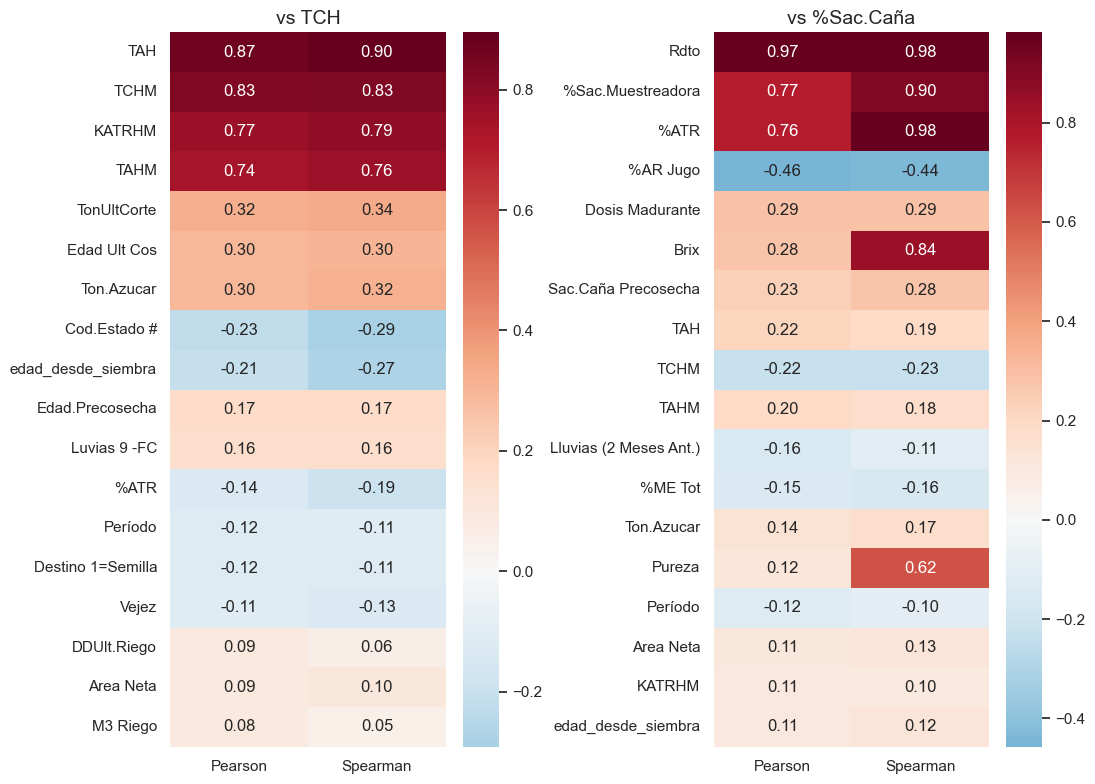

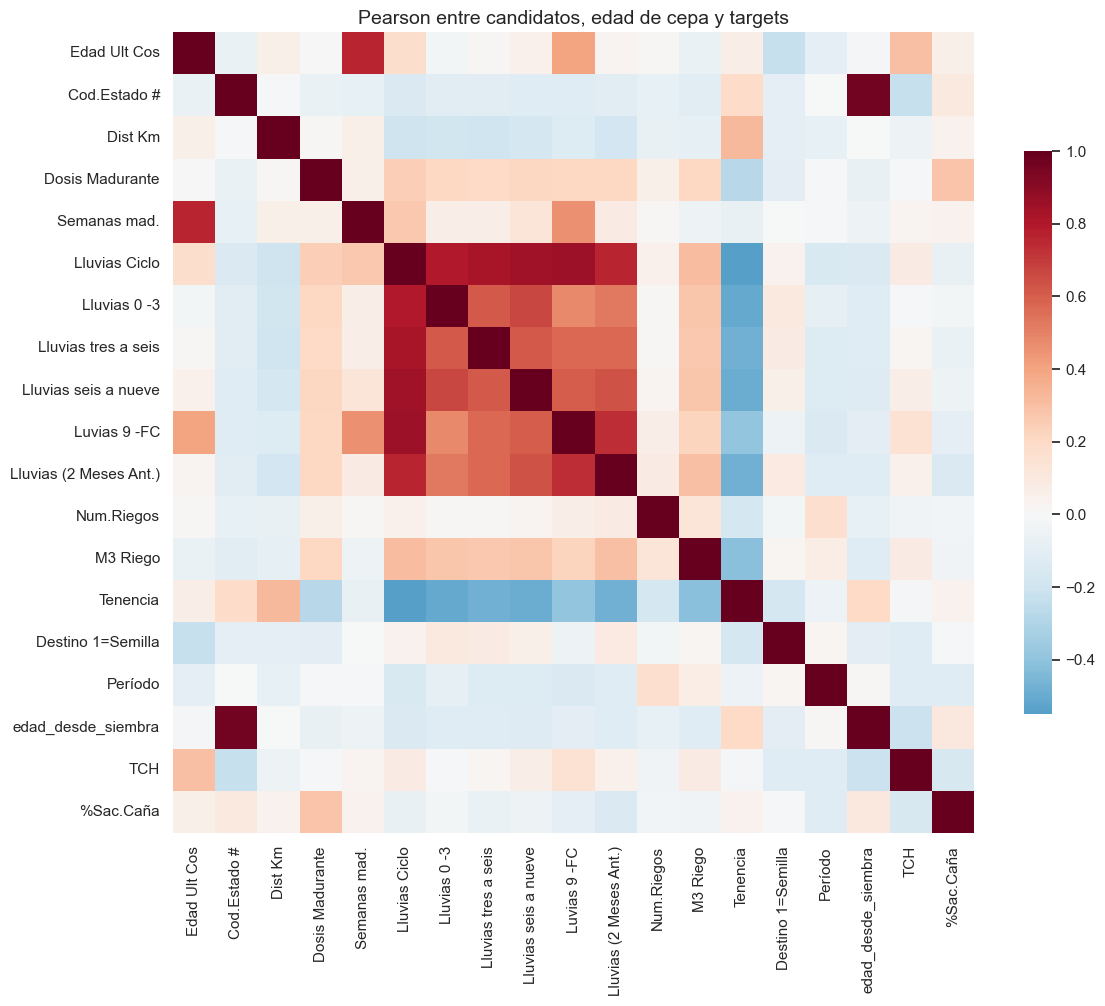

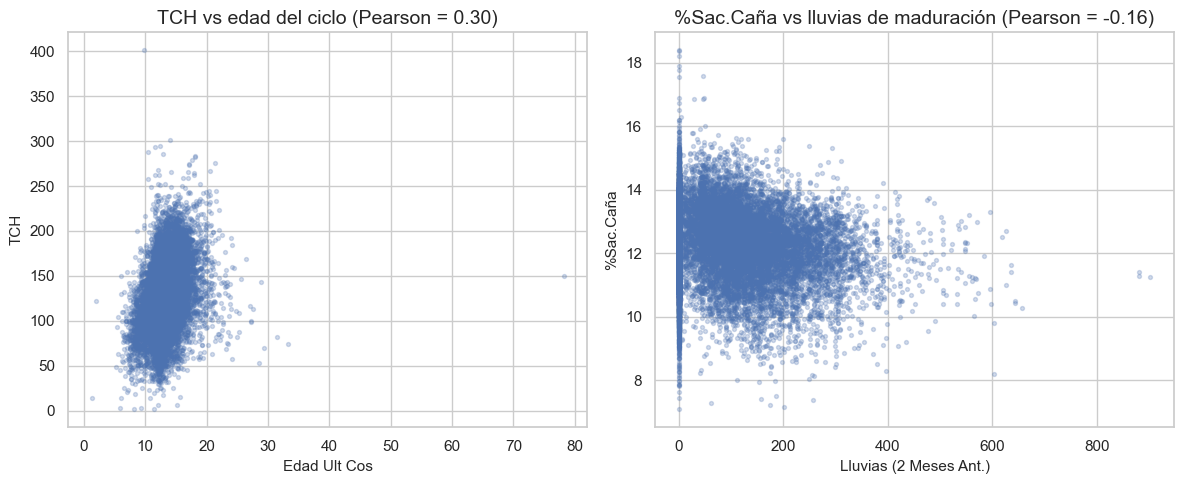

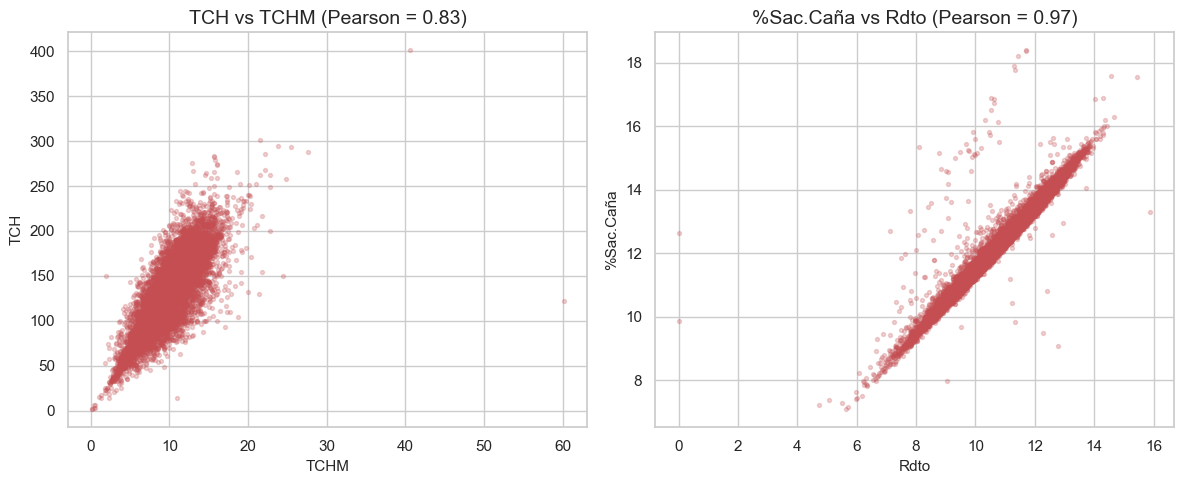


--- Trazabilidad | 10. Relaciones (fuga) ---
Motivo:            resultado / laboratorio de la misma cosecha
Columnas antes:    54
Columnas borradas: 17
Columnas quedan:   37
Borradas: ['TCHM', 'TAH', 'TAHM', 'KATRHM', 'TonUltCorte', 'Ton.Azucar', 'Rdto', '%Sac.Muestreadora', '%ATR', '%AR Jugo', 'Brix', 'Pureza', '%Fibra Caña', '%ME Min', '%ME Veg', '%ME Tot', 'Fosfato Jugo']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TCH', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC']


In [24]:
num_cols = [
    c for c in list(dict.fromkeys(cols_sin_ids + ["edad_desde_siembra"]))
    if c in df_suertes.columns
    and pd.api.types.is_numeric_dtype(df_suertes[c])
    and c not in ["TCH", "%Sac.Caña"]
]
X_num = df_suertes[num_cols]


def tabla_corr(y):
    """Pearson (lineal) y Spearman (rango) de cada numérica contra un target. Spearman aguanta relaciones monótonas no lineales."""
    t = pd.DataFrame({
        "Pearson": X_num.corrwith(y, method="pearson"),
        "Spearman": X_num.corrwith(y, method="spearman"),
    })
    t["|Pearson|"] = t["Pearson"].abs()
    return t.sort_values("|Pearson|", ascending=False).drop(columns="|Pearson|")


corr_tch = tabla_corr(df_suertes["TCH"])
corr_sac = tabla_corr(df_suertes["%Sac.Caña"])

print("Correlación con TCH (todas las numéricas del set de trabajo)")
display(corr_tch.round(3))
print("Correlación con %Sac.Caña")
display(corr_sac.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 8))
sns.heatmap(
    corr_tch.head(18)[["Pearson", "Spearman"]],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
)
axes[0].set_title("vs TCH")
sns.heatmap(
    corr_sac.head(18)[["Pearson", "Spearman"]],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
)
axes[1].set_title("vs %Sac.Caña")
plt.tight_layout()
plt.show()

# Matriz entre candidatos numéricos + targets (sin el bloque de toneladas/azúcar)
cols_matriz = [c for c in cols_candidatos if c in num_cols] + ["edad_desde_siembra", "TCH", "%Sac.Caña"]
cols_matriz = [c for c in cols_matriz if c in df_suertes.columns]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df_suertes[cols_matriz].corr(numeric_only=True),
    cmap="RdBu_r", center=0, square=True, ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Pearson entre candidatos, edad de cepa y targets")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_suertes["Edad Ult Cos"], df_suertes["TCH"], s=8, alpha=0.25, color="#4C72B0")
axes[0].set_xlabel("Edad Ult Cos")
axes[0].set_ylabel("TCH")
r_e = df_suertes["TCH"].corr(df_suertes["Edad Ult Cos"])
axes[0].set_title(f"TCH vs edad del ciclo (Pearson = {r_e:.2f})")

lluvia_mad = "Lluvias (2 Meses Ant.)"
axes[1].scatter(df_suertes[lluvia_mad], df_suertes["%Sac.Caña"], s=8, alpha=0.25, color="#4C72B0")
axes[1].set_xlabel(lluvia_mad)
axes[1].set_ylabel("%Sac.Caña")
r_l = df_suertes["%Sac.Caña"].corr(df_suertes[lluvia_mad])
axes[1].set_title(f"%Sac.Caña vs lluvias de maduración (Pearson = {r_l:.2f})")
plt.tight_layout()
plt.show()

# Contraste: columnas que "predicen" demasiado bien
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_suertes["TCHM"], df_suertes["TCH"], s=8, alpha=0.25, color="#C44E52")
axes[0].set_xlabel("TCHM")
axes[0].set_ylabel("TCH")
axes[0].set_title(f"TCH vs TCHM (Pearson = {df_suertes['TCH'].corr(df_suertes['TCHM']):.2f})")
axes[1].scatter(df_suertes["Rdto"], df_suertes["%Sac.Caña"], s=8, alpha=0.25, color="#C44E52")
axes[1].set_xlabel("Rdto")
axes[1].set_ylabel("%Sac.Caña")
axes[1].set_title(f"%Sac.Caña vs Rdto (Pearson = {df_suertes['%Sac.Caña'].corr(df_suertes['Rdto']):.2f})")
plt.tight_layout()
plt.show()

cols_fuera_fuga = [
    "TCHM", "TAH", "TAHM", "KATRHM", "TonUltCorte", "Ton.Azucar", "Rdto",
    "%Sac.Muestreadora", "%ATR", "%AR Jugo", "Brix", "Pureza",
    "%Fibra Caña", "%ME Min", "%ME Veg", "%ME Tot", "Fosfato Jugo",
]
cols_fuera_fuga = [c for c in cols_fuera_fuga if c in cols_sin_ids]
cols_sin_fuga = [c for c in cols_sin_ids if c not in cols_fuera_fuga]
registrar_recorte(
    "10. Relaciones (fuga)",
    "resultado / laboratorio de la misma cosecha",
    len(cols_sin_ids),
    cols_fuera_fuga,
    len(cols_sin_fuga),
)
print("Borradas:", cols_fuera_fuga)
print("Quedan:", cols_sin_fuga)


**Qué muestra este paso**

El ranking (Pearson + Spearman) ordena la evidencia **antes** de decidir.

**Fuga.** Lo más correlacionado con los targets no es clima ni variedad: es el **resultado de esa cosecha**. `Rdto` ≈ `%Sac.Caña` (Pearson ~0.97); `TCHM`/`TAH`/`KATRHM` van con TCH (~0.74–0.87). El scatter rojo es casi una recta: no hay nada que predecir. Laboratorio del mismo corte (`%ATR`, muestreadora, Brix, fibra, ME) mide la misma calidad. Salen de X.

**Predictores agronómicos.**

- **TCH vs `Edad Ult Cos`:** asociación positiva moderada (~0.30). Spearman similar: más edad de ciclo, más tonelaje, sin ser una recta perfecta (el scatter se dispersa; puede haber óptimo).
- **`%Sac.Caña` vs lluvias 2 meses antes:** correlación débil/negativa (~−0.16). Coherente con dilución en maduración; no es el efecto fuerte de `Rdto`.
- Entre candidatos, las lluvias por ventana se parecen entre sí (colinealidad → VIF). `edad_desde_siembra` se parece al n.º de corte, no a `Edad Ult Cos`.
- `Dosis Madurante` entra más en sacarosa que en TCH.

**Decisión.** `cols_sin_fuga` = set 2 menos toneladas, azúcar/ha, TCHM, Rdto y laboratorio de la misma cosecha. **Antes 54 → se borran 17 → quedan 37**. `Sac.Caña Precosecha` se deja: es una medición **antes** del corte, no el target.


In [25]:
# Relaciones no lineales: bins e información mutua para los candidatos con |Pearson| bajo.
# Un fundamento agronómico no se descarta solo por correlación lineal débil (Rec. 5).
predictores_candidatos = ["Dist Km", "Dosis Madurante", "Semanas mad.", "Num.Riegos", "M3 Riego",
          "Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC",
          "Lluvias (2 Meses Ant.)"]
predictores_candidatos = [c for c in predictores_candidatos if c in corr_tch.index]

# Base lineal de los mismos candidatos; bins e IM se leen contra esta tabla, no al revés.
print("--- 1. Pearson/Spearman de los candidatos (de la tabla completa) ---")
display(pd.DataFrame({"vs TCH": corr_tch.loc[predictores_candidatos, "Pearson"], "vs TCH (Spearman)": corr_tch.loc[predictores_candidatos, "Spearman"],
                       "vs %Sac.Caña": corr_sac.reindex(predictores_candidatos)["Pearson"],
                       "vs %Sac.Caña (Spearman)": corr_sac.reindex(predictores_candidatos)["Spearman"]}).round(3))

# |Pearson| bajo no descarta el predictor: el promedio por decil muestra curva, U o meseta.
print("\n--- 2. Promedio del target por bin (deciles), candidatos con |Pearson| < 0.15 vs algún target ---")
candidatos_correlacion_baja = [c for c in predictores_candidatos if abs(corr_tch.loc[c, "Pearson"]) < 0.15 or
          (c in corr_sac.index and abs(corr_sac.loc[c, "Pearson"]) < 0.15)]
for columna in candidatos_correlacion_baja:
    valores = df_suertes[columna]
    pct_cero = (valores == 0).mean()
    if pct_cero >= 0.05:
        # El cero se separa como grupo propio (no es "poco", es "ausencia"); deciles solo sobre valores > 0.
        valores_positivos = valores[valores > 0]
        bins_por_rango = pd.qcut(valores_positivos.rank(method="first"), 9, duplicates="drop")
        tabla_resumen = df_suertes.loc[valores_positivos.index].groupby(bins_por_rango, observed=True).agg(
            TCH_medio=("TCH", "mean"), Sac_medio=("%Sac.Caña", "mean"), n=(columna, "size"),
            rango=(columna, lambda s: f"{s.min():.2f}–{s.max():.2f}"))
        tabla_resumen = tabla_resumen.set_index("rango")
        fila_cero = df_suertes.loc[valores == 0].agg(TCH_medio=("TCH", "mean"), Sac_medio=("%Sac.Caña", "mean"))
        fila_cero = pd.DataFrame({"TCH_medio": [df_suertes.loc[valores == 0, "TCH"].mean()],
                                 "Sac_medio": [df_suertes.loc[valores == 0, "%Sac.Caña"].mean()],
                                 "n": [int((valores == 0).sum())]}, index=[f"= 0 ({100 * pct_cero:.1f} % de las filas)"])
        tabla_resumen = pd.concat([fila_cero, tabla_resumen])
    else:
        bins_por_rango = pd.qcut(valores.rank(method="first"), 10, duplicates="drop")
        tabla_resumen = df_suertes.groupby(bins_por_rango, observed=True).agg(
            TCH_medio=("TCH", "mean"), Sac_medio=("%Sac.Caña", "mean"), n=(columna, "size"),
            rango=(columna, lambda s: f"{s.min():.2f}–{s.max():.2f}"))
        tabla_resumen = tabla_resumen.set_index("rango")
    print(f"\n{columna} (rango observado: {valores.min():.2f} a {valores.max():.2f}; % en cero: {100 * pct_cero:.1f}):")
    display(tabla_resumen.round(2))

# IM no asume recta. NA de dosis = no aplicó; NA de riegos con m³ = 0 = cero riegos — no es la mediana del ingenio.
print("\n--- 3. Información mutua (no lineal; sin nulos, madurada/lluvias con su NA de negocio resuelto donde aplica) ---")
from sklearn.feature_selection import mutual_info_regression
base_mi = df_suertes[predictores_candidatos].copy()
for columna in ["Dosis Madurante"]:
    base_mi[columna] = base_mi[columna].fillna(0)
for columna in ["Num.Riegos"]:
    base_mi.loc[base_mi[columna].isna() & (df_suertes["M3 Riego"] == 0), columna] = 0
info_mutua = {}
for target, y_target in (("TCH", df_suertes["TCH"]), ("%Sac.Caña", df_suertes["%Sac.Caña"])):
    mask_sin_nulos = base_mi.notna().all(axis=1) & y_target.notna()
    info_mutua[target] = pd.Series(
        mutual_info_regression(base_mi.loc[mask_sin_nulos], y_target.loc[mask_sin_nulos], random_state=42),
        index=predictores_candidatos, name=target)
display(pd.DataFrame(info_mutua).round(4).sort_values("TCH", ascending=False))


--- 1. Pearson/Spearman de los candidatos (de la tabla completa) ---


,vs TCH,vs TCH (Spearman),vs %Sac.Caña,vs %Sac.Caña (Spearman)
Dist Km,-0.049,-0.009,0.048,0.074
Dosis Madurante,-0.015,-0.011,0.288,0.290
Semanas mad.,0.026,0.051,0.044,0.162
Num.Riegos,-0.036,0.072,-0.035,-0.065
M3 Riego,0.084,0.055,-0.036,-0.010
Lluvias 0 -3,-0.016,0.019,-0.026,-0.011
Lluvias tres a seis,0.021,0.050,-0.071,-0.045
Lluvias seis a nueve,0.064,0.083,-0.053,-0.035
Luvias 9 -FC,0.157,0.159,-0.091,-0.065
Lluvias (2 Meses Ant.),0.055,0.078,-0.156,-0.110



--- 2. Promedio del target por bin (deciles), candidatos con |Pearson| < 0.15 vs algún target ---

Dist Km (rango observado: 1.10 a 155.00; % en cero: 0.0):


,TCH_medio,Sac_medio,n
rango,,,
1.10–7.40,126.40,11.88,2103
7.40–10.40,122.05,12.26,2102
10.40–14.50,127.72,12.46,2102
14.50–18.90,136.79,12.23,2102
18.90–21.90,133.34,12.35,2102
21.90–27.00,136.11,12.42,2102
27.00–29.60,133.32,12.41,2102
29.60–34.70,135.87,12.47,2102
34.70–45.50,123.93,12.49,2102



Dosis Madurante (rango observado: 0.00 a 5.00; % en cero: 46.1):


...

,TCH_medio,Sac_medio,n
= 0 (45.9 % de las filas),125.20,12.35,9661
1.00–82.00,125.91,12.49,1263
82.00–130.00,129.08,12.61,1263
130.00–173.00,131.10,12.39,1263
173.00–220.00,131.70,12.36,1263
220.00–273.00,131.83,12.18,1262
273.00–346.00,132.95,12.24,1263
346.00–435.00,135.50,12.21,1263
435.00–583.00,139.75,12.16,1263
584.00–2752.00,142.38,12.02,1263



Lluvias (2 Meses Ant.) (rango observado: 0.00 a 902.00; % en cero: 47.9):


,TCH_medio,Sac_medio,n
= 0 (47.9 % de las filas),126.85,12.37,10064
1.00–46.00,131.98,12.78,1219
46.00–70.00,132.30,12.72,1218
70.00–93.00,132.83,12.47,1217
94.00–115.00,130.80,12.35,1219
115.00–140.00,133.34,12.27,1218
140.00–167.00,132.52,12.06,1217
167.00–205.00,131.14,12.05,1218
205.00–262.00,132.86,11.94,1219
262.00–902.00,131.52,11.82,1218



--- 3. Información mutua (no lineal; sin nulos, madurada/lluvias con su NA de negocio resuelto donde aplica) ---


,TCH,%Sac.Caña
Dist Km,0.0817,0.0331
Lluvias 0 -3,0.0220,0.0100
Dosis Madurante,0.0213,0.0091
Luvias 9 -FC,0.0207,0.0369
Semanas mad.,0.0128,0.0457
Lluvias tres a seis,0.0112,0.0071
Lluvias seis a nueve,0.0104,0.0061
M3 Riego,0.0089,0.0000
Lluvias (2 Meses Ant.),0.0086,0.0531
Num.Riegos,0.0069,0.0008


**Relaciones no lineales: bins e información mutua**

Pearson solo detecta relaciones en línea recta, así que para no perdernos ninguna curva escondida se complementa con dos chequeos más: el promedio del target por decil (dividir la variable en 10 tramos y ver si hay un patrón, sea recto o no) y la información mutua, que capta cualquier tipo de asociación sin importar su forma.

Como referencia de escala: `Dosis Madurante` contra `%Sac.Caña` tiene un Pearson de 0.288, y `Edad Ult Cos` contra TCH da 0.298 en la tabla completa — esos dos sirven de punto de comparación para todo lo que sigue. La información mutua, calculada sobre las filas sin nulos del bloque, da 0.0213 para `Dosis Madurante` contra TCH y 0.0091 contra sacarosa.

`Dist Km` es el hallazgo más interesante de esta parte: su Pearson es casi nulo (−0.049 con TCH, 0.048 con sacarosa), pero al mirarlo por decil aparece un patrón claro que la correlación lineal no puede ver — el TCH sube en los tramos medios de distancia (126 → 122 → 128 → 137) y vuelve a bajar en los extremos (136–133, cierra en 121). No es una recta, es más bien una curva, y por eso su información mutua (0.0817) resulta la más alta de toda la tabla, incluso por encima de la dosis de madurante. Queda marcada como candidata real a relación no lineal. Con sacarosa, en cambio, se mantiene prácticamente plana (11.88–12.49).

`Dosis Madurante` no tiene sorpresas: el Pearson ya venía capturando bien el salto (los deciles altos de dosis suben la sacarosa de ~11.6-12.0 hasta 12.70-12.75), así que su información mutua sale baja — no hay nada escondido que la correlación lineal no hubiera visto ya.

`Semanas mad.` sí muestra algo interesante para la calidad: aunque su Pearson es bajo (0.026 con TCH, 0.044 con sacarosa), la sacarosa por decil sube de 11.96 a 12.95 y luego cierra un poco más abajo (12.53) — un tramo de subida seguido de un cierre menor, y su información mutua (0.0457) también queda por encima de la dosis. Otra candidata real a relación no lineal, esta vez en calidad.

El resto de variables de riego y lluvia por ventana no muestran nada adicional que valga la pena rescatar. `Num.Riegos` tiene bins casi planos (TCH entre 129-135, sacarosa entre 12.41-12.08) y su información mutua es la más baja de todas (0.0069 y 0.0008). `M3 Riego` zigzaguea sin ninguna curva legible (136, 123, 145, 118, 137), y las tres ventanas de lluvia más tempranas (0-3, 3-6, 6-9 meses) tampoco muestran una tendencia estable, con toda su información mutua cerca o por debajo de la dosis de referencia.

Dos excepciones sí valen la pena. `Lluvias 9-FC` (la ventana justo antes de la cosecha) tiene el Pearson más alto de todo el grupo contra TCH (0.157), y los dos últimos deciles de TCH (135.91 y 141.57) confirman esa misma dirección — aquí Pearson ya venía captando bien la señal. Y `Lluvias (2 Meses Ant.)` tiene una correlación negativa clara con sacarosa (−0.156), que se ve consistente en los deciles finales (12.23 → 12.04 → 11.86) y con la información mutua más alta de toda la tabla contra sacarosa (0.0531) — coherente con el efecto de dilución que ya conocemos, sin necesitar una curva más compleja para explicarlo.

Antes de aceptar estos hallazgos hay que descartar una explicación alternativa: que la correlación salga baja simplemente porque el rango de la variable es demasiado angosto para que el efecto se manifieste. No es el caso aquí. `Dist Km` va de 5.3 a 64.9 km entre los percentiles 5 y 95 (hasta 155 km de máximo), y ya sabemos que las distancias suben de forma ordenada desde El Cerrito (10.1 km) hasta Andalucía (86.2 km) — decenas de kilómetros de dispersión real, no un rango restringido. `Num.Riegos` tampoco: va de una mediana de 5 hasta un máximo de 278, un rango amplio donde lo que aplana la correlación es la mezcla de distintos sistemas de riego, no la falta de variación. Y las ventanas de lluvia se reparten el ciclo de forma pareja (cada una con una fracción mediana de entre 0.22 y 0.27 del total) y van de 0 a más de 1.000 mm cada una — el problema ahí son los ceros que en realidad son datos faltantes, no un rango corto.

**La decisión final:** si el modelo lineal se ampliara únicamente por esta evidencia, entrarían `Dist Km` (por su información mutua alta y el TCH más alto en los deciles medios) y, para sacarosa, `Semanas mad.` y `Lluvias (2 Meses Ant.)`. Quedarían fuera `Num.Riegos`, `M3 Riego` y las ventanas de lluvia 0-3, 3-6 y 6-9, que no muestran ningún fundamento adicional en estos gráficos que justifique forzarlas. En la práctica, las diez ya estaban incluidas en el modelo desde antes, por el criterio agronómico de la Tarea 1 — así que este chequeo no cambia nada, solo confirma que ya estaba bien incluirlas.

In [26]:
# Interacción lluvia × variedad: ¿el efecto de la lluvia temprana sobre TCH cambia según la variedad?
# Lluvias 0 -3 tiene el |Spearman| más alto vs TCH entre las ventanas (paso 10).
conteo_variedades = df_suertes["Variedad"].value_counts()
variedades_candidatas = conteo_variedades[conteo_variedades >= 500].index.tolist()
print("Variedades con n ≥ 500:", variedades_candidatas)

filas_resultado = []
for variedad_actual in variedades_candidatas:
    subset_variedad = df_suertes.loc[(df_suertes["Variedad"] == variedad_actual) & (df_suertes["Lluvias 0 -3"] > 0)]
    pearson_variedad = subset_variedad["Lluvias 0 -3"].corr(subset_variedad["TCH"], method="pearson")
    spearman_variedad = subset_variedad["Lluvias 0 -3"].corr(subset_variedad["TCH"], method="spearman")
    filas_resultado.append({"Variedad": variedad_actual, "n": len(subset_variedad), "Pearson": pearson_variedad, "Spearman": spearman_variedad})
tabla_interaccion = pd.DataFrame(filas_resultado).set_index("Variedad")
print("\nCorrelación Lluvias 0-3 vs TCH, por variedad (solo lluvia registrada):")
display(tabla_interaccion.round(3))

pearson_global = df_suertes.loc[df_suertes["Lluvias 0 -3"] > 0, "Lluvias 0 -3"].corr(
    df_suertes.loc[df_suertes["Lluvias 0 -3"] > 0, "TCH"])
print("Correlación global (todas las variedades juntas):", round(pearson_global, 3))
print("Rango de Pearson por variedad:", round(tabla_interaccion["Pearson"].min(), 3), "a", round(tabla_interaccion["Pearson"].max(), 3))

# Chequeo formal: término de interacción en un OLS auxiliar (solo diagnóstico, no reemplaza el set de X).
import statsmodels.formula.api as smf
datos_interaccion = df_suertes.loc[df_suertes["Variedad"].isin(variedades_candidatas) & (df_suertes["Lluvias 0 -3"] > 0),
                          ["TCH", "Lluvias 0 -3", "Variedad"]].copy()
datos_interaccion.columns = ["TCH", "Lluvias_0_3", "Variedad"]
modelo_interaccion = smf.ols("TCH ~ Lluvias_0_3 * C(Variedad)", data=datos_interaccion).fit()
terminos_interaccion = [t for t in modelo_interaccion.pvalues.index if ":" in t]
print("\nTérminos de interacción (Lluvias_0_3 × Variedad) y su p-valor:")
display(modelo_interaccion.pvalues[terminos_interaccion].round(4).to_frame("p"))
print("¿Alguna interacción p < 0.05?", bool((modelo_interaccion.pvalues[terminos_interaccion] < 0.05).any()))


Variedades con n ≥ 500: ['CC01-1940', 'CC85-92', 'CC05-430', 'CC93-4418', 'RB73-2223']

Correlación Lluvias 0-3 vs TCH, por variedad (solo lluvia registrada):


,n,Pearson,Spearman
Variedad,,,
CC01-1940,5140,-0.128,-0.144
CC85-92,1661,-0.127,-0.134
CC05-430,1537,-0.262,-0.250
CC93-4418,625,-0.069,-0.107
RB73-2223,546,0.033,0.006


Correlación global (todas las variedades juntas): -0.144
Rango de Pearson por variedad: -0.262 a 0.033

Términos de interacción (Lluvias_0_3 × Variedad) y su p-valor:


,p
Lluvias_0_3:C(Variedad)[T.CC05-430],0.0000
Lluvias_0_3:C(Variedad)[T.CC85-92],0.2338
Lluvias_0_3:C(Variedad)[T.CC93-4418],0.0652
Lluvias_0_3:C(Variedad)[T.RB73-2223],0.0000


¿Alguna interacción p < 0.05? True


**Interacción lluvia × variedad sobre TCH**

Se prueba si el efecto de la lluvia temprana (`Lluvias 0 -3`) sobre TCH cambia según la variedad, en vez de un solo efecto promedio. Entran las cinco variedades con n ≥ 500 (`CC01-1940`, `CC85-92`, `CC05-430`, `CC93-4418`, `RB73-2223`) y solo filas con lluvia registrada.

La correlación global es **−0.144**. Por variedad el Pearson va de **−0.262** (`CC05-430`, n = 1.537) a **+0.033** (`RB73-2223`, n = 546): cambia de signo. `CC01-1940` (−0.128) y `CC85-92` (−0.127) se parecen al promedio; `CC93-4418` es más débil (−0.069). Spearman cuenta la misma historia (−0.250 a +0.006).

El OLS auxiliar `TCH ~ Lluvias_0_3 * C(Variedad)` (referencia `CC01-1940`) marca **2 de 4** términos de interacción con p < 0.05: `Lluvias_0_3 × CC05-430` (p = 0.0000) y `Lluvias_0_3 × RB73-2223` (p = 0.0000). `CC85-92` no es significativo (p = 0.2338); `CC93-4418` queda en el borde (p = 0.0652).

**Decisión.** Hay evidencia de interacción: el efecto de la lluvia temprana sobre TCH no es el mismo en todas las variedades (signo distinto y dos términos formales significativos). Un término `Lluvias 0 -3 × Variedad` queda como extensión para el lineal del paso 18 en 02; no se agrega en este paso. El supuesto de un único coeficiente de lluvia para todas las variedades queda en duda.


In [27]:
# Lluvia por ventanas del ciclo (0–3, 3–6, 6–9 y 9 meses–cosecha; el ciclo es su suma) frente a cada target.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura; usa las filas con lluvia registrada (Lluvias Ciclo > 0; los ceros son faltante, paso 9).
ventanas_lluvia = {"0–3 meses": "Lluvias 0 -3", "3–6 meses": "Lluvias tres a seis", "6–9 meses": "Lluvias seis a nueve",
          "9 meses–cosecha": "Luvias 9 -FC", "2 meses antes": "Lluvias (2 Meses Ant.)", "ciclo": "Lluvias Ciclo"}
mask_lluvia_registrada = df_suertes["Lluvias Ciclo"] > 0
mask_tch_valido = ~((df_suertes["TCH"] < 60) & (df_suertes["Destino 1=Semilla"] == 0))   # sin los lotes de excluir_tch (paso 9)

print("--- 1. Perfil (filas con lluvia registrada: n =", int(mask_lluvia_registrada.sum()), ") ---")
display(df_suertes.loc[mask_lluvia_registrada, list(ventanas_lluvia.values())].rename(columns={v: k for k, v in ventanas_lluvia.items()})
        .describe(percentiles=[0.05, 0.5, 0.95]).T[["mean", "5%", "50%", "95%", "max"]].round(1))
fraccion_ciclo_por_ventana = (df_suertes.loc[mask_lluvia_registrada, ["Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC"]]
          .div(df_suertes.loc[mask_lluvia_registrada, "Lluvias Ciclo"], axis=0).median())
print("Fracción mediana del ciclo por ventana:", fraccion_ciclo_por_ventana.round(2).to_dict())

print("\n--- 2. Correlación con cada target (Pearson / Spearman) ---")
filas_resultado = []
for nombre_ventana, col_ventana in ventanas_lluvia.items():
    fila_resultado = {"ventana": nombre_ventana}
    for target, mask_target in (("TCH", mask_lluvia_registrada & mask_tch_valido), ("%Sac.Caña", mask_lluvia_registrada & df_suertes["%Sac.Caña"].notna())):
        x_ventana, y_target = df_suertes.loc[mask_target, col_ventana], df_suertes.loc[mask_target, target]
        fila_resultado[f"{target} Pearson"] = x_ventana.corr(y_target)
        fila_resultado[f"{target} Spearman"] = x_ventana.corr(y_target, method="spearman")
    filas_resultado.append(fila_resultado)
display(pd.DataFrame(filas_resultado).set_index("ventana").round(3))


--- 1. Perfil (filas con lluvia registrada: n = 13288 ) ---


,mean,5%,50%,95%,max
0–3 meses,193.6,0.0,182.0,434.0,1028.0
3–6 meses,190.2,0.0,177.0,443.0,1050.0
6–9 meses,186.9,0.0,174.0,429.0,1075.0
9 meses–cosecha,262.1,0.0,207.0,729.0,2752.0
2 meses antes,118.9,0.0,105.0,301.0,902.0
ciclo,832.6,96.0,810.0,1649.0,3917.0


Fracción mediana del ciclo por ventana: {'Lluvias 0 -3': 0.23, 'Lluvias tres a seis': 0.22, 'Lluvias seis a nueve': 0.22, 'Luvias 9 -FC': 0.27}

--- 2. Correlación con cada target (Pearson / Spearman) ---


,TCH Pearson,TCH Spearman,%Sac.Caña Pearson,%Sac.Caña Spearman
ventana,,,,
0–3 meses,-0.143,-0.149,-0.034,-0.009
3–6 meses,-0.081,-0.081,-0.107,-0.086
6–9 meses,-0.012,-0.011,-0.078,-0.060
9 meses–cosecha,0.150,0.146,-0.129,-0.132
2 meses antes,-0.017,-0.012,-0.234,-0.229
ciclo,0.009,-0.003,-0.130,-0.114


**Lluvia por ventanas del ciclo**

`Lluvias Ciclo` es la suma de cuatro ventanas (0–3, 3–6, 6–9 y 9 meses–cosecha). `Lluvias (2 Meses Ant.)` solapa con la última. Con lluvia registrada (`Lluvias Ciclo` > 0; n = **13.288**; los ceros son faltante, paso 9), las cuatro se parten el ciclo de forma parecida (fracción mediana **0.23 / 0.22 / 0.22 / 0.27**); la de 9–cosecha lleva un poco más (mediana **207** mm frente a **174–182** en las anteriores) y una cola más pesada (p95 **729**, máx. **2.752**). El ciclo queda en mediana **810** mm. Los 2 meses antes (mediana **105** mm) caben dentro de esa última ventana.

**Sector.** El efecto fisiológico de la lluvia depende de la fase del ciclo (crecimiento temprano frente a maduración), no solo del total anual; el paso 10 ya lo anticipa para sacarosa ("dilución en maduración").

**Resultado.** Para TCH, el |Spearman| mayor es **0–3 meses (−0.149)**; el ciclo queda en **−0.003**, por debajo de esa ventana. 9–cosecha queda cerca con signo opuesto (**+0.146**): el total cerca de cero no respalda un efecto de “más agua, más tonelaje”; oculta dos asociaciones débiles de signo contrario. Para `%Sac.Caña`, el |Spearman| mayor es **2 meses antes (−0.229)**; el ciclo (**−0.114**) queda por debajo de esa ventana y de 9–cosecha (**−0.132**). 0–3 meses queda en **−0.009**. Eso sí respalda la dilución en maduración: la asociación negativa se concentra al final del ciclo, no al inicio.

**Decisión.** Las ventanas reemplazan al total en las X si su VIF conjunto (sin `Lluvias Ciclo`) es menor que 5. En el paso 12 ese VIF queda por debajo de 5: las ventanas sustituyen a `Lluvias Ciclo` en las X.


## 11. Relaciones de categorías con los targets

Tras sacar las fugas, se mira si zona, corte, quema, variedad y cultivo —factores agronómicos del rendimiento— se asocian con TCH y `%Sac.Caña`. Boxplots por grupo; las colas extremas ya se vieron en el univariado, aquí importa el desplazamiento de la caja.


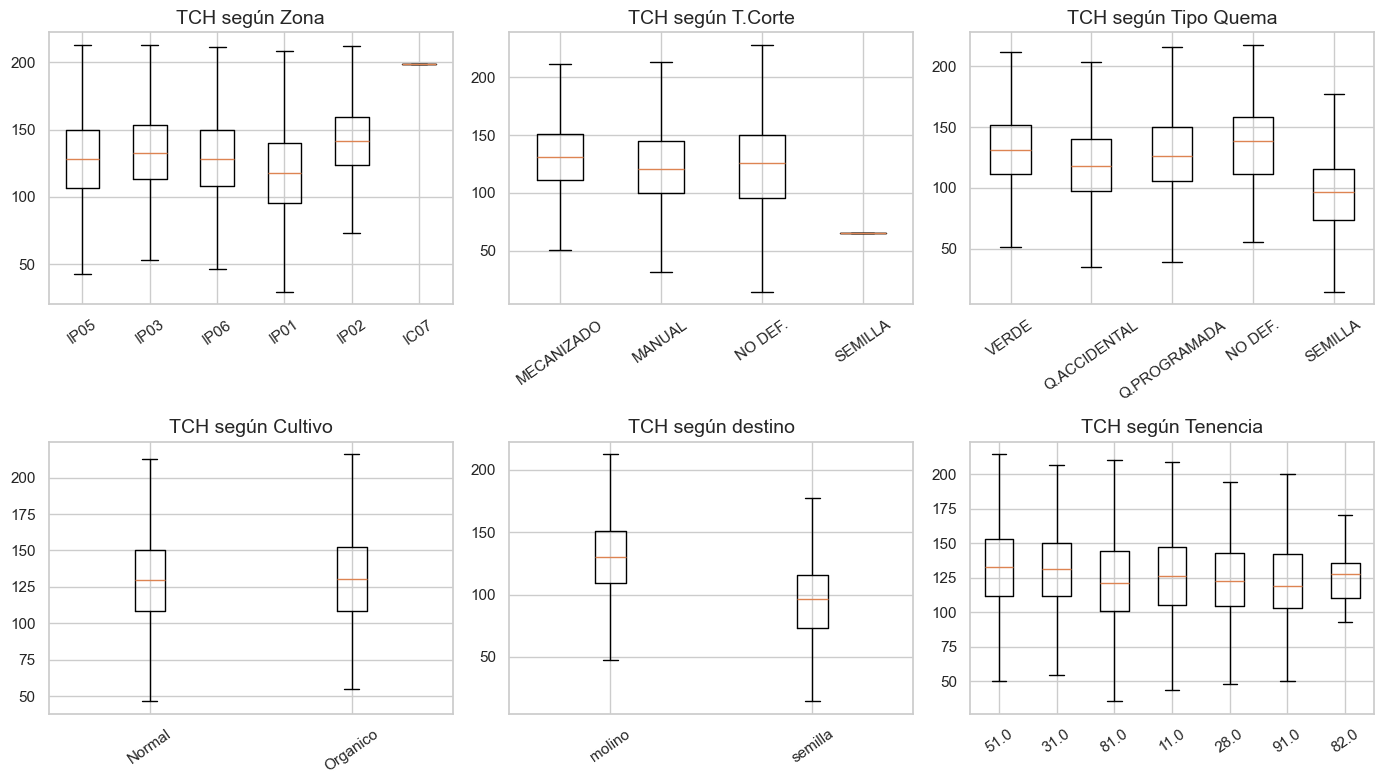

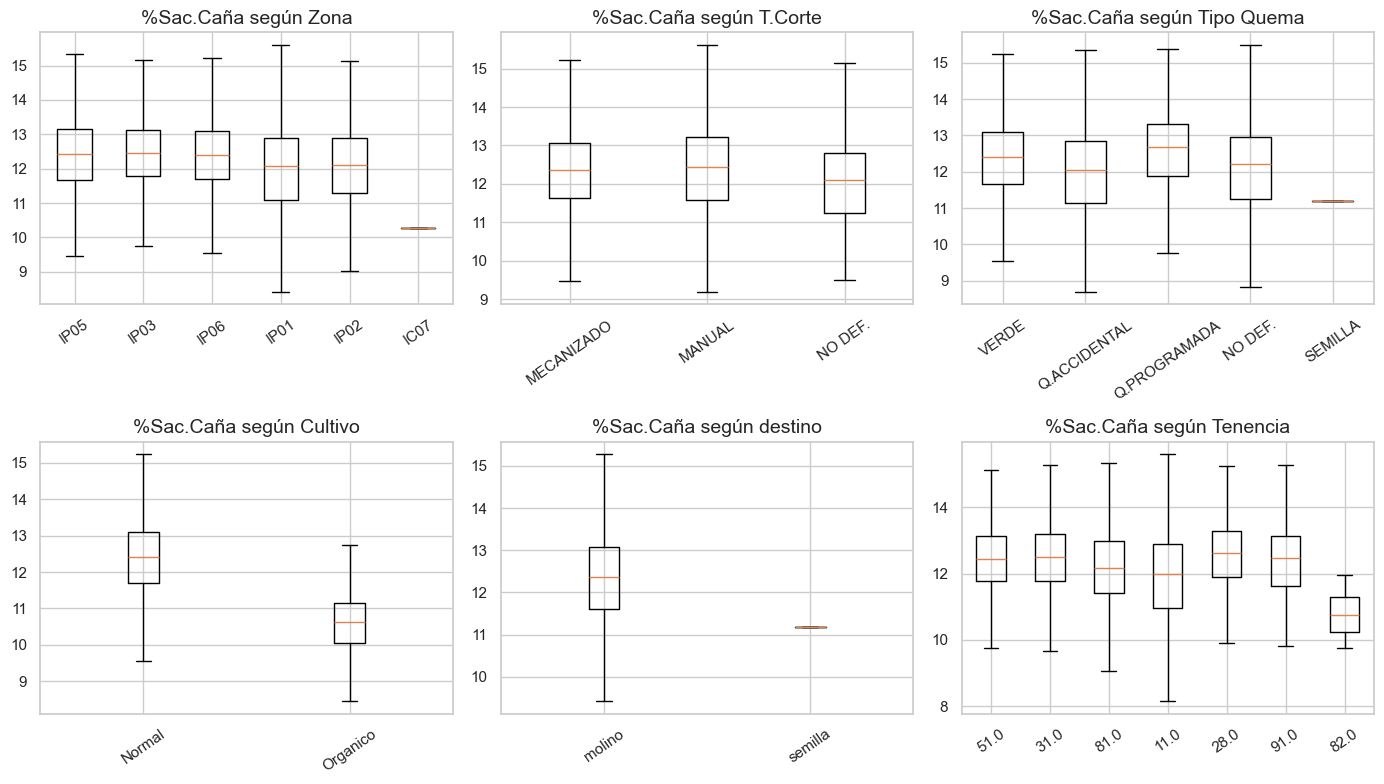

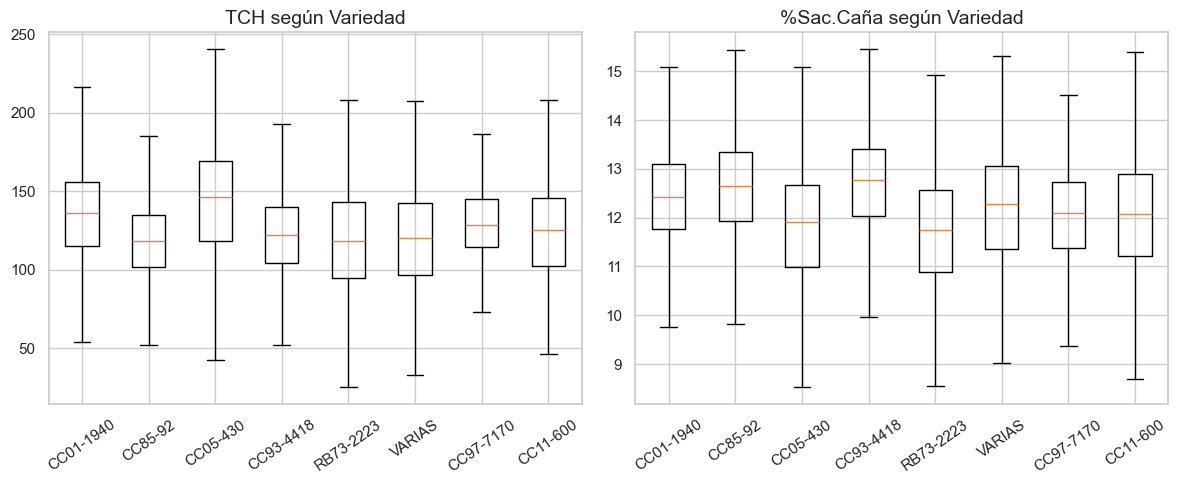

Medias por grupo


,TCH,%Sac.Caña
Zona,,
IC07,199.04,10.28
IP01,117.83,11.98
IP02,142.76,12.06
IP03,133.64,12.42
IP05,128.27,12.38
IP06,128.58,12.37


,TCH,%Sac.Caña
T.Corte,,
MANUAL,123.61,12.38
MECANIZADO,131.00,12.31
NO DEF.,123.01,12.06
SEMILLA,65.04,NaN


,TCH,%Sac.Caña
Tipo Quema,,
NO DEF.,135.80,12.11
Q.ACCIDENTAL,119.39,11.95
Q.PROGRAMADA,129.31,12.59
SEMILLA,96.62,11.19
VERDE,131.59,12.36


,TCH,%Sac.Caña
Cultivo,,
Normal,129.58,12.38
Organico,130.21,10.58
NaN,145.67,12.16


,TCH,%Sac.Caña
Destino 1=Semilla,,
0,130.08,12.32
1,96.62,11.19


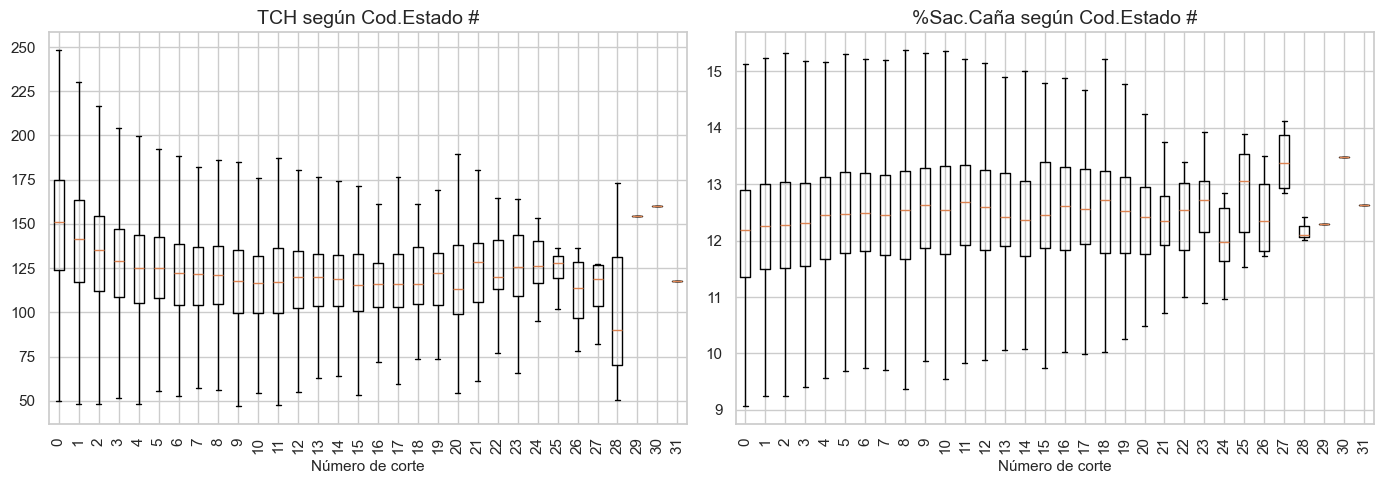

Medias por número de corte:


TCH       %Sac.Caña      
               mean count      mean count
Cod.Estado #                             
0             148.3  2677      12.1  2530
1             139.2  2823      12.2  2721
2             132.8  2925      12.2  2851
3             127.9  2820      12.3  2779
4             124.1  2378      12.4  2361
5             123.7  1791      12.5  1771
6             120.7  1337      12.5  1322
7             120.0  1006      12.4   996
8             120.7   692      12.5   685
9             116.6   560      12.6   559
10            114.9   375      12.5   373
11            117.0   265      12.6   263
12            119.5   229      12.5   226
13            118.1   208      12.5   207
14            117.7   196      12.5   194
15            116.9   149      12.5   148
16            119.5   126      12.5   126
17            119.2   105      12.6   105
18            120.6    94      12.6    93
19            119.8    70      12.4    70
20            116.5    57      12.4    55
21            125.2    39      12.4    38
22            123.5    31      12.4    31
23            123.8    28      12.6    28
24            125.5    19      12.0    19
25            125.8    11      12.8    11
26            111.0     6      12.5     6
27            111.7     4      13.4     4
28            104.6     3      12.2     3
29            154.4     1      12.3     1
30            160.0     1      13.5     1
31            117.9     1      12.6     1

In [28]:
def box_por(df, cat, y, ax, orden=None):
    """Boxplot de `y` por nivel de `cat`. `showfliers=False` para leer el cuerpo, no la cola. `orden` fija el eje (p. ej. número de corte)."""
    datos = df[[cat, y]].dropna()
    if orden is None:
        orden = [c for c in datos[cat].value_counts().index if pd.notna(c)]
    grupos = [datos.loc[datos[cat] == n, y].values for n in orden]
    ax.boxplot(grupos, vert=True, tick_labels=[str(n) for n in orden], showfliers=False)
    ax.set_title(f"{y} según {cat}")
    ax.tick_params(axis="x", rotation=35)


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_por(df_suertes, "Zona", "TCH", axes[0, 0])
box_por(df_suertes, "T.Corte", "TCH", axes[0, 1])
box_por(df_suertes, "Tipo Quema", "TCH", axes[0, 2])
box_por(df_suertes, "Cultivo", "TCH", axes[1, 0])
df_tmp = df_suertes.copy()
df_tmp["destino"] = df_tmp["Destino 1=Semilla"].map({0: "molino", 1: "semilla"})
box_por(df_tmp, "destino", "TCH", axes[1, 1])
box_por(df_suertes, "Tenencia", "TCH", axes[1, 2])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_por(df_suertes, "Zona", "%Sac.Caña", axes[0, 0])
box_por(df_suertes, "T.Corte", "%Sac.Caña", axes[0, 1])
box_por(df_suertes, "Tipo Quema", "%Sac.Caña", axes[0, 2])
box_por(df_suertes, "Cultivo", "%Sac.Caña", axes[1, 0])
box_por(df_tmp, "destino", "%Sac.Caña", axes[1, 1])
box_por(df_suertes, "Tenencia", "%Sac.Caña", axes[1, 2])
plt.tight_layout()
plt.show()

top_var = df_suertes["Variedad"].value_counts().head(8).index
df_var = df_suertes[df_suertes["Variedad"].isin(top_var)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
box_por(df_var, "Variedad", "TCH", axes[0])
box_por(df_var, "Variedad", "%Sac.Caña", axes[1])
plt.tight_layout()
plt.show()

print("Medias por grupo")
for cat in ["Zona", "T.Corte", "Tipo Quema", "Cultivo", "Destino 1=Semilla"]:
    display(df_suertes.groupby(cat, dropna=False)[["TCH", "%Sac.Caña"]].mean().round(2))

# Número de corte (soca), aislado: el efecto suele ser no lineal
orden_corte = sorted(df_suertes["Cod.Estado #"].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
box_por(df_suertes, "Cod.Estado #", "TCH", axes[0], orden=orden_corte)
box_por(df_suertes, "Cod.Estado #", "%Sac.Caña", axes[1], orden=orden_corte)
axes[0].tick_params(axis="x", rotation=90)
axes[1].tick_params(axis="x", rotation=90)
axes[0].set_xlabel("Número de corte")
axes[1].set_xlabel("Número de corte")
plt.tight_layout()
plt.show()

print("Medias por número de corte:")
display(
    df_suertes.groupby("Cod.Estado #")[["TCH", "%Sac.Caña"]]
    .agg(["mean", "count"])
    .round(1)
)

**Qué muestra este paso**

Las categorías agronómicas **sí se mueven** con los targets, no solo las numéricas.

- **Zona:** IP02 tiene más TCH (~143); IP01 menos (~118). Sacarosa más parecida entre zonas (salvo `IC07`, 1 fila).
- **Corte / destino:** mecanizado rinde más que manual. Semilla baja el TCH (~97 vs ~130) y la sacarosa; confirma el paso 7.
- **Quema:** accidental baja TCH y sacarosa frente a verde o programada.
- **Cultivo:** TCH casi igual; **orgánico baja sacarosa** (~10.6 vs ~12.4). Relevante para Providencia (prácticas de sostenibilidad).
- **Variedad (top 8):** CC05-430 y CC01-1940 tiran TCH hacia arriba; CC85-92 y CC93-4418, más sacarosa. No es un solo ranking para los dos objetivos.
- **Número de corte (`Cod.Estado #`):** la plantilla (0) rinde ~148 t/ha; el TCH baja de forma sostenida hasta el corte 9–10 (~115) y después se aplana (los cortes ≥20 son pocos). No es el “sube y luego cae” de los textos agronómicos: aquí la soca pierde desde el primer corte. La sacarosa casi no se mueve (~12.1 → ~12.5). Entra al lineal como tendencia; el tramo no lineal se anota como limitación.

**Decisión.** Se mantienen `Zona`, `T.Corte`, `Tipo Quema`, `Cultivo`, `Destino 1=Semilla`, `Tenencia` y `Variedad` (esta, agrupando cola). `Tenencia` son códigos (11, 28, 31, …), no una escala: va a categóricas, no al VIF numérico. `IC07` y `T.Corte = SEMILLA` (1 fila) se funden en **OTRAS**. Siguiente: VIF sobre los predictores numéricos ya elegidos.


## 12. Multicolinealidad (VIF)

Se calcula el Factor de Inflación de la Varianza sobre las variables **ya seleccionadas** para el lineal. Umbral de alerta: VIF > 5 (grave si > 10). Se compara el bloque de lluvias (ciclo vs ventanas), las dos edades (ciclo vs cepa / n.º de corte) y el resto de numéricas que entran al set final (`Num.Riegos`, `Semanas mad.`, `madurada`). **`Tenencia` no entra aquí:** son códigos de categoría (11, 28, 31, …), no una escala continua; va con las dummy. Las categóricas (zona, suelo, variedad) se miran con Cramér’s V en el cierre, no con VIF: todavía no hay matriz de diseño.


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def tabla_vif(df, cols):
    """VIF de un bloque numérico (dropna + constante). Convención: alerta si VIF>5, grave si VIF>10. No aplica a dummies."""
    X = df[cols].dropna()
    Xc = sm.add_constant(X, has_constant="add")
    filas = []
    for i, nombre in enumerate(Xc.columns):
        if nombre == "const":
            continue
        filas.append({
            "variable": nombre,
            "VIF": variance_inflation_factor(Xc.values, i),
        })
    out = pd.DataFrame(filas).sort_values("VIF", ascending=False)
    out.attrs["n"] = len(X)
    return out


lluvias_todas = [
    "Lluvias Ciclo", "Lluvias 0 -3", "Lluvias tres a seis",
    "Lluvias seis a nueve", "Luvias 9 -FC", "Lluvias (2 Meses Ant.)",
]
print("A) Las 6 lluvias juntas (n =", df_suertes[lluvias_todas].dropna().shape[0], ")")
display(tabla_vif(df_suertes, lluvias_todas).round(2))

print("B) Solo ciclo + lluvias 2 meses antes")
display(tabla_vif(df_suertes, ["Lluvias Ciclo", "Lluvias (2 Meses Ant.)"]).round(2))

print("B2) Ventanas + lluvias 2 meses antes (sin Lluvias Ciclo), filas con lluvia registrada")
display(tabla_vif(df_suertes.loc[df_suertes["Lluvias Ciclo"] > 0],
                  ["Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC",
                   "Lluvias (2 Meses Ant.)"]).round(2))

# Tenencia es categórica: fuera de este bloque.
# Semanas mad. / Num.Riegos / madurada tienen NA informativos. Un dropna crudo
# deja ~5.5 mil filas y madurada constante (el NA de semanas ≈ no maduró).
# Misma regla corta del paso 13, sobre una copia, para evaluar el set que sí entra.
df_vif = df_suertes.copy()
df_vif["madurada"] = (
    (df_vif["Dosis Madurante"].fillna(0) > 0) | df_vif["Producto"].notna()
).astype(int)
df_vif["Dosis Madurante"] = df_vif["Dosis Madurante"].fillna(0)
df_vif.loc[df_vif["Semanas mad."] < 0, "Semanas mad."] = np.nan
df_vif.loc[df_vif["madurada"] == 0, "Semanas mad."] = (
    df_vif.loc[df_vif["madurada"] == 0, "Semanas mad."].fillna(0)
)
med_semanas_vif = df_vif.loc[df_vif["madurada"] == 1, "Semanas mad."].median()
df_vif["Semanas mad."] = df_vif["Semanas mad."].fillna(med_semanas_vif)
df_vif.loc[df_vif["Num.Riegos"].isna() & (df_vif["M3 Riego"] == 0), "Num.Riegos"] = 0
med_riegos_vif = df_vif.loc[df_vif["M3 Riego"] > 0, "Num.Riegos"].median()
df_vif["Num.Riegos"] = df_vif["Num.Riegos"].fillna(med_riegos_vif)
df_vif["Dist Km"] = df_vif["Dist Km"].fillna(df_vif["Dist Km"].median())

cols_vif_edades = [
    "Edad Ult Cos", "Cod.Estado #", "edad_desde_siembra",
    "Dist Km", "Dosis Madurante", "Semanas mad.", "madurada",
    "Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos", "M3 Riego", "Destino 1=Semilla", "Período",
]
print("C) Set numérico del lineal, con ambas edades (n =", df_vif[cols_vif_edades].dropna().shape[0], ")")
print("Tenencia no entra (códigos de categoría).")
vif_c = tabla_vif(df_vif, cols_vif_edades)
display(vif_c.round(2))

cols_vif_final = [c for c in cols_vif_edades if c != "edad_desde_siembra"]
print("D) Mismo set sin edad_desde_siembra")
display(tabla_vif(df_vif, cols_vif_final).round(2))
print(
    "corr Dosis Madurante vs madurada:",
    round(df_vif["Dosis Madurante"].corr(df_vif["madurada"]), 3),
    "| Num.Riegos vs M3 Riego:",
    round(df_vif["Num.Riegos"].corr(df_vif["M3 Riego"]), 3),
)

s_ventanas = (
    df_suertes["Lluvias 0 -3"]
    + df_suertes["Lluvias tres a seis"]
    + df_suertes["Lluvias seis a nueve"]
    + df_suertes["Luvias 9 -FC"]
)
print(
    "Correlación Lluvias Ciclo vs suma de ventanas 0–cosecha:",
    round(df_suertes["Lluvias Ciclo"].corr(s_ventanas), 6),
)
print(
    "Correlación n.º de corte vs edad_desde_siembra:",
    round(df_suertes["Cod.Estado #"].corr(df_suertes["edad_desde_siembra"]), 3),
)

cols_fuera_vif = [
    "Lluvias Ciclo",
]
# edad_desde_siembra no está en cols_sin_fuga (es derivada)
cols_modelo = [
    c for c in (cols_sin_fuga if "cols_sin_fuga" in dir() else cols_sin_ids)
    if c not in cols_fuera_vif
]
registrar_recorte(
    "12. VIF",
    "el ciclo es la suma de las ventanas (se conservan las ventanas)",
    len(cols_sin_fuga),
    cols_fuera_vif,
    len(cols_modelo),
)
print("Borradas:", cols_fuera_vif)
print("Quedan:", cols_modelo)
print("Se deja fuera del lineal edad_desde_siembra (redundante con Cod.Estado #).")


A) Las 6 lluvias juntas (n = 21027 )


,variable,VIF
0,Lluvias Ciclo,266558.15
4,Luvias 9 -FC,47670.57
1,Lluvias 0 -3,18446.63
2,Lluvias tres a seis,18186.93
3,Lluvias seis a nueve,17456.51
5,Lluvias (2 Meses Ant.),2.59


B) Solo ciclo + lluvias 2 meses antes


,variable,VIF
0,Lluvias Ciclo,2.39
1,Lluvias (2 Meses Ant.),2.39


B2) Ventanas + lluvias 2 meses antes (sin Lluvias Ciclo), filas con lluvia registrada


...

C) Set numérico del lineal, con ambas edades (n = 21027 )
Tenencia no entra (códigos de categoría).


,variable,VIF
1,Cod.Estado #,13.93
2,edad_desde_siembra,13.89
6,madurada,8.55
4,Dosis Madurante,7.16
10,Luvias 9 -FC,4.12
5,Semanas mad.,3.31
11,Lluvias (2 Meses Ant.),3.13
9,Lluvias seis a nueve,2.46
8,Lluvias tres a seis,2.12
7,Lluvias 0 -3,2.10


D) Mismo set sin edad_desde_siembra


,variable,VIF
5,madurada,8.54
3,Dosis Madurante,7.16
9,Luvias 9 -FC,4.12
4,Semanas mad.,3.31
10,Lluvias (2 Meses Ant.),3.13
8,Lluvias seis a nueve,2.46
7,Lluvias tres a seis,2.12
6,Lluvias 0 -3,2.10
0,Edad Ult Cos,1.76
12,M3 Riego,1.23


corr Dosis Madurante vs madurada: 0.922 | Num.Riegos vs M3 Riego: 0.279
Correlación Lluvias Ciclo vs suma de ventanas 0–cosecha: 0.999998
Correlación n.º de corte vs edad_desde_siembra: 0.962

--- Trazabilidad | 12. VIF ---
Motivo:            el ciclo es la suma de las ventanas (se conservan las ventanas)
Columnas antes:    37
Columnas borradas: 1
Columnas quedan:   36
Borradas: ['Lluvias Ciclo']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TCH', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC']
Se deja fuera del lineal edad_desde_siembra (redundante con Cod.Estado #).


**Qué muestra este paso**

- **Lluvias:** meter ciclo y las cuatro ventanas juntas infla el VIF a decenas de miles. `Lluvias Ciclo` **es** la suma de `0-3` + `3-6` + `6-9` + `9-FC` (corr ≈ 1). No son predictores distintos. **Ciclo + lluvias de 2 meses antes** queda en VIF ≈ 2.4 (por debajo de 5). **Ventanas + lluvias de 2 meses antes (sin ciclo, filas con lluvia registrada)** queda en VIF máximo **1.74** (todas < 5). Las ventanas no se pisan entre sí ni con los 2 meses antes: entran las cuatro más `Lluvias (2 Meses Ant.)` y sale el total.
- **Edades:** `Cod.Estado #` y `edad_desde_siembra` tienen VIF ≈ 14. Es el mismo fenómeno del paso 8: años de cepa ≈ número de cortes. `Edad Ult Cos` no se pisa con ellas (VIF ≈ 1.4).
- **Maduración:** `madurada` (VIF ≈ 8.5) y `Dosis Madurante` (≈ 7.2) saltan el umbral de alerta porque corr ≈ 0.92: dosis 0 es casi el flag de “no aplicó”. Se dejan las dos (sí/no vs intensidad); el lineal puede tirar el flag si se inestabiliza. `Semanas mad.` queda en ≈ 3.1.
- **Riego:** `Num.Riegos` y `M3 Riego` no se pisan (VIF ≈ 1.1–1.2).
- **Tenencia** no está en esta tabla: es categórica.

**Decisión.** Para el lineal: lluvias = las 4 ventanas + `Lluvias (2 Meses Ant.)`; edad = `Edad Ult Cos` + `Cod.Estado #`. **Antes 37 → se borra `Lluvias Ciclo` → quedan 36** (`cols_modelo`). `edad_desde_siembra` no entra al lineal. El VIF se vuelve a calcular sobre el train (con dummies).


## 13. Imputación (variables que entran al modelo)

La estrategia no se limita a la media global: las reglas salen de los pasos 3 y 9. `%Sac.Caña` no se imputa (es un target). Más adelante, medianas y modas se recalculan **solo en entrenamiento**.


In [30]:
df_diagn = df_suertes.copy()  # copia para explorar imputación; no alimenta el lineal (ver notebook 02)

cols_nulos = [
    "Dosis Madurante", "Semanas mad.", "Producto", "Num.Riegos", "M3 Riego",
    "Suelo", "Dist Km", "Tenencia", "Cultivo", "%Sac.Caña", "TCH",
]
nulos_antes = df_diagn[cols_nulos].isna().sum().rename("nulos_antes")


def moda_serie(s):
    """Moda de una serie ignorando NA; NaN si está vacía. Se usa para imputar suelo/tenencia/cultivo por zona."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan


# Maduración: NA o dosis 0 = no se aplicó (coincide con Producto vacío)
df_diagn["madurada"] = (
    (df_diagn["Dosis Madurante"].fillna(0) > 0) | df_diagn["Producto"].notna()
).astype(int)
df_diagn["Dosis Madurante"] = df_diagn["Dosis Madurante"].fillna(0)
df_diagn["Producto"] = df_diagn["Producto"].fillna("SIN MADURANTE")

# Semanas negativas = error; si no maduró, 0; si maduró y falta, mediana de madurados
df_diagn.loc[df_diagn["Semanas mad."] < 0, "Semanas mad."] = np.nan
df_diagn.loc[df_diagn["madurada"] == 0, "Semanas mad."] = (
    df_diagn.loc[df_diagn["madurada"] == 0, "Semanas mad."].fillna(0)
)
med_semanas = df_diagn.loc[df_diagn["madurada"] == 1, "Semanas mad."].median()
df_diagn["Semanas mad."] = df_diagn["Semanas mad."].fillna(med_semanas)

# Riego: nulo + m³ = 0 → cero riegos
df_diagn.loc[df_diagn["Num.Riegos"].isna() & (df_diagn["M3 Riego"] == 0), "Num.Riegos"] = 0
med_riegos = df_diagn.loc[df_diagn["M3 Riego"] > 0, "Num.Riegos"].median()
df_diagn["Num.Riegos"] = df_diagn["Num.Riegos"].fillna(med_riegos)

# Suelo, distancia, tenencia, cultivo: por zona (no la media/moda del ingenio)
df_diagn["Suelo"] = df_diagn["Suelo"].fillna(
    df_diagn.groupby("Zona")["Suelo"].transform(moda_serie)
).fillna("DESCONOCIDO")
df_diagn["Dist Km"] = df_diagn["Dist Km"].fillna(
    df_diagn.groupby("Zona")["Dist Km"].transform("median")
)
df_diagn["Tenencia"] = df_diagn["Tenencia"].fillna(
    df_diagn.groupby("Zona")["Tenencia"].transform(moda_serie)
)
df_diagn["Cultivo"] = df_diagn["Cultivo"].fillna(
    df_diagn.groupby("Zona")["Cultivo"].transform(moda_serie)
)

nulos_despues = df_diagn[cols_nulos].isna().sum().rename("nulos_despues")
display(pd.concat([nulos_antes, nulos_despues], axis=1))

print("madurada = 1:", int(df_diagn["madurada"].sum()),
      "| madurada = 0:", int((df_diagn["madurada"] == 0).sum()))
print("Filas con %Sac.Caña (modelo de calidad):", int(df_diagn["%Sac.Caña"].notna().sum()))
print("Filas con TCH (modelo de productividad):", int(df_diagn["TCH"].notna().sum()))
print("df_diagn:", df_diagn.shape)

,nulos_antes,nulos_despues
Dosis Madurante,104,0
Semanas mad.,9775,0
Producto,9778,0
Num.Riegos,12589,0
M3 Riego,0,0
Suelo,3758,0
Dist Km,5,0
Tenencia,1,0
Cultivo,2,0
%Sac.Caña,449,449


madurada = 1: 11252 | madurada = 0: 9775
Filas con %Sac.Caña (modelo de calidad): 20578
Filas con TCH (modelo de productividad): 21027
df_diagn: (21027, 87)


**Qué muestra este paso**

Todo esto se aplica sobre `df_diagn`, una copia — `df_suertes` sigue con sus nulos originales intactos, porque la imputación definitiva se hace más adelante, en el segundo notebook, calculando los estadísticos solo con el conjunto de entrenamiento (nunca con el dataset completo, para no filtrar información del conjunto de prueba). Esto es solo la prueba de que las reglas funcionan como se espera.

Cada regla sale de algo que ya se investigó antes, no de una imputación genérica igual para todas las variables:

- **`Dosis Madurante` sin dato:** se rellena con 0, y se crea el flag `madurada`. Ya sabemos que cuando falta la dosis, casi siempre `Producto` también está vacío — es la firma de que ese lote nunca recibió madurante, no un hueco que haya que adivinar.
- **`Producto` sin dato:** se etiqueta explícitamente como `SIN MADURANTE`, por la misma razón de arriba.
- **`Semanas mad.`:** si el lote no maduró, se pone 0 (coherente: cero semanas de exposición a algo que nunca se aplicó). Si sí maduró pero falta el dato de semanas, se usa la mediana calculada **solo entre los lotes que sí maduraron** — no la mediana de todo el Ingenio, que mezclaría maduros y no maduros y no representaría bien a ninguno de los dos grupos. Los valores negativos (imposibles) se tratan como vacíos antes de aplicar esta regla.
- **`Num.Riegos` sin dato:** si el volumen de agua (`M3 Riego`) es 0, se pone 0 riegos — ya sabemos que ese nulo significa "no se regó", no un vacío al azar. Si sí hubo agua pero falta el conteo, se usa la mediana de los lotes que sí tuvieron riego.
- **`Suelo`:** se crea una categoría explícita `SIN DATO`, en vez de rellenar con el valor más común. Esto es importante porque ya investigamos que el vacío no es aleatorio: el 47.9% de las haciendas tienen `Suelo` vacío en *todas* sus filas, lo que indica que esa finca simplemente nunca tuvo un estudio de suelo — rellenar con la moda por zona borraría esa señal real.
- **`Dist Km`, `Tenencia`, `Cultivo`:** como tienen pocos nulos, se rellenan con la mediana o moda, pero calculada por zona, no con un solo número para todo el Ingenio, para no perder las diferencias entre regiones.
- **`%Sac.Caña` no se imputa**, porque es el target de uno de los dos modelos — nunca se imputa un target, se trabaja solo con las 20.578 filas donde el dato existe de verdad.
- **Las variables de lluvia tampoco se imputan.** Aunque no tienen nulos técnicos, el 36.8 % de los
  ceros probablemente son datos faltantes disfrazados, porque un ciclo sin lluvia no ocurre en el Valle
  del Cauca. El cero se conserva junto con la bandera `lluvia_sin_dato`: en el modelo lineal, el
  coeficiente de la bandera absorbe la diferencia entre registros medidos y no medidos. En la
  clasificación sobre `BD_IPSA_1940`, en cambio, los ceros se imputan, porque KNN trataría el cero como
  una medición real al calcular distancias entre registros.

**Decisión.** Con esto, todos los predictores que van a entrar al modelo lineal quedan sin huecos, salvo el target de sacarosa (que nunca se rellena). Falta un último cierre: armar la tabla resumen de qué se quedó y qué salió en cada etapa (nulos, identificadores, fuga, VIF), y la lista final de variables (X) para cada uno de los dos modelos. Después de eso, el siguiente paso es separar entrenamiento y prueba (80/20) y ajustar la regresión.

## 14. Set final de predictores

Resumen de lo que entra a los dos lineales, lo que se descartó y por qué. Se agrupan variedades y suelos poco frecuentes para no dummyficar 100 niveles. El hold-out 80/20 y el ajuste van en la sección de modelamiento.


In [31]:
def agrupar_cola(serie, min_n):
    """Niveles con n < min_n pasan a 'OTRAS'. Evita dummies de una sola fila en el lineal (Variedad min_n=200, Suelo=300)."""
    vc = serie.value_counts()
    keep = vc[vc >= min_n].index
    return serie.where(serie.isin(keep), "OTRAS")


# Análisis de sensibilidad: ¿por qué min_n=200 para Variedad y min_n=100 para Suelo?
# Criterio: cada dummy debe tener suficientes observaciones para un coeficiente estable.
# Regla de referencia: mínimo 30 obs/categoría (criterio estadístico estándar para regresión).
# Se prueban varios umbrales para decidir cuál es razonable sin perder detalle relevante.

umbrales = [50, 100, 150, 200, 300, 500]
n_total = len(df_diagn)
MIN_N_VARIEDAD = 200
MIN_N_SUELO = 300


def tabla_sensibilidad(serie, umbrales, n_total):
    filas = []
    for umbral in umbrales:
        vc = serie.value_counts()
        n_keep = int((vc >= umbral).sum())
        n_otras = int(vc[vc < umbral].sum())
        pct_otras = 100 * n_otras / n_total
        filas.append({"umbral": umbral, "categorias_sobreviven": n_keep, "pct_filas_otras": round(pct_otras, 2)})
    return pd.DataFrame(filas).set_index("umbral")


print("\n" + "=" * 70)
print("ANÁLISIS DE SENSIBILIDAD: Variedad")
print("=" * 70)
tabla_variedad = tabla_sensibilidad(df_diagn["Variedad"], umbrales, n_total)
display(tabla_variedad)

fila_var = tabla_variedad.loc[MIN_N_VARIEDAD]
print(f"\nDecisión: min_n={MIN_N_VARIEDAD} mantiene {fila_var['categorias_sobreviven']} variedades "
      f"(bien por encima del mínimo de referencia de 30 obs/categoría) y agrupa "
      f"{fila_var['pct_filas_otras']}% de las filas en OTRAS, preservando el detalle de las "
      f"variedades relevantes identificadas en la Sección 9.1 sin arriesgar dummies inestables.")

print("\n" + "=" * 70)
print("ANÁLISIS DE SENSIBILIDAD: Suelo")
print("=" * 70)
tabla_suelo = tabla_sensibilidad(df_diagn["Suelo"], umbrales, n_total)
display(tabla_suelo)

fila_suelo = tabla_suelo.loc[MIN_N_SUELO]
print(f"\nEste análisis de sensibilidad muestra que un umbral de min_n={MIN_N_SUELO} preservaría "
      f"{fila_suelo['categorias_sobreviven']} categorías de suelo (solo {fila_suelo['pct_filas_otras']}% "
      f"en OTRAS) sin violar el mínimo de 30 observaciones por categoría. La decisión final sobre qué "
      f"umbral usar en el modelo, y su justificación completa, se documenta en 02_modelos_regresion.ipynb "
      f"(paso 16), donde se evalúa este trade-off frente a la colinealidad con Zona.")
print("=" * 70 + "\n")

df_diagn["Variedad_agrup"] = agrupar_cola(df_diagn["Variedad"], 200)
df_diagn["Suelo_agrup"] = agrupar_cola(df_diagn["Suelo"], MIN_N_SUELO)
df_diagn["Zona_agrup"] = df_diagn["Zona"].replace({"IC07": "OTRAS"})
df_diagn["T.Corte_agrup"] = df_diagn["T.Corte"].replace({"SEMILLA": "OTRAS"})
# Códigos de tenencia (11, 28, 31, …): texto para que el lineal las dummyfique
df_diagn["Tenencia"] = df_diagn["Tenencia"].astype("Int64").astype(str)

print("T.Corte_agrup:\n", df_diagn["T.Corte_agrup"].value_counts().to_string())
print("Tenencia (categórica):\n", df_diagn["Tenencia"].value_counts().to_string())

cols_x_num = [
    "Edad Ult Cos",
    "Cod.Estado #",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "madurada",
    "Lluvias 0 -3",
    "Lluvias tres a seis",
    "Lluvias seis a nueve",
    "Luvias 9 -FC",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos",
    "M3 Riego",
    "Destino 1=Semilla",
    "Período",
]
cols_x_cat = [
    "Zona_agrup",
    "Variedad_agrup",
    "Suelo_agrup",
    "T.Corte_agrup",
    "Tipo Quema",
    "Cultivo",
    "Tenencia",
]
cols_x = cols_x_num + cols_x_cat

faltan = [c for c in cols_x if c not in df_diagn.columns]
assert not faltan, faltan

nulos_x = df_diagn[cols_x].isna().sum()
print("Nulos en predictores (deben ser 0):")
display(nulos_x[nulos_x > 0] if nulos_x.sum() else nulos_x.to_frame("nulos"))

df_tch = df_diagn.dropna(subset=["TCH"]).copy()
df_sac = df_diagn.dropna(subset=["%Sac.Caña"]).copy()
print(f"Modelo TCH:      n = {len(df_tch):,}  |  predictores = {len(cols_x)}")
print(f"Modelo %Sac.Caña: n = {len(df_sac):,}  |  mismas X, sin imputar el target")
print("Niveles Variedad_agrup:", df_diagn["Variedad_agrup"].nunique(),
      "| Suelo_agrup:", df_diagn["Suelo_agrup"].nunique())

equiv_agrup = {
    "Zona_agrup": "Zona",
    "Variedad_agrup": "Variedad",
    "Suelo_agrup": "Suelo",
    "T.Corte_agrup": "T.Corte",
}
usadas = set(cols_x) | {equiv_agrup.get(c, c) for c in cols_x} | {"madurada"}
predictores_previos = [c for c in cols_modelo if c not in ["TCH", "%Sac.Caña"]]
fuera_lineal = [c for c in predictores_previos if c not in usadas]
registrar_recorte(
    "14. Set final",
    "solo las X del lineal (agrupa cola; deja fechas y extras)",
    len(predictores_previos),
    fuera_lineal,
    len(cols_x),
)
print("Borradas del lineal:", fuera_lineal)
print("X final:", cols_x)
print("X numéricas:", cols_x_num)
print("X categóricas (Tenencia incluida):", cols_x_cat)

print("\nResumen de recortes (Excel original = 85 columnas):")
display(pd.DataFrame(trazabilidad))


def cramers_v(a, b):
    """Asociación 0–1 entre dos categóricas vía chi² de la tabla de contingencia. Complementa el VIF, que solo mira numéricas."""
    tab = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))


cats_asoc = ["Zona_agrup", "Suelo_agrup", "Variedad_agrup"]
cramer = pd.DataFrame(index=cats_asoc, columns=cats_asoc, dtype=float)
for a in cats_asoc:
    for b in cats_asoc:
        cramer.loc[a, b] = 1.0 if a == b else cramers_v(df_diagn[a], df_diagn[b])
print("Cramér's V entre zona, suelo y variedad agrupados (no es VIF):")
display(cramer.round(3))

decisiones = pd.DataFrame([
    ["TCH", "Target productividad", "Se queda", "Indicador de productividad; 0 nulos; n = 21.027"],
    ["%Sac.Caña", "Target calidad", "Se queda", "Indicador de calidad; 449 nulos no imputados; n = 20.578"],
    ["Edad Ult Cos", "Edad del ciclo", "Se queda", "Edad de este ciclo, no F.Siembra (paso 8)"],
    ["Cod.Estado #", "Número de corte", "Se queda", "Número de corte; el texto era duplicado"],
    ["Variedad / Suelo / Zona", "Genética y sitio", "Se queda (agrupadas)", "Factores agronómicos de sitio y genética; cola de niveles → OTRAS"],
    ["Dist Km", "Distancia al ingenio", "Se queda", "Distancia al ingenio; factor de logística"],
    ["Dosis Madurante, Semanas mad., madurada", "Maduración", "Se queda", "Maduración; NA / dosis 0 = no aplicó"],
    ["Producto", "Nombre comercial del madurante", "Fuera", "Candidato (paso 6). NA = no maduró; dosis/semanas/madurada ya cubren el tratamiento; 46% nulos y colinea con aplicó o no"],
    ["Lluvias Ciclo", "Clima del ciclo", "Fuera", "Paso 12: VIF; el ciclo es la suma de las ventanas (se conservan las ventanas)"],
    ["Lluvias (2 Meses Ant.)", "Clima en maduración", "Se queda", "Humedad en maduración (dilución de sacarosa)"],
    ["Num.Riegos, M3 Riego", "Riego", "Se queda", "Riego; NA de conteo = 0 si m³ = 0"],
    ["T.Corte, Tipo Quema, Cultivo, Tenencia, Destino", "Manejo", "Se queda", "Bivariado: semilla, quema accidental, orgánico. Tenencia = códigos, dummy"],
    ["Período", "Tendencia temporal", "Se queda", "2017–2024"],
    ["Nombre, Hacienda, Suerte", "ID de finca/lote", "Fuera", "Paso 4: identificadores de finca/lote"],
    ["Cod.Estado, Cod. T.Cultivo", "Texto duplicado", "Fuera", "Paso 4"],
    ["Fertilizantes y estación (temp, radiación, …)", "Insumos / clima de sensor", "Fuera", "Paso 3: ≥70% nulos"],
    ["TCHM, TAH, Rdto, Ton.*, laboratorio del corte", "Resultado de la cosecha", "Fuera", "Paso 10: fuga (Rdto≈sacarosa, TCHM≈TCH)"],
    ["Area Neta", "Tamaño del lote (ha)", "Fuera", "TCH ya está por hectárea; extremos 250–401 se concentran en 0.1–2 ha (denominador chico = error de medición, no fuga)"],
    ["Ventanas de lluvia 0-3 … 9-FC", "Partes del ciclo", "Se queda", "Paso 12: VIF conjunto < 5; reemplazan al total"],
    ["edad_desde_siembra, F.Siembra, F.Ult.Corte", "Fechas / edad de cepa", "Fuera del lineal", "Paso 8 y 12: redundante con n.º de corte"],
    ["%Infest.Diatrea", "Plaga", "Fuera", "Paso 3: 73% nulos (en IPSA sí está)"],
], columns=["Variable", "Rol", "Decisión", "Justificación"])
display(decisiones)



ANÁLISIS DE SENSIBILIDAD: Variedad


,categorias_sobreviven,pct_filas_otras
umbral,,
50,20,2.07
100,18,2.74
150,16,3.89
200,13,6.40
300,7,12.75
500,5,15.73



Decisión: min_n=200 mantiene 13.0 variedades (bien por encima del mínimo de referencia de 30 obs/categoría) y agrupa 6.4% de las filas en OTRAS, preservando el detalle de las variedades relevantes identificadas en la Sección 9.1 sin arriesgar dummies inestables.

ANÁLISIS DE SENSIBILIDAD: Suelo


,categorias_sobreviven,pct_filas_otras
umbral,,
50,52,4.84
100,32,11.68
150,23,16.76
200,18,20.78
300,9,31.19
500,5,38.75



Este análisis de sensibilidad muestra que un umbral de min_n=300 preservaría 9.0 categorías de suelo (solo 31.19% en OTRAS) sin violar el mínimo de 30 observaciones por categoría. La decisión final sobre qué umbral usar en el modelo, y su justificación completa, se documenta en 02_modelos_regresion.ipynb (paso 16), donde se evalúa este trade-off frente a la colinealidad con Zona.

T.Corte_agrup:
 T.Corte_agrup
MECANIZADO    17121
MANUAL         3363
NO DEF.         542
OTRAS             1
Tenencia (categórica):
 Tenencia
51    9969
31    3916
81    3528
11    3089
28     326
91     186
82      13
Nulos en predictores (deben ser 0):


...

Modelo TCH:      n = 21,027  |  predictores = 22
Modelo %Sac.Caña: n = 20,578  |  mismas X, sin imputar el target
Niveles Variedad_agrup: 14 | Suelo_agrup: 10

--- Trazabilidad | 14. Set final ---
Motivo:            solo las X del lineal (agrupa cola; deja fechas y extras)
Columnas antes:    34
Columnas borradas: 13
Columnas quedan:   22
Borradas del lineal: ['Area Neta', 'F.Siembra', 'D.S.', 'Ult.Riego', 'F.Ult.Corte', 'Fec.Madur.', 'Producto', 'Sac.Caña Precosecha', 'Edad.Precosecha', 'Vejez', 'Cerca de', 'Cosechó', 'DDUlt.Riego']
X final: ['Edad Ult Cos', 'Cod.Estado #', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'madurada', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', 'Lluvias (2 Meses Ant.)', 'Num.Riegos', 'M3 Riego', 'Destino 1=Semilla', 'Período', 'Zona_agrup', 'Variedad_agrup', 'Suelo_agrup', 'T.Corte_agrup', 'Tipo Quema', 'Cultivo', 'Tenencia']
X numéricas: ['Edad Ult Cos', 'Cod.Estado #', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'madu

,paso,motivo,antes,borradas,quedan
0,3. Completitud,nulos ≥ 70%,85,26,59
1,4. Identificadores,IDs y textos duplicados,59,5,54
2,10. Relaciones (fuga),resultado / laboratorio de la misma cosecha,54,17,37
3,12. VIF,el ciclo es la suma de las ventanas (se conser...,37,1,36
4,14. Set final,solo las X del lineal (agrupa cola; deja fecha...,34,13,22


Cramér's V entre zona, suelo y variedad agrupados (no es VIF):


,Zona_agrup,Suelo_agrup,Variedad_agrup
Zona_agrup,1.000,0.214,0.144
Suelo_agrup,0.214,1.000,0.127
Variedad_agrup,0.144,0.127,1.000


,Variable,Rol,Decisión,Justificación
0,TCH,Target productividad,Se queda,Indicador de productividad; 0 nulos; n = 21.027
1,%Sac.Caña,Target calidad,Se queda,Indicador de calidad; 449 nulos no imputados; ...
2,Edad Ult Cos,Edad del ciclo,Se queda,"Edad de este ciclo, no F.Siembra (paso 8)"
3,Cod.Estado #,Número de corte,Se queda,Número de corte; el texto era duplicado
4,Variedad / Suelo / Zona,Genética y sitio,Se queda (agrupadas),Factores agronómicos de sitio y genética; cola...
5,Dist Km,Distancia al ingenio,Se queda,Distancia al ingenio; factor de logística
6,"Dosis Madurante, Semanas mad., madurada",Maduración,Se queda,Maduración; NA / dosis 0 = no aplicó
7,Producto,Nombre comercial del madurante,Fuera,Candidato (paso 6). NA = no maduró; dosis/sema...
8,Lluvias Ciclo,Clima del ciclo,Fuera,Paso 12: VIF; el ciclo es la suma de las venta...
9,Lluvias (2 Meses Ant.),Clima en maduración,Se queda,Humedad en maduración (dilución de sacarosa)


**Trazabilidad de columnas (set de trabajo, no se borra el Excel)**

| Paso | Motivo | Antes | Borradas | Quedan |
|---|---|---|---|---|
| Origen | `HISTORICO_SUERTES` | — | — | 85 |
| 3 | nulos ≥ 70% | 85 | 26 | 59 |
| 4 | IDs y textos duplicados | 59 | 5 | 54 |
| 10 | fuga / laboratorio del corte | 54 | 17 | 37 |
| 12 | VIF (el ciclo es la suma de las ventanas) | 37 | 1 | 36 |
| 14 | X del lineal | 36* | extras (fechas, etc.) | **22 predictores** |

\*36 incluye los dos targets. Las 22 X salen de agrupar variedad/suelo/zona/corte y dejar fuera fechas y columnas que no se dummyfican.

**Asociación entre categóricas (Cramér’s V, no VIF).** Zona–suelo **0.214** (débil-moderada); zona–variedad **0.144** y suelo–variedad **0.127**. Hay algo de concentración de suelos por zona, no suficiente para tirar una de las tres. El VIF con dummies queda para el train, sobre la matriz de diseño.

**Cierre — listo para modelar**

Dos regresiones independientes (`TCH` y `%Sac.Caña` tienen r = −0.168 entre sí, paso 7), mismas X candidatas:

- **TCH:** 20.672 lotes-cosecha (tras excluir `excluir_tch`).
- **`%Sac.Caña`:** 20.578 (sin inventar el target).

Predictores: edad de ciclo, n.º de corte, variedad y suelo agrupados, zona, distancia, madurante, ventanas del ciclo y lluvia de maduración, riego, tipo de corte/quema, cultivo, **tenencia (códigos, dummy)**, destino y periodo.

Descartes ya justificados: IDs, columnas casi vacías, toneladas/azúcar/laboratorio del mismo corte, el total de lluvia del ciclo, **`Producto`** (el tratamiento ya está en dosis/semanas/flag) y **`Area Neta`** (TCH ya es por hectárea; extremos en lotes de 0.1–2 ha).

**Calidad.** Targets casi simétricos, no gaussianos estrictos; los atípicos se clasifican en el paso 9: solo se excluyen del modelo de TCH las filas de `excluir_tch`. Imputación condicional (dosis/riego = 0; suelo por zona), no media global. `T.Corte = SEMILLA` (1 fila) va a `OTRAS`, no a `NO DEF.`.

**Limitación.** La fertilización importa agronómicamente y aquí casi no está medida. El lineal no podrá usarla. `madurada` y `Dosis Madurante` tienen VIF de alerta (~8.5 y ~7.2); el ajuste decide si basta la dosis.

Antes del hold-out se documenta el significado de cinco columnas que quedaron fuera del lineal **sin ser fuga**: no aparecen en el diccionario (el PDF se corta en `TAH` / `TAHM`) y el recorte del paso 14 las había dejado como extras.


## Variables sin documentación en el diccionario

Cinco columnas (`D.S.`, `Cerca de`, `Cosechó`, `DDUlt.Riego`, `Codigo Estacion`) no son laboratorio del corte ni identificadores, y el diccionario no las describe. La ausencia de ficha no autoriza un descarte silencioso: se reconstruye el significado desde los datos.

**Orden de evidencia** (el código sigue este flujo):

1. **Perfil.** Forma, nulos y asociación cruda con `TCH` / `%Sac.Caña`.
2. **Consistencia interna.** Cruce con columnas ya interpretadas (fechas de riego, `Zona`).
3. **Terminología del sector.** Distancia de siembra, municipios del Valle/Cauca, estación meteorológica (Cenicaña / Tecnicaña / Asocaña).
4. **Decisión.** Entra al lineal, sale por redundancia o poca señal, o se declara ambiguo.

`Brix`, `%ATR`, `Rdto`, `TAH` y `TAHM` ya salieron en el paso 10 (Pearson alto: fuga). Estas cinco no.



--- 1. Perfil: forma, nulos y asociación con TCH / %Sac.Caña ---

=== D.S.  |  dtype=object  |  nulos=13,859 (65.9%)  |  niveles=3 ===
Frecuencias (top 12):
 D.S.
<NA>    13859
1.65     7148
DS         19
1.5         1
Medias por nivel (top 12 por n):
          TCH        %Sac.Caña       
        mean  count      mean  count
D.S.                                
<NA>  130.22  13859     12.37  13746
1.65  128.41   7148     12.22   6812
DS    132.93     19     12.89     19
1.5   106.18      1     11.91      1
  TCH (n≥30): 128.4 … 130.2  (rango 1.8 t/ha)

=== Cerca de  |  dtype=object  |  nulos=126 (0.6%)  |  niveles=31 ===
Frecuencias (top 12):
 Cerca de
El Cerrito    7178
Palmira       6064
Guacari       2280
Buga          1843
Ginebra        825
Yumbo          442
Yotoco         436
Candelaria     253
Andalucia      224
Tulua          219
San Pedro      179
Corinto        155


Medias por nivel (top 12 por n):
                TCH       %Sac.Caña      
              mean count      mean count
Cerca de                                
EL CERRITO  130.49  7178     12.20  6865
PALMIRA     129.19  6064     12.41  6007
GUACARI     139.68  2280     12.40  2257
BUGA        129.36  1843     12.28  1820
GINEBRA     123.67   825     12.55   822
YUMBO       127.03   442     12.44   434
YOTOCO      125.09   436     12.41   431
CANDELARIA  135.57   253     12.25   253
ANDALUCIA   127.73   224     12.35   222
TULUA       129.39   219     12.52   212
SAN PEDRO   115.33   179     12.93   179
CORINTO     106.25   155     11.80   155
  TCH (n≥30): 92.0 … 139.7  (rango 47.7 t/ha)

=== Cosechó  |  dtype=object  |  nulos=0 (0.0%)  |  niveles=11 ===
Frecuencias (top 12):
 Cosechó
AI08    19425
2000     1416
AI01       79
0011       42
0010       18
0001       14
0004       11
2200        9
0006        7
0005        4
0003        2
Medias por nivel (top 12 por n):
             TCH   

Medias por nivel (top 12 por n):
                     TCH        %Sac.Caña       
                   mean  count      mean  count
Codigo Estacion                                
<NA>             131.79  14742     12.43  14486
999              123.80   1749     12.09   1715
GUA              131.41    894     12.32    886
GIN              120.25    748     12.15    707
AMA              113.02    708     11.34    664
ROZ              140.46    641     11.88    614
MAR              125.09    318     12.37    304
YOT              115.78    310     11.88    306
AER              133.71    282     12.40    279
PLR              113.29    135     11.90    131
HON              125.94    110     12.73    107
PSJ              105.88     98     11.72     90
  TCH (n≥30): 105.9 … 140.5  (rango 34.6 t/ha)

--- 2. Consistencia interna: DDUlt.Riego vs fechas de riego y corte ---

DDUlt.Riego vs (F.Ult.Corte − Ult.Riego).days: n=8,470  Pearson=1.0000  |diff| medio=0.0000
DDUlt.Riego = 0 cuando Ult.Riego 

Fracción del municipio en su zona modal: mediana

 1.0 | media 0.958
Excepción (menor anidamiento): El Cerrito 42.0%

--- 4. TCH por municipio (n ≥ 200) y por frente de cosecha ---


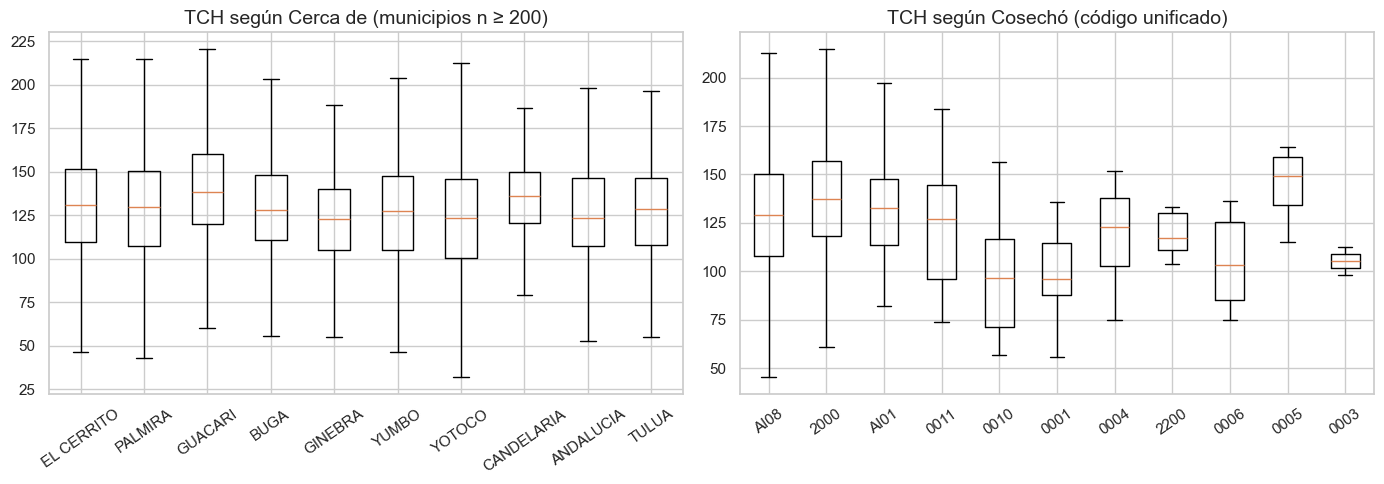

In [32]:
# Trazabilidad de extras sin ficha en el diccionario (no son fuga del paso 10).
# Flujo: 1 perfil → 2 consistencia DDUlt vs fechas → 3 anidamiento Cerca de–Zona → 4 boxplots TCH.
cols_sin_ficha = ["D.S.", "Cerca de", "Cosechó", "DDUlt.Riego", "Codigo Estacion"]


def ficha_sin_pdf(col):
    """Resumen de forma, nulos y asociación cruda con los dos targets (Pearson si numérica; medias si categórica)."""
    s = df_suertes[col]
    print(f"\n=== {col}  |  dtype={s.dtype}  |  nulos={s.isna().sum():,} ({100 * s.isna().mean():.1f}%)  |  niveles={s.nunique(dropna=True)} ===")
    if pd.api.types.is_numeric_dtype(s):
        print(s.describe().round(2).to_string())
        for y in ["TCH", "%Sac.Caña"]:
            pair = df_suertes[[col, y]].dropna()
            print(
                f"  vs {y}: n={len(pair):,}  "
                f"Pearson={pair[col].corr(pair[y]):.3f}  "
                f"Spearman={pair[col].corr(pair[y], method='spearman'):.3f}"
            )
        return
    vc = s.astype("string").str.strip().value_counts(dropna=False)
    print("Frecuencias (top 12):\n", vc.head(12).to_string())
    tmp = df_suertes[[col, "TCH", "%Sac.Caña"]].copy()
    tmp[col] = tmp[col].astype("string").str.strip().str.upper()
    g = (
        tmp.groupby(col, dropna=False)[["TCH", "%Sac.Caña"]]
        .agg(["mean", "count"])
        .sort_values(("TCH", "count"), ascending=False)
    )
    print("Medias por nivel (top 12 por n):\n", g.head(12).round(2).to_string())
    g30 = g[g[("TCH", "count")] >= 30]
    if len(g30):
        print(
            f"  TCH (n≥30): {g30[('TCH','mean')].min():.1f} … {g30[('TCH','mean')].max():.1f}  "
            f"(rango {g30[('TCH','mean')].max() - g30[('TCH','mean')].min():.1f} t/ha)"
        )


print("\n--- 1. Perfil: forma, nulos y asociación con TCH / %Sac.Caña ---")
for c in cols_sin_ficha:
    ficha_sin_pdf(c)

# 2. Consistencia: DDUlt.Riego = (F.Ult.Corte − Ult.Riego).days cuando hay fecha de riego
print("\n--- 2. Consistencia interna: DDUlt.Riego vs fechas de riego y corte ---")
ambas = df_suertes[["DDUlt.Riego", "Ult.Riego", "F.Ult.Corte"]].dropna()
delta = (ambas["F.Ult.Corte"] - ambas["Ult.Riego"]).dt.days
print(
    "\nDDUlt.Riego vs (F.Ult.Corte − Ult.Riego).days: "
    f"n={len(ambas):,}  Pearson={delta.corr(ambas['DDUlt.Riego']):.4f}  "
    f"|diff| medio={(delta - ambas['DDUlt.Riego']).abs().mean():.4f}"
)
print(
    "DDUlt.Riego = 0 cuando Ult.Riego es NA:",
    int((df_suertes.loc[df_suertes["Ult.Riego"].isna(), "DDUlt.Riego"] == 0).all()),
    f"(n NA riego = {df_suertes['Ult.Riego'].isna().sum():,})",
)

# 3. Anidamiento: el municipio (Cerca de) respecto a la zona del ingenio
print("\n--- 3. Anidamiento geográfico: Cerca de vs Zona ---")
print("\nCramér V Cerca de vs Zona:", round(cramers_v(df_suertes["Cerca de"].astype(str), df_suertes["Zona"].astype(str)), 3))
ct = pd.crosstab(df_suertes["Cerca de"].astype("string").str.strip(), df_suertes["Zona"].astype(str).str.upper())
modal = ct.max(axis=1) / ct.sum(axis=1)
print("Fracción del municipio en su zona modal: mediana", round(float(modal.median()), 3), "| media", round(float(modal.mean()), 3))
print("Excepción (menor anidamiento):", modal.idxmin(), f"{100 * modal.min():.1f}%")

# 4. Distribución de TCH: municipios frecuentes y frente de cosecha
print("\n--- 4. TCH por municipio (n ≥ 200) y por frente de cosecha ---")
cerca_n = df_suertes["Cerca de"].astype("string").str.strip().str.upper().value_counts()
muni_ok = cerca_n[cerca_n >= 200].index
df_muni = df_suertes.assign(_muni=df_suertes["Cerca de"].astype("string").str.strip().str.upper())
df_muni = df_muni[df_muni["_muni"].isin(muni_ok)]
df_frente = df_suertes.assign(_frente=df_suertes["Cosechó"].astype("string").str.upper())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
box_por(df_muni, "_muni", "TCH", axes[0], orden=list(cerca_n.loc[muni_ok].index))
axes[0].set_title("TCH según Cerca de (municipios n ≥ 200)")
box_por(df_frente, "_frente", "TCH", axes[1])
axes[1].set_title("TCH según Cosechó (código unificado)")
plt.tight_layout()
plt.show()


**Qué muestra este diagnóstico**

`D.S.` tiene un 65.9% de nulos, y entre los valores que sí aparecen domina claramente el 1.65 (7.148 filas), frente a apenas 19 filas marcadas literalmente como "DS" y 1 fila con 1.5. Comparando el TCH entre lotes con dato (128.4) y sin dato (130.2), la diferencia es mínima, así que no separa bien el rendimiento. Lo interesante es que 1.65 coincide con el distanciamiento entre surcos típico de la cosecha mecánica en el Valle (1.50-1.75 metros, según Cenicaña) — así que se infiere con confianza razonable que esta columna mide eso. Las 19 filas marcadas "DS" no encajan con esa interpretación y quedan sin explicación. De todas formas, sale del modelo: tiene demasiados nulos y no aporta una señal clara sobre el rendimiento.

`Cerca de` resultó ser el municipio o vereda más cercana al lote — 31 valores distintos, todos nombres reales del Valle y el norte del Cauca (El Cerrito, Palmira, Guacarí, Corinto, Caloto, entre otros), con apenas 0.6% de nulos. Aquí sí apareció una señal fuerte: el TCH varía casi 48 toneladas por hectárea entre municipios, de 92.0 en Caloto a 139.7 en Guacarí. El problema es que esta información ya está en gran parte contenida en la `Zona` — se midió con Cramér's V y salió 0.585, una asociación bastante alta, coherente con que casi todos los municipios caen siempre dentro de una sola zona (la única excepción parcial es El Cerrito, repartido entre dos). El TCH bajo, además, se concentra sobre todo en los municipios del norte del Cauca, que ya corresponden a la zona IP05. Por eso no entra al modelo: agregar 31 columnas dummy para capturar algo que la zona ya explica en buena parte no vale la pena, y rompería la interpretabilidad de la regresión. Queda anotada como el mejor candidato si en el futuro se quisiera afinar la geografía del modelo.

`Cosechó` se confirma como el código de la cuadrilla o contratista que hizo la cosecha (después de unificar mayúsculas en el paso 5). Un solo código domina casi todo: AI08 representa el 92.4% de las filas, y el resto se reparte en otros 10 códigos con muy pocas filas cada uno. Sí hay una diferencia real de rendimiento (AI08 promedia 129.0 t/ha, el código "2000" promedia 138.2), pero esa diferencia de 9 toneladas no justifica agregar 11 columnas dummy al modelo por una variable que en la práctica es casi constante.

`DDUlt.Riego` se confirma con una prueba exacta: sus ceros coinciden perfectamente con las 12.557 filas donde no hay fecha de último riego registrada, y donde sí hay fecha, el valor coincide con la resta directa entre la fecha de corte y la de riego (correlación de 1.000, sin margen de duda) — es literalmente los días transcurridos desde el último riego. Sale del modelo porque su relación con TCH y sacarosa es muy débil, y porque esa información ya está representada, de otra forma, por `Num.Riegos` y `M3 Riego`.

`Codigo Estacion` es la única que queda genuinamente sin resolver del todo. Tiene 70.1% de nulos, y de los 20 códigos que aparecen, varios sí coinciden con nombres de municipio (BUG con Buga, PRA con Pradera), lo que sugiere que identifica la estación meteorológica del Ingenio. Pero el código "999" funciona como un cajón de sastre sin significado claro, y con tantos nulos de por sí, no se pudo confirmar con certeza qué representa cuando falta el dato o cuando aparece ese "999". Sale del modelo simplemente por superar el umbral de nulos que ya se había fijado desde el principio — y de todas formas, las variables de lluvia del propio lote (`Lluvias Ciclo` y la de los 2 meses antes) ya cubren la parte climática que esta columna intentaría aportar.

**El hallazgo que vale la pena resaltar:** de las cinco, `Cerca de` es la única con una señal de negocio real y fuerte (esos 48 t/ha de diferencia entre municipios no son ruido). No entra al modelo únicamente porque compite demasiado con `Zona`, no porque no importe — así que si en algún momento se quisiera hacer un modelo geográficamente más fino, esta es la variable a explorar primero, no `Codigo Estacion`.

**Y la honestidad final:** de las cinco, tres sí se lograron interpretar con confianza (`Cerca de`, `Cosechó`, `DDUlt.Riego`) y salen del modelo por redundancia o por aportar poca señal, no por no entenderlas. Solo dos quedan con ambigüedad genuina: no se pudo determinar con certeza qué significa `D.S.` en las filas marcadas "DS", ni qué representa `Codigo Estacion` cuando falta el dato o vale "999" — ambas se excluyen por precaución, dejando esa incertidumbre declarada en vez de inventar una explicación que suene razonable.

**Traspaso al notebook de modelos**

`df_suertes` se guarda en `datos/suertes_limpio.parquet` para `02_modelos_regresion.ipynb`.

- **Lleva** solo transformaciones **sin estado**, que dan el mismo resultado por fila con o sin el resto del histórico: tipado (`Suerte` como texto), placeholders → NaN (paso 3), mayúsculas y espacios en `Zona`, `Cosechó`, `Suelo` y `Producto` (paso 5) y `edad_desde_siembra` (paso 8), y las marcas de fila `excluir_tch` y `lluvia_sin_dato` (reglas sin estadísticos, paso 9).
- **No lleva** imputaciones, agrupación de colas por frecuencia ni dummies. `df_vif` y `df_diagn` (pasos 12–13) usan medianas de todas las filas y solo sirven de diagnóstico; los estadísticos del lineal se estiman en train (paso 16).
- Los datos no se suben al repositorio: `datos/` está en `.gitignore`.


In [33]:
# Marcas de fila para el modelo (reglas sin estadísticos): se aplican en el notebook 02.
df_suertes["excluir_tch"] = (df_suertes["TCH"] < 60) & (df_suertes["Destino 1=Semilla"] == 0)
df_suertes["lluvia_sin_dato"] = df_suertes["Lluvias Ciclo"] == 0
print("excluir_tch:", int(df_suertes["excluir_tch"].sum()), "| lluvia_sin_dato:", int(df_suertes["lluvia_sin_dato"].sum()),
      "de", len(df_suertes), "filas")


excluir_tch: 355 | lluvia_sin_dato: 7739 de 21027 filas


In [34]:
# Traspaso al notebook 02: histórico con transformaciones sin estado y nulos originales.
# Orden: 1 guardar → 2 releer → 3 comprobar igualdad.
from pathlib import Path

RUTA_SUERTES = Path("datos/suertes_limpio.parquet")
RUTA_SUERTES.parent.mkdir(exist_ok=True)
df_suertes.to_parquet(RUTA_SUERTES)

df_chk = pd.read_parquet(RUTA_SUERTES)
pd.testing.assert_frame_equal(df_suertes, df_chk)   # ida y vuelta sin cambios de valor, tipo ni índice

print("Guardado:", RUTA_SUERTES, "| filas × columnas =", df_suertes.shape)
print("Nulos originales (sin imputar): Semanas mad. =", int(df_suertes["Semanas mad."].isna().sum()),
      "| Num.Riegos =", int(df_suertes["Num.Riegos"].isna().sum()),
      "| Dosis Madurante =", int(df_suertes["Dosis Madurante"].isna().sum()),
      "| Suelo =", int(df_suertes["Suelo"].isna().sum()))


/var/folders/z6/0z0kxtw92rz08l460k_lspww0000gn/T/ipykernel_20773/3938400320.py:10: FutureWarning: Mismatched null-like values nan and None found. In a future version, pandas equality-testing functions (e.g. assert_frame_equal) will consider these not-matching and raise.
  pd.testing.assert_frame_equal(df_suertes, df_chk)   # ida y vuelta sin cambios de valor, tipo ni índice


Guardado: datos/suertes_limpio.parquet | filas × columnas = (21027, 88)
Nulos originales (sin imputar): Semanas mad. = 9775 | Num.Riegos = 12589 | Dosis Madurante = 104 | Suelo = 3758
